# Sentence Memorability Experiment — Analysis Notebook

---

## Experimental Background

This experiment investigates how the **memorability of Subject–Verb–Object (S–V–O) sentences** is
shaped by the **memorability of their constituent nouns** and **sentence voice** (active vs. passive).

### Stimulus Design

Sentences were constructed by systematically varying the memorability of the **subject** and
**object** nouns using established word-memorability norms. Verbs were drawn from a fixed pool of
medium-concreteness action verbs to minimise confounding variability. This yielded **four
word-memorability conditions**:

| Code | Subject Noun | Object Noun | Example |
|------|-------------|-------------|---------|
| **HH** | High memorability | High memorability | *The eagle carries the lantern* |
| **HL** | High memorability | Low memorability  | *The eagle carries the notion*  |
| **LH** | Low memorability  | High memorability | *The factor carries the lantern* |
| **LL** | Low memorability  | Low memorability  | *The factor carries the notion*  |

Each sentence was also produced in **active** and **passive** voice, yielding **8 experimental
conditions** (HH, HL, LH, LL × Active, Passive) — 50 sentences per condition, **400 sentences
in total**.

### Procedure

Participants completed a **continuous recognition task**. Each participant encountered **48 target
sentences** across **3 blocks** (~16 targets per block). Each target appeared twice — once as a
first presentation and once as a repeat, either in the **same voice (exact repetition)** or a
**voice-transformed** form (active ↔ passive). Two responses were collected:

- **Information Recognition (IR):** Press spacebar when the sentence conveys the *same meaning* as
  a previously seen sentence (regardless of exact wording). Captures **gist-level memory**.
- **Word Recognition (WR):** After pressing spacebar, indicate *A (Yes)* if the sentence was
  word-for-word identical, or *D (No)* if it was a voice-transformed paraphrase. Captures
  **verbatim surface-form memory**.

### Target Sample Size

A total of **114 successfully completing participants** are required based on a power analysis
for the primary hypotheses.

---

## Research Question

> **How is the memorability of sentences affected by their syntactic structure (active vs. passive
voice) and the memorability of their constituent nouns (High / Low)?**

### Hypotheses

**H1 — Word Memorability Effect**
Sentences composed of higher-memorability nouns (**HH > HL, LH > LL**) will produce higher
corrected memorability scores (Pr = Hit Rate − False Alarm Rate), reflecting more robust
encoding when constituent nouns are independently more memorable.

**H2 — Voice Effect**
Active sentences will show higher memorability than their passive counterparts. Active voice is
the canonical English sentence form and places the agent — typically the higher-memorability
entity — in the structurally and perceptually salient subject position.

**H3 — Word Memorability × Voice Interaction**
The memorability advantage of high-memorability nouns may be modulated by voice. The subject-
position advantage should be more pronounced in active sentences, where the subject role is
thematically and structurally prominent.


In [2]:

import pandas as pd
import numpy as np
import os
import itertools
import warnings
from scipy import stats
from scipy.stats import (kruskal, wilcoxon, mannwhitneyu,
                          shapiro, kstest, levene,
                          norm as _norm, pearsonr, spearmanr,
                          chi2_contingency, friedmanchisquare)
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scikit_posthocs as sp
import pingouin as pg
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
 
warnings.filterwarnings("ignore")

In [3]:

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa", "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.color": "white", "grid.linewidth": 1.0,
    "font.family": "DejaVu Sans",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
})
FONT_TITLE = {"fontsize": 14, "fontweight": "bold", "pad": 12}
FONT_LABEL = {"fontsize": 11}
 
COND_PALETTE = {
    # "HF":  "#4C72B0", 
    "HH":  "#DD8452", "HVL": "#55A868",
    "LVH": "#C44E52", "LVL": "#8172B2",
    "HL":  "#E377C2", "LH":  "#7F7F7F", "LL":  "#BCBD22",
}
VOICE_PALETTE  = {"active": "#2C7BB6", "passive": "#D7191C"}
VOICE_HATCH    = {"active": "",        "passive": "///"}
OUT_PALETTE    = {"Hit": "#2ecc71", "Miss": "#e74c3c",
                  "False Alarm": "#f39c12", "Correct Reject": "#3498db"}
BLUE, GREY     = "#4C72B0", "#7f8c8d"
 
SPEC_CONDITIONS  = ["HH", "HL", "LH", "LL"]   # from txt spec
RT_LOW, RT_HIGH  = 100, 5000                   # ms hard cutoff
RT_SD_THRESHOLD  = 3                           # soft ± SD cutoff
REQUIRED_N       = 334                         # from power analysis
 
VOICE_MAP = {"a": "active", "p": "passive", "1": "active", "2": "passive",
             "active": "active", "passive": "passive",
             "A": "active", "P": "passive"}
 
DATA_FOLDER = "data"

In [4]:

def sig_stars(p):
    if pd.isna(p): return "—"
    return "***" if p < .001 else ("**" if p < .01 else ("*" if p < .05 else "n.s."))
 
def eps_squared(H, k, N):
    """Epsilon-squared effect size for Kruskal-Wallis."""
    return max((H - k + 1) / (N - k), 0) if N > k else 0.0
 
def rank_biserial_r(g1, g2):
    """Rank-biserial correlation from Mann-Whitney U."""
    n1, n2 = len(g1), len(g2)
    if n1 == 0 or n2 == 0: return np.nan
    U, _ = mannwhitneyu(g1, g2, alternative="two-sided")
    return 1 - (2 * U) / (n1 * n2)
 
def wilcoxon_r(stat, n):
    """Effect size r for Wilcoxon signed-rank."""
    # return stat / np.sqrt(n * (n + 1) * (2 * n + 1) / 6) if n > 0 else np.nan
    return 1 - (4 * stat) / (n * (n + 1)) if n > 0 else np.nan

def compute_pr(sub):
    """Compute corrected memorability Pr = Hit Rate - FA Rate"""
    n_sig = sub["semantic_repeat"].sum()
    n_nos = (~sub["semantic_repeat"]).sum()
    hits  = ((sub["semantic_repeat"]) & (sub["ir_pressed"])).sum()
    fas   = ((~sub["semantic_repeat"]) & (sub["ir_pressed"])).sum()
    hr    = hits / max(n_sig, 1)
    far   = fas  / max(n_nos, 1)
    return pd.Series({"hit_rate": hr, "fa_rate": far, "Pr": hr - far})


def log_linear_correction(hits, n_signal, fas, n_noise):
    """Apply log-linear correction to avoid 0 or 1 rates for d'."""
    hr  = (hits + 0.5)  / (n_signal + 1)
    far = (fas  + 0.5)  / (n_noise  + 1)
    return hr, far
 
def compute_dprime(hr, far):
    """d' = z(HR) - z(FAR). Clamps to avoid ±inf."""
    hr  = np.clip(hr,  0.001, 0.999)
    far = np.clip(far, 0.001, 0.999)
    return float(_norm.ppf(hr) - _norm.ppf(far))
 
def dunn_both_corrections(pr_by_wc, word_conds):
    """
    Dunn's test post-hoc with BOTH Bonferroni and BH corrections.
    Returns a DataFrame with columns:
        A, B, U, p_raw, p_bonf, sig_bonf, p_bh, sig_bh, effect_r
    """
    pairs = list(itertools.combinations(word_conds, 2))
    rows  = []
    raw_ps, Us, rs = [], [], []
    for wc1, wc2 in pairs:
        g1 = pr_by_wc[pr_by_wc.word_condition == wc1]["Pr"].dropna().values
        g2 = pr_by_wc[pr_by_wc.word_condition == wc2]["Pr"].dropna().values
        if len(g1) >= 2 and len(g2) >= 2:
            U, p = mannwhitneyu(g1, g2, alternative="two-sided")
            r    = rank_biserial_r(g1, g2)
        else:
            U, p, r = np.nan, np.nan, np.nan
        raw_ps.append(p); Us.append(U); rs.append(r)
 
    valid   = [not np.isnan(p) for p in raw_ps]
    p_valid = [p for p, v in zip(raw_ps, valid) if v]
 
    bonf = np.full(len(raw_ps), np.nan)
    bh   = np.full(len(raw_ps), np.nan)
    if p_valid:
        _, pb, _, _ = multipletests(p_valid, method="bonferroni")
        _, ph, _, _ = multipletests(p_valid, method="fdr_bh")
        vi = 0
        for i, v in enumerate(valid):
            if v:
                bonf[i] = pb[vi]; bh[i] = ph[vi]; vi += 1
 
    for i, (wc1, wc2) in enumerate(pairs):
        rows.append({
            "A": wc1, "B": wc2,
            "U":         round(Us[i], 1) if not np.isnan(Us[i]) else np.nan,
            "p_raw":     round(raw_ps[i], 4) if not np.isnan(raw_ps[i]) else np.nan,
            "p_bonf":    round(bonf[i], 4)   if not np.isnan(bonf[i])  else np.nan,
            "sig_bonf":  sig_stars(bonf[i]),
            "p_bh":      round(bh[i], 4)     if not np.isnan(bh[i])   else np.nan,
            "sig_bh":    sig_stars(bh[i]),
            "effect_r":  round(rs[i], 3)     if not np.isnan(rs[i])   else np.nan,
        })
    return pd.DataFrame(rows)
 
 

In [5]:

def art_anova_2way(df, y_col, factor_a, factor_b):
    """
    Aligned Ranks Transformation ANOVA for a 2-factor design.
    Tests main effect A, main effect B, and A×B interaction.
 
    Procedure (Wobbrock et al., 2011 CHI):
      For each effect E:
        1. Align Y by stripping all effects EXCEPT E.
        2. Rank the aligned values across all observations.
        3. Run standard OLS ANOVA on the ranks.
      Validity check: aligned cell means must be monotone with
      original cell means (checked and reported).
 
    Returns dict keyed by effect name with F, df, p, interpretation.
    """
    d = df[[y_col, factor_a, factor_b]].dropna().copy()
    d[factor_a] = d[factor_a].astype(str)
    d[factor_b] = d[factor_b].astype(str)
 
    grand = d[y_col].mean()
    rmean = d.groupby(factor_a)[y_col].mean().to_dict()   # μ_i.
    cmean = d.groupby(factor_b)[y_col].mean().to_dict()   # μ_.j
    cmean_dict = d.groupby([factor_a, factor_b])[y_col].mean().to_dict()  # μ_ij
 
    d["_rm"]   = d[factor_a].map(rmean)
    d["_cm"]   = d[factor_b].map(cmean)
    d["_cell"] = d.apply(lambda r: cmean_dict.get((r[factor_a], r[factor_b]), np.nan), axis=1)
 
    # Alignment equations:
    # align_A  = Y − (cell − row_mean)       → keeps only A signal
    # align_B  = Y − (cell − col_mean)       → keeps only B signal
    # align_AB = Y − (row_mean + col_mean − grand)  → keeps only A×B signal
    d["_aln_A"]  = d[y_col] - (d["_cell"] - d["_rm"])
    d["_aln_B"]  = d[y_col] - (d["_cell"] - d["_cm"])
    d["_aln_AB"] = d[y_col] - (d["_rm"] + d["_cm"] - grand)
 
    results = {}
    labels  = {
        f"Main Effect: {factor_a}":           ("_aln_A",  f"C({factor_a})"),
        f"Main Effect: {factor_b}":           ("_aln_B",  f"C({factor_b})"),
        f"Interaction: {factor_a} × {factor_b}": ("_aln_AB", f"C({factor_a}):C({factor_b})"),
    }
 
    for name, (aln_col, term) in labels.items():
        d["_rnk"] = stats.rankdata(d[aln_col].fillna(0).values).astype(float)
        try:
            formula = f"_rnk ~ C({factor_a}) * C({factor_b})"
            model   = smf.ols(formula, data=d).fit()
            tbl     = anova_lm(model, typ=2)
            row_key = [k for k in tbl.index if term in k and k != "Residual"]
            if row_key:
                row = tbl.loc[row_key[-1]]
                F   = float(row.get("F", np.nan))
                p   = float(row.get("PR(>F)", np.nan))
                df1 = int(row.get("df", 1))
            else:
                F, p, df1 = np.nan, np.nan, np.nan
        except Exception as e:
            F, p, df1 = np.nan, np.nan, np.nan
 
        # Validity check: cell means of aligned ranks ~ original cell means
        ranked_cell_means = d.groupby([factor_a, factor_b])["_rnk"].mean()
        orig_cell_means   = d.groupby([factor_a, factor_b])[y_col].mean()
        rho, _ = spearmanr(ranked_cell_means.values, orig_cell_means.values)
 
        results[name] = {
            "F": round(F, 3) if not np.isnan(F) else np.nan,
            "df": df1,
            "p": round(p, 4) if not np.isnan(p) else np.nan,
            "sig": sig_stars(p),
            "validity_rho": round(rho, 3),
            "valid": rho > 0,
        }
 
    return results
 

---
## Section 0 · Data Loading & Preprocessing
---

In [6]:
print("=" * 65)
print("  PHASE 0 · DATA LOADING & PARSING")
print("=" * 65)
 
def parse_stimulus(stim):
    parts = str(stim).strip().split("_")
    if len(parts) < 3:
        return None, None, None
    return parts[0].upper(), parts[1], parts[2].lower()
 
def process_log(file_path):
    df = pd.read_csv(file_path)
    participant_id = df["participant_ID"].iloc[0]
    seen_meaning, seen_exact = set(), set()
    trials, current_trial = [], None
 
    for _, row in df.iterrows():
        event = row["Event"]
        stim  = row["Stimulus"]
        if pd.isna(stim) and event != "gap_time":
            continue
 
        if event == "Sentence shown":
            word_cond, sid, voice_raw = parse_stimulus(stim)
            if word_cond is None:
                continue
            voice = VOICE_MAP.get(voice_raw, voice_raw)
            semantic_repeat = (word_cond, sid) in seen_meaning
            exact_repeat    = stim in seen_exact
            current_trial = {
                "participant":    participant_id,
                "stimulus":       stim,
                "word_condition": word_cond,
                "sentence_id":    sid,
                "voice":          voice,
                "condition_full": f"{word_cond}_{voice}",
                "semantic_repeat": semantic_repeat,
                "exact_repeat":    exact_repeat,
                "ir_pressed": False,
                "wr_response": None,
                "rt_ir": None, "rt_wr": None,
            }
            seen_meaning.add((word_cond, sid))
            seen_exact.add(stim)
 
        elif event == "IR pressed" and current_trial is not None:
            current_trial["ir_pressed"] = True
            current_trial["rt_ir"]      = row.get("Reaction_time_IR", None)
 
        elif event == "WR pressed" and current_trial is not None:
            current_trial["wr_response"] = row.get("Button", None)
            current_trial["rt_wr"]       = row.get("Reaction_time_WR", None)
 
        elif event == "gap_time" and current_trial is not None:
            trials.append(current_trial)
            current_trial = None
 
    return pd.DataFrame(trials)
 
all_trials = []
for fn in sorted(os.listdir(DATA_FOLDER)):
    if fn.endswith(".log"):
        all_trials.append(process_log(os.path.join(DATA_FOLDER, fn)))
 
trial_df = pd.concat(all_trials, ignore_index=True)
 
# Block assignment
trial_df["trial_index"] = trial_df.groupby("participant").cumcount()
def assign_block(grp):
    n = len(grp)
    return ((grp["trial_index"] / (n / 3)).clip(upper=2.999).astype(int) + 1)
trial_df["block"] = trial_df.groupby("participant", group_keys=False).apply(assign_block)
 
# Outcome labels
def classify_outcome(row):
    if row.semantic_repeat and row.ir_pressed:      return "Hit"
    if row.semantic_repeat and not row.ir_pressed:  return "Miss"
    if not row.semantic_repeat and row.ir_pressed:  return "False Alarm"
    return "Correct Reject"
trial_df["outcome"] = trial_df.apply(classify_outcome, axis=1)
 
# WR sub-dataset (before exclusions — exclusions applied later)
wr_df = trial_df[trial_df["wr_response"].notna()].copy()
def wr_is_correct(row):
    if row["exact_repeat"]     and row["wr_response"] == "Yes": return 1
    if not row["exact_repeat"] and row["wr_response"] == "No":  return 1
    return 0
wr_df["wr_correct"] = wr_df.apply(wr_is_correct, axis=1)
 
WORD_CONDS_DATA = sorted(trial_df["word_condition"].dropna().unique())
VOICES_DATA     = sorted(trial_df["voice"].dropna().unique())
FULL_CONDS_DATA = [f"{wc}_{v}" for wc in WORD_CONDS_DATA for v in VOICES_DATA]
 
print(f"\nLoaded       : {len(trial_df):,} trials from "
      f"{trial_df['participant'].nunique()} participants")
print(f"Word conds   : {WORD_CONDS_DATA}")
print(f"Voice types  : {VOICES_DATA}")
print(f"Full conds   : {FULL_CONDS_DATA}")

  PHASE 0 · DATA LOADING & PARSING

Loaded       : 25,308 trials from 114 participants
Word conds   : ['HF', 'HH', 'HVL', 'LVH', 'LVL']
Voice types  : ['active', 'passive']
Full conds   : ['HF_active', 'HF_passive', 'HH_active', 'HH_passive', 'HVL_active', 'HVL_passive', 'LVH_active', 'LVH_passive', 'LVL_active', 'LVL_passive']


In [7]:

print(f"  Spec (txt) expects : {SPEC_CONDITIONS}  × [active, passive]")
print(f"  Data contains      : {WORD_CONDS_DATA} × {VOICES_DATA}") 

  Spec (txt) expects : ['HH', 'HL', 'LH', 'LL']  × [active, passive]
  Data contains      : ['HF', 'HH', 'HVL', 'LVH', 'LVL'] × ['active', 'passive']


---
## Section 1 · Block Validation & Exclusion

### Validation Criterion

Attention was verified on a **block-by-block** basis. A block is **retained** only when the
participant's performance on repeat sentences satisfies:

> **Hits > (False Alarms ÷ 2) + Misses**

In signal-detection terms this penalises both liberal responding (high FAs) and inattentive
responding (high Misses), retaining only blocks where the participant demonstrated genuine
recognition above a mixed-criterion threshold.

Participants for whom **fewer than 2 of 3 blocks pass** are excluded from the study entirely.

> All downstream analyses — memorability scores, statistical tests, and visualisations — use
only data from **validated blocks of retained participants**.

---


In [8]:
print("\n" + "=" * 65)
print("  PHASE 1 · BLOCK VALIDATION & EXCLUSION")
print("=" * 65)
 
def validate_block(sub):
    hits   = (sub["outcome"] == "Hit").sum()
    misses = (sub["outcome"] == "Miss").sum()
    fas    = (sub["outcome"] == "False Alarm").sum()
    return int(hits > (fas / 2) + misses)
 
try:
    block_valid = (trial_df.groupby(["participant", "block"])
                   .apply(validate_block, include_groups=False)
                   .reset_index(name="valid_block"))
except TypeError:
    block_valid = (trial_df.groupby(["participant", "block"])
                   .apply(validate_block)
                   .reset_index(name="valid_block"))
 
trial_df = trial_df.merge(block_valid, on=["participant", "block"], how="left")
wr_df    = wr_df.merge(block_valid, on=["participant", "block"], how="left",
                       suffixes=("", "_wr"))
 
blocks_per_ppt = block_valid.groupby("participant")["valid_block"].sum()
valid_ppts     = blocks_per_ppt[blocks_per_ppt >= 3].index
 
trial_df_valid = trial_df[(trial_df["valid_block"] == 1) &
                           trial_df["participant"].isin(valid_ppts)].copy()
wr_df_valid    = wr_df[(wr_df["valid_block"] == 1) &
                        wr_df["participant"].isin(valid_ppts)].copy()
 
n_total  = trial_df["participant"].nunique()
n_valid  = len(valid_ppts)
print(f"  Enrolled   : {n_total}")
print(f"  Retained   : {n_valid}  ({n_valid/n_total:.1%})")
print(f"  Excluded   : {n_total - n_valid}")
print(f"  Blocks retained: {int(block_valid['valid_block'].sum())} / {len(block_valid)}")
print(f"  Trials retained: {len(trial_df_valid):,} / {len(trial_df):,}")
 
WORD_CONDS = sorted(trial_df_valid["word_condition"].dropna().unique())
VOICES     = sorted(trial_df_valid["voice"].dropna().unique())
FULL_CONDS = [f"{wc}_{v}" for wc in WORD_CONDS for v in VOICES]
 


  PHASE 1 · BLOCK VALIDATION & EXCLUSION
  Enrolled   : 114
  Retained   : 106  (93.0%)
  Excluded   : 8
  Blocks retained: 329 / 342
  Trials retained: 23,532 / 25,308


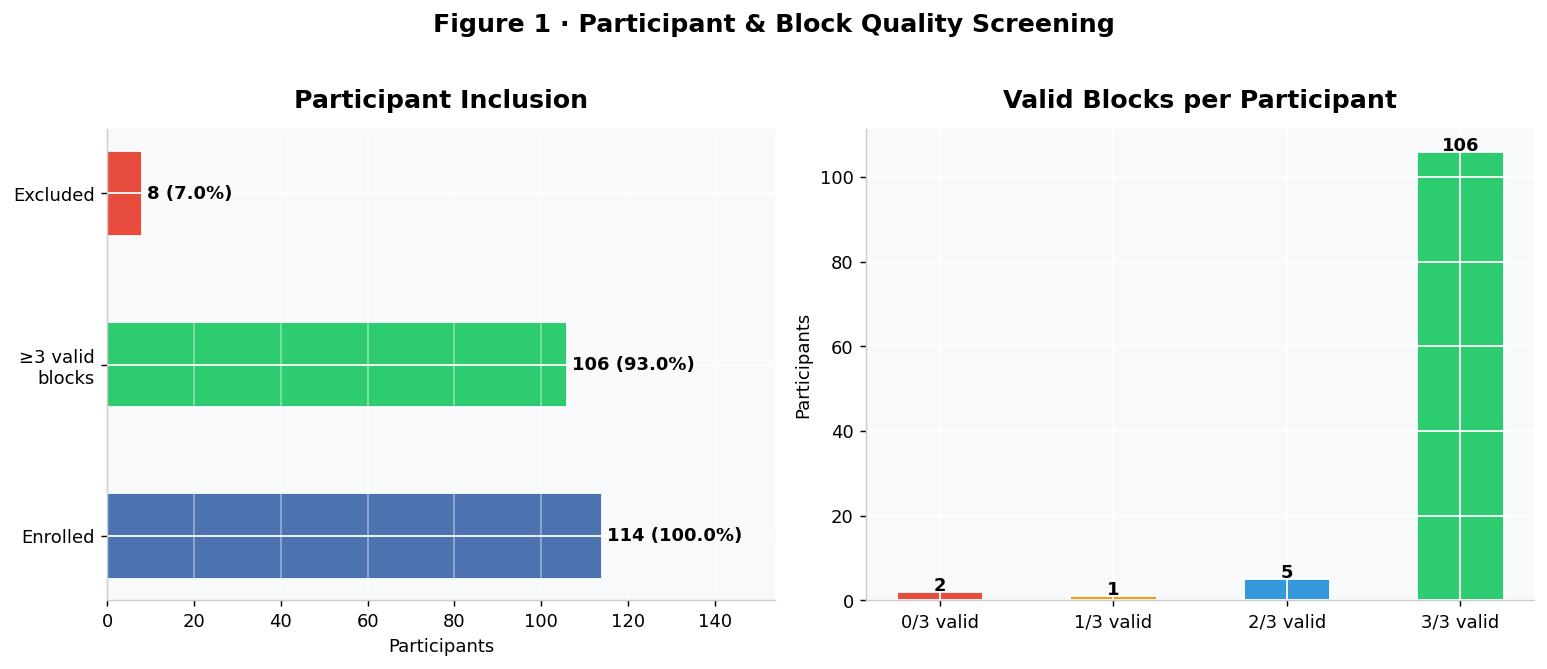

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
labels_ = ["Enrolled", "≥3 valid\nblocks", "Excluded"]
vals_   = [n_total, n_valid, n_total - n_valid]
colors_ = ["#4C72B0", "#2ecc71", "#e74c3c"]
ax.barh(range(3), vals_, color=colors_, edgecolor="white", height=0.5)
for i, v in enumerate(vals_):
    ax.text(v + n_total * 0.01, i, f"{v} ({v/n_total:.1%})",
            va="center", fontsize=10, fontweight="bold")
ax.set_yticks(range(3)); ax.set_yticklabels(labels_)
ax.set_xlabel("Participants"); ax.set_title("Participant Inclusion", **FONT_TITLE)
ax.set_xlim(0, n_total * 1.35); ax.grid(axis="x", alpha=0.4)
 
ax = axes[1]
cnts = block_valid.groupby("participant")["valid_block"].sum().value_counts().sort_index()
bc   = {0: "#e74c3c", 1: "#f39c12", 2: "#3498db", 3: "#2ecc71"}
ax.bar(range(len(cnts)), cnts.values,
       color=[bc.get(k, "grey") for k in cnts.index],
       edgecolor="white", width=0.5)
for i, v in enumerate(cnts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(range(len(cnts)))
ax.set_xticklabels([f"{k}/3 valid" for k in cnts.index])
ax.set_ylabel("Participants"); ax.set_title("Valid Blocks per Participant", **FONT_TITLE)
fig.suptitle("Figure 1 · Participant & Block Quality Screening",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig01_inclusion.png", bbox_inches="tight")
plt.show()

### Inference — Block Validation

The bar chart above shows the proportion of participants and blocks that met the attention
criterion. Blocks are excluded when a participant shows either excessively liberal responding
(inflated false alarms) or systematic inattention (high miss rate), both of which would inflate
or deflate memorability scores artifactually. Retaining only participants with ≥ 2/3 valid blocks
ensures that the corrected memorability scores reflect genuine recognition performance rather than
strategy or fatigue effects.


Data Health


── 2a · Empty / Sparse Condition Check ──
  ✓ OK      : HF_active — 13356 trials
  ⚠ EMPTY   : HF_passive — 0 trials (excluded from all tests)
  ✓ OK      : HH_active — 1272 trials
  ✓ OK      : HH_passive — 1272 trials
  ✓ OK      : HVL_active — 1272 trials
  ✓ OK      : HVL_passive — 1272 trials
  ✓ OK      : LVH_active — 1272 trials
  ✓ OK      : LVH_passive — 1272 trials
  ✓ OK      : LVL_active — 1272 trials
  ✓ OK      : LVL_passive — 1272 trials

── 2b · RT Outlier Removal (hard: <100 or >5000 ms) ──
  Hard cutoff trimmed : 5 RT values
  Soft ±3SD trimmed : 97 additional RT values
  RT values remaining  : 9,294 / 9,396

── 2c · Raw Rate Distributions ──


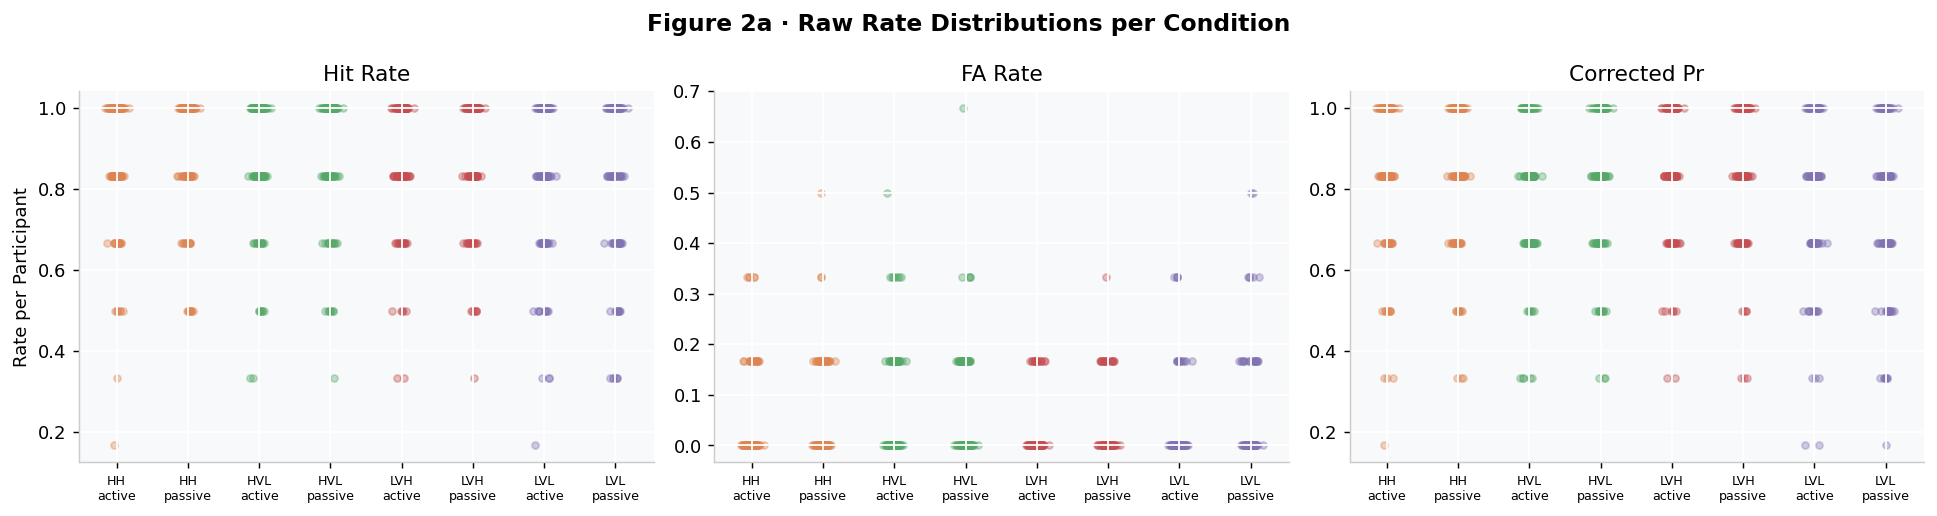


── 2d · Ceiling / Floor Detection ──
  ✓ OK      : HH_active  Pr = 0.821
  ✓ OK      : HH_passive  Pr = 0.830
  ✓ OK      : HVL_active  Pr = 0.799
  ✓ OK      : HVL_passive  Pr = 0.816
  ✓ OK      : LVH_active  Pr = 0.829
  ✓ OK      : LVH_passive  Pr = 0.843
  ✓ OK      : LVL_active  Pr = 0.781
  ✓ OK      : LVL_passive  Pr = 0.769

── 2e · Participant-Level Pr Outlier Detection (IQR 1.5×) ──
  ⚠ 1 participant(s) are Pr outliers:
    Participant 246: mean Pr = 0.458


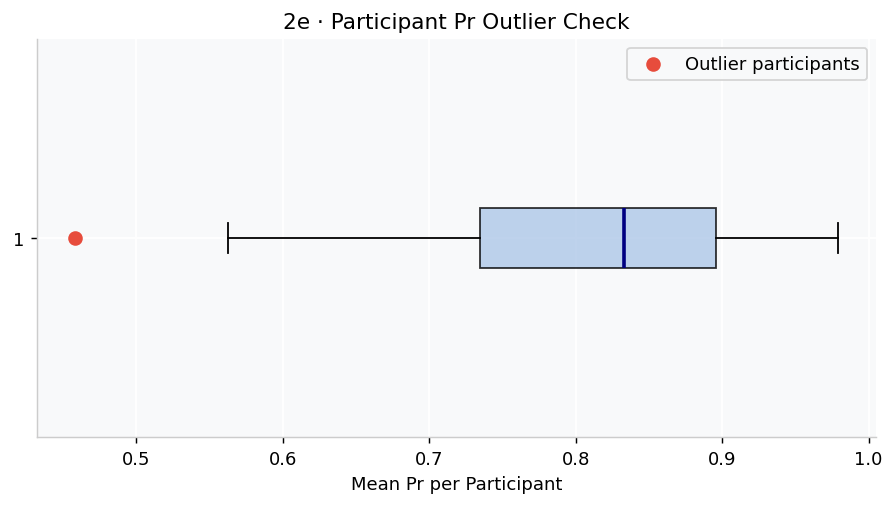

In [10]:


print("\n── 2a · Empty / Sparse Condition Check ──")
cond_counts = trial_df_valid.groupby("condition_full")["outcome"].count()
EMPTY_CONDS = []
SPARSE_CONDS = []
for cond in FULL_CONDS:
    n = cond_counts.get(cond, 0)
    if n == 0:
        EMPTY_CONDS.append(cond)
        print(f"  ⚠ EMPTY   : {cond} — 0 trials (excluded from all tests)")
    elif n < 30:
        SPARSE_CONDS.append(cond)
        print(f"  ⚠ SPARSE  : {cond} — only {n} trials (interpret with caution)")
    else:
        print(f"  ✓ OK      : {cond} — {n} trials")
 
# VALID_CONDS = [c for c in FULL_CONDS if c not in EMPTY_CONDS]
# VALID_WORD_CONDS = sorted(set(c.split("_")[0] for c in VALID_CONDS))
VALID_CONDS = [c for c in FULL_CONDS if c not in EMPTY_CONDS and not c.startswith("HF")]
VALID_WORD_CONDS = sorted(set(c.split("_")[0] for c in VALID_CONDS))
 

print(f"\n── 2b · RT Outlier Removal (hard: <{RT_LOW} or >{RT_HIGH} ms) ──")


trial_df_valid = trial_df_valid.copy().reset_index(drop=True)

n_before = trial_df_valid["rt_ir"].notna().sum()
trial_df_valid["rt_ir_raw"] = trial_df_valid["rt_ir"].copy()


hard_mask = (trial_df_valid["rt_ir"] < RT_LOW) | (trial_df_valid["rt_ir"] > RT_HIGH)
trial_df_valid.loc[hard_mask, "rt_ir"] = np.nan
n_trimmed_hard = n_before - trial_df_valid["rt_ir"].notna().sum()
print(f"  Hard cutoff trimmed : {n_trimmed_hard} RT values")

# Soft ±3SD per participant — vectorized, no apply
rt_stats = (trial_df_valid.groupby("participant")["rt_ir"]
            .agg(["mean", "std"]).rename(columns={"mean": "rt_mean", "std": "rt_std"}))
trial_df_valid = trial_df_valid.join(rt_stats, on="participant")

soft_mask = (
    (trial_df_valid["rt_ir"] < trial_df_valid["rt_mean"] - RT_SD_THRESHOLD * trial_df_valid["rt_std"]) |
    (trial_df_valid["rt_ir"] > trial_df_valid["rt_mean"] + RT_SD_THRESHOLD * trial_df_valid["rt_std"])
)
trial_df_valid.loc[soft_mask, "rt_ir"] = np.nan
trial_df_valid = trial_df_valid.drop(columns=["rt_mean", "rt_std"])

n_after = trial_df_valid["rt_ir"].notna().sum()
n_trimmed_soft = n_before - n_trimmed_hard - n_after
print(f"  Soft ±{RT_SD_THRESHOLD}SD trimmed : {max(n_trimmed_soft, 0)} additional RT values")
print(f"  RT values remaining  : {n_after:,} / {n_before:,}")



# 2c · Raw distributions of Hit Rate, FA Rate, Pr per condition
print("\n── 2c · Raw Rate Distributions ──")
def compute_raw_rates(sub):
    sem    = sub["semantic_repeat"].astype(bool)
    ir     = sub["ir_pressed"].astype(bool)
    n_sig  = sem.sum()
    n_nos  = (~sem).sum()
    hits   = (sem & ir).sum()
    fas    = (~sem & ir).sum()
    hr     = hits / max(n_sig, 1)
    far    = fas  / max(n_nos, 1)
    return pd.Series({"hit_rate": hr, "fa_rate": far, "Pr": hr - far,
                      "n_signal": n_sig, "n_noise": n_nos,
                      "hits": hits, "fas": fas})
 
try:
    pr_ppt = (trial_df_valid
              .groupby(["participant", "word_condition", "voice", "condition_full"])
              .apply(compute_raw_rates, include_groups=False)
              .reset_index())
except TypeError:
    pr_ppt = (trial_df_valid
              .groupby(["participant", "word_condition", "voice", "condition_full"])
              .apply(compute_raw_rates)
              .reset_index())
 
pr_ppt = pr_ppt[pr_ppt["condition_full"].isin(VALID_CONDS)].dropna(subset=["Pr"])
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
    ["hit_rate", "fa_rate", "Pr"],
    ["Hit Rate", "FA Rate", "Corrected Pr"]):
    for xi, cond in enumerate(VALID_CONDS):
        wc   = cond.split("_")[0]
        vals = pr_ppt[pr_ppt.condition_full == cond][col].dropna().values
        if len(vals) > 0:
            jitter = np.random.default_rng(42).normal(0, 0.08, size=len(vals))
            ax.scatter(xi + jitter, vals, alpha=0.35, s=15,
                       color=COND_PALETTE.get(wc, GREY))
    ax.set_xticks(range(len(VALID_CONDS)))
    ax.set_xticklabels([c.replace("_", "\n") for c in VALID_CONDS],
                       fontsize=7, rotation=0)
    ax.set_title(title, fontsize=12)
axes[0].set_ylabel("Rate per Participant")


fig.suptitle("Figure 2a · Raw Rate Distributions per Condition",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig02a_raw_distributions.png", bbox_inches="tight")
plt.show()
 
# 2d · Ceiling / floor detection ─────────────────────────────
print("\n── 2d · Ceiling / Floor Detection ──")
pr_cond_mean = pr_ppt.groupby("condition_full")["Pr"].mean()
for cond, mean_pr in pr_cond_mean.items():
    if mean_pr > 0.95:
        print(f"  ⚠ CEILING : {cond}  Pr = {mean_pr:.3f} (may lack sensitivity)")
    elif mean_pr < 0.05:
        print(f"  ⚠ FLOOR   : {cond}  Pr = {mean_pr:.3f} (may lack sensitivity)")
    else:
        print(f"  ✓ OK      : {cond}  Pr = {mean_pr:.3f}")
 
# 2e · Participant-level Pr outlier detection (IQR) ──────────
print("\n── 2e · Participant-Level Pr Outlier Detection (IQR 1.5×) ──")
pr_by_ppt = pr_ppt.groupby("participant")["Pr"].mean()
Q1, Q3    = pr_by_ppt.quantile(0.25), pr_by_ppt.quantile(0.75)
IQR       = Q3 - Q1
outlier_ppts = pr_by_ppt[(pr_by_ppt < Q1 - 1.5*IQR) | (pr_by_ppt > Q3 + 1.5*IQR)]
if len(outlier_ppts) == 0:
    print("  ✓ No participant-level Pr outliers detected.")
else:
    print(f"  ⚠ {len(outlier_ppts)} participant(s) are Pr outliers:")
    for pid, val in outlier_ppts.items():
        print(f"    Participant {pid}: mean Pr = {val:.3f}")
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(pr_by_ppt.values, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#AEC7E8", alpha=0.8),
           medianprops=dict(color="navy", linewidth=2))
ax.scatter(outlier_ppts.values, [1]*len(outlier_ppts),
           color="#e74c3c", zorder=5, s=50, label="Outlier participants")
ax.set_xlabel("Mean Pr per Participant"); ax.set_title("2e · Participant Pr Outlier Check")
if len(outlier_ppts): ax.legend()
plt.tight_layout()
plt.savefig("fig02e_participant_outliers.png", bbox_inches="tight")
plt.show()
 

---
## Section 2 · NORMALITY & VARIANCE TESTING
---


── 3a · Shapiro-Wilk (n≤50) / KS test (n>50) per condition ──
  HH_active            n= 106  KS             stat=0.2536  p=0.0000  ✗ NON-NORMAL
  HH_passive           n= 106  KS             stat=0.2346  p=0.0000  ✗ NON-NORMAL
  HVL_active           n= 106  KS             stat=0.1977  p=0.0004  ✗ NON-NORMAL
  HVL_passive          n= 106  KS             stat=0.2367  p=0.0000  ✗ NON-NORMAL
  LVH_active           n= 106  KS             stat=0.2381  p=0.0000  ✗ NON-NORMAL
  LVH_passive          n= 106  KS             stat=0.2477  p=0.0000  ✗ NON-NORMAL
  LVL_active           n= 106  KS             stat=0.2183  p=0.0001  ✗ NON-NORMAL
  LVL_passive          n= 106  KS             stat=0.2019  p=0.0003  ✗ NON-NORMAL


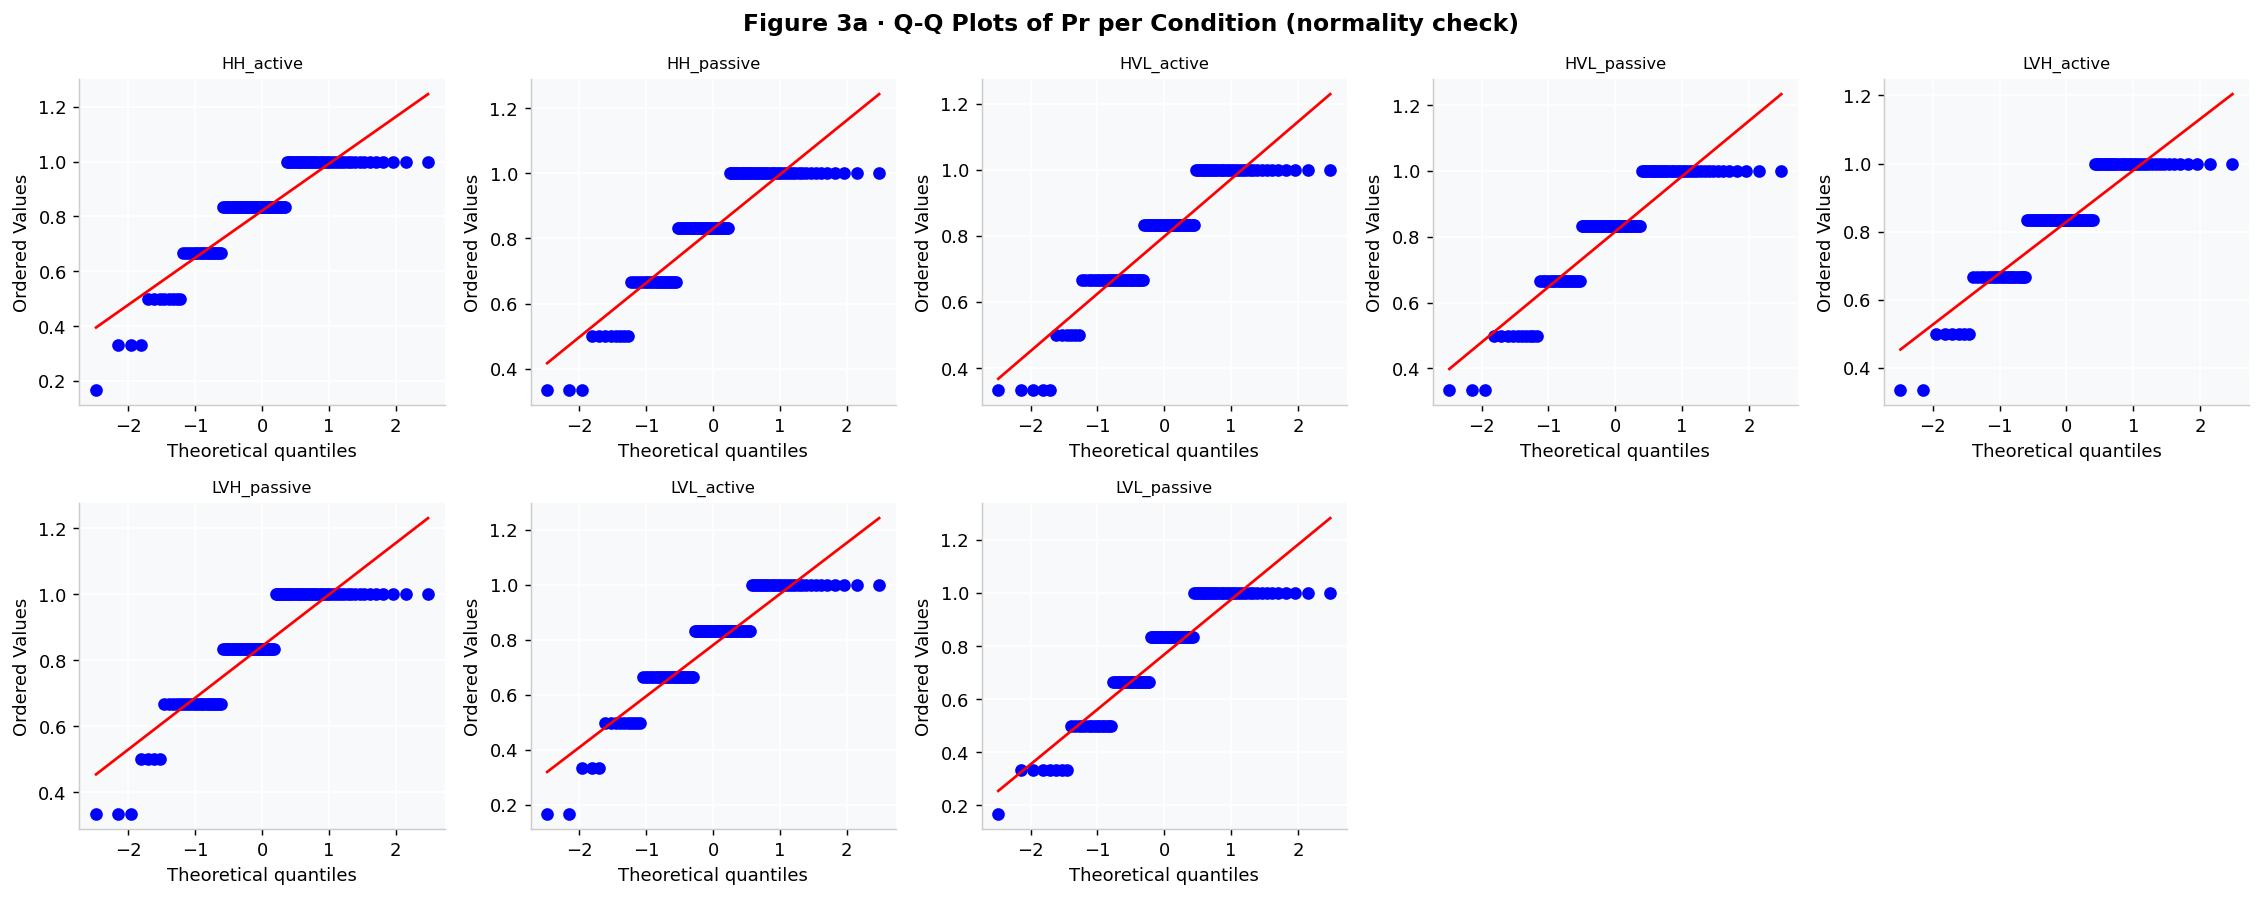


── 3c · Levene's Test (equal variances across conditions) ──
  Levene's F = 1.861,  p = 0.0729  n.s.
  Equal variances : YES

── 3d · Statistical Path Decision ──
  → At least one condition fails normality or equal-variance assumption.
  → Non-parametric path: Kruskal-Wallis.
  PRIMARY TEST: Kruskal-Wallis


In [11]:

normality_results = []
alpha_norm = 0.05
 
print(f"\n── 3a · Shapiro-Wilk (n≤50) / KS test (n>50) per condition ──")
for cond in VALID_CONDS:
    vals = pr_ppt[pr_ppt.condition_full == cond]["Pr"].dropna().values
    n    = len(vals)
    if n < 3:
        normality_results.append({"condition": cond, "n": n, "test": "—",
                                   "stat": np.nan, "p": np.nan, "normal": None})
        continue
    if n <= 50:
        stat, p = shapiro(vals)
        test_name = "Shapiro-Wilk"
    else:
        stat, p = kstest(vals, "norm", args=(vals.mean(), vals.std()))
        test_name = "KS"
    is_normal = p > alpha_norm
    normality_results.append({"condition": cond, "n": n, "test": test_name,
                               "stat": round(stat, 4), "p": round(p, 4),
                               "normal": is_normal})
    flag = "✓ normal" if is_normal else "✗ NON-NORMAL"
    print(f"  {cond:<20} n={n:>4}  {test_name:<14} stat={stat:.4f}  "
          f"p={p:.4f}  {flag}")
 
norm_df = pd.DataFrame(normality_results)
any_non_normal = norm_df["normal"].eq(False).any()
 
# 3b · Q-Q plots ──────────────────────────────────────────────
n_vc = len(VALID_CONDS)
ncols = 5
nrows = int(np.ceil(n_vc / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
axes = np.array(axes).flatten()
for i, cond in enumerate(VALID_CONDS):
    vals = pr_ppt[pr_ppt.condition_full == cond]["Pr"].dropna().values
    if len(vals) > 3:
        stats.probplot(vals, dist="norm", plot=axes[i])
    axes[i].set_title(cond, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Figure 3a · Q-Q Plots of Pr per Condition (normality check)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig03a_qq_plots.png", bbox_inches="tight")
plt.show()
 
# 3c · Levene's test for homogeneity of variance ─────────────
print("\n── 3c · Levene's Test (equal variances across conditions) ──")
groups_lev = [pr_ppt[pr_ppt.condition_full == c]["Pr"].dropna().values
              for c in VALID_CONDS if len(pr_ppt[pr_ppt.condition_full == c]) >= 2]
if len(groups_lev) >= 2:
    L_stat, L_p = levene(*groups_lev)
    print(f"  Levene's F = {L_stat:.3f},  p = {L_p:.4f}  {sig_stars(L_p)}")
    equal_var = L_p > alpha_norm
    print(f"  Equal variances : {'YES' if equal_var else 'NO'}")
else:
    L_stat, L_p, equal_var = np.nan, np.nan, False
 
# 3d · Decision rule ─────────────────────────────────────────
print("\n── 3d · Statistical Path Decision ──")
if any_non_normal or not equal_var:
    print("  → At least one condition fails normality or equal-variance assumption.")
    print("  → Non-parametric path: Kruskal-Wallis.")
    # print("  → This is consistent with the pre-registered analysis plan.")
else:
    print("  → All conditions appear normal with equal variances.")
    print("  → Parametric ANOVA would be justified, BUT Kruskal-Wallis")
    print("     is used as pre-registered in the analysis plan.")
print("  PRIMARY TEST: Kruskal-Wallis")
 

---
## PROBLEM FRAMING

---


### DIFFERENCE-BASED HYPOTHESES (group comparison)

- **H1 · Word Memorability Effect**  
    Do conditions differ in corrected memorability (Pr)?  
    HH > {HL, LH} > LL expected.  
    Test: Kruskal-Wallis across word conditions.  
    Post-hoc: Dunn’s test, Bonferroni AND BH correction.

- **H2 · Voice Effect**  
    Do active sentences have higher Pr than passive?  
    Test: Wilcoxon signed-rank (paired, per participant).

- **H3 · Word × Voice Interaction**  
    Is the voice effect modulated by word memorability?  
    Test (primary): ART-ANOVA (Aligned Ranks Transformation)  
    Test (check): Friedman (per voice level)

### RELATION-BASED HYPOTHESIS (correlation / regression)

- **H4 · IR–WR Relationship**  
    Do sentences with higher IR memorability also show higher WR (verbatim) accuracy?  
    Test: Pearson r + Spearman ρ at sentence level.  
    Model: linear regression `WR ~ IR` per category.
---
---

---
## Section 3 · Behavioural Overview

---


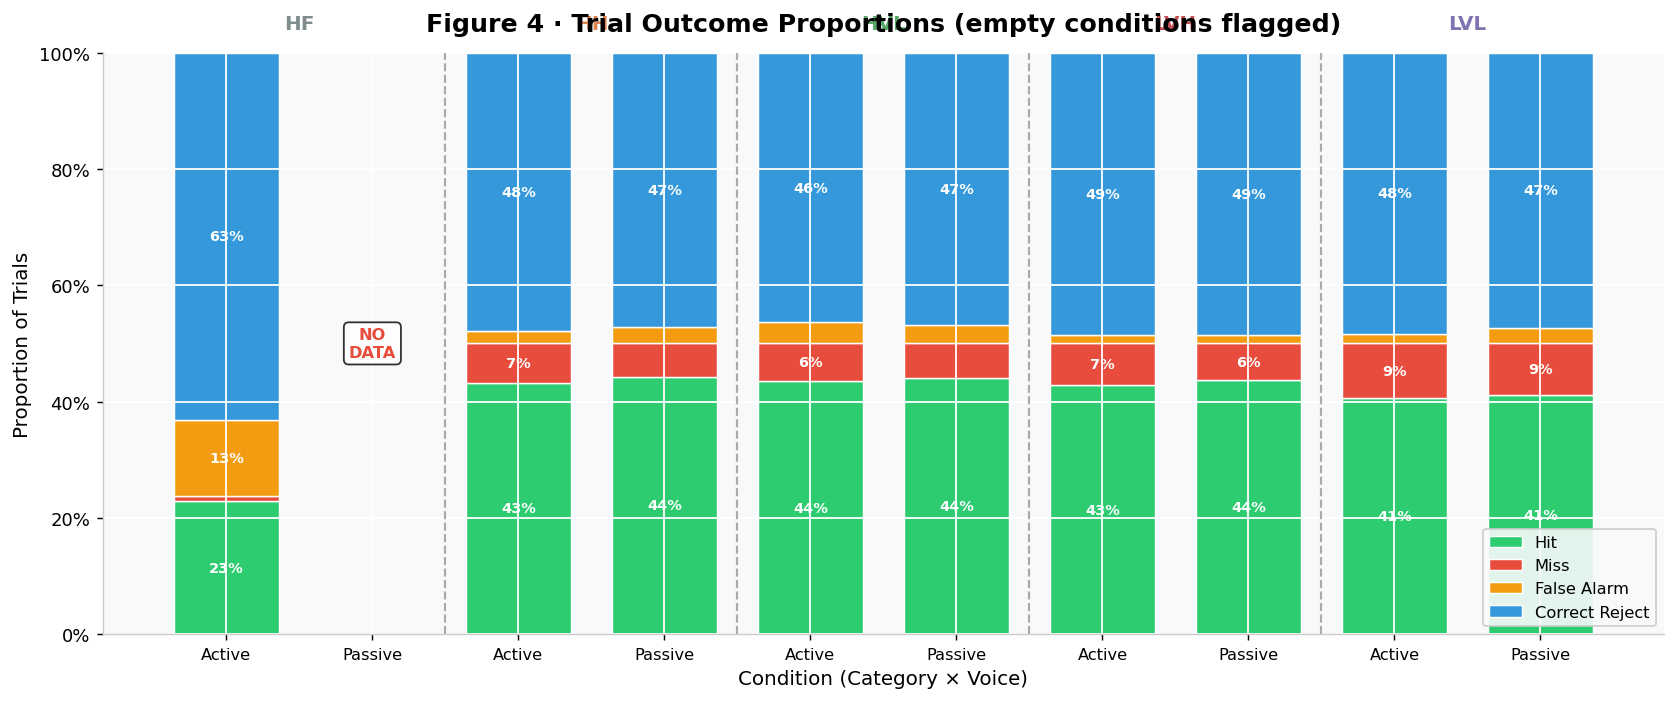


Outcome proportions per condition:
outcome           Hit   Miss  False Alarm  Correct Reject
condition_full                                           
HF_active       0.228  0.010        0.130           0.632
HF_passive      0.000  0.000        0.000           0.000
HH_active       0.432  0.068        0.022           0.478
HH_passive      0.443  0.057        0.028           0.472
HVL_active      0.436  0.064        0.036           0.464
HVL_passive     0.440  0.060        0.032           0.468
LVH_active      0.428  0.072        0.014           0.486
LVH_passive     0.436  0.064        0.015           0.485
LVL_active      0.406  0.094        0.016           0.484
LVL_passive     0.411  0.089        0.027           0.473


In [12]:

ORDER_OUT = ["Hit", "Miss", "False Alarm", "Correct Reject"]
cat_prop  = (
    trial_df_valid.groupby(["condition_full", "outcome"])
    .size().unstack(fill_value=0)
    .reindex(columns=ORDER_OUT, fill_value=0)
    .apply(lambda r: r / r.sum() if r.sum() > 0 else r, axis=1)
    .reindex(FULL_CONDS).fillna(0)
)
 
fig, ax = plt.subplots(figsize=(max(12, len(FULL_CONDS) * 1.3), 5.5))
x      = np.arange(len(FULL_CONDS))
bottom = np.zeros(len(FULL_CONDS))
nv     = len(VOICES)
 
for outcome in ORDER_OUT:
    vals = cat_prop[outcome].values
    bars = ax.bar(x, vals, bottom=bottom, color=OUT_PALETTE[outcome],
                  label=outcome, width=0.72, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        if v > 0.06:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{v:.0%}", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals
 
# Mark empty conditions
for i, cond in enumerate(FULL_CONDS):
    if cond in EMPTY_CONDS:
        ax.text(i, 0.5, "NO\nDATA", ha="center", va="center",
                fontsize=9, fontweight="bold", color="#e74c3c",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
for k in range(1, len(WORD_CONDS)):
    ax.axvline(k * nv - 0.5, color="#aaaaaa", linewidth=1.2, linestyle="--")
ax.set_xticks(x)
xtlabels = [c.split("_")[1].capitalize() if "_" in c else c for c in FULL_CONDS]
ax.set_xticklabels(xtlabels, fontsize=9)
for i, wc in enumerate(WORD_CONDS):
    mid = i * nv + (nv - 1) / 2
    ax.text(mid, 1.04, wc, ha="center", fontsize=11, fontweight="bold",
            color=COND_PALETTE.get(wc, GREY), transform=ax.get_xaxis_transform())
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("Condition (Category × Voice)", **FONT_LABEL)
ax.set_ylabel("Proportion of Trials", **FONT_LABEL)
ax.set_title("Figure 4 · Trial Outcome Proportions (empty conditions flagged)",
             **FONT_TITLE)
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig("fig04_outcome_proportions.png", bbox_inches="tight")
plt.show()
 
print("\nOutcome proportions per condition:")
print(cat_prop.round(3).to_string())
 

---
## Section 4 · MEMORABILITY SCORING  (Pr + d')

---



  Log-linear correction applied to 761 cells where HR or FAR was 0 or 1.

  Per-condition Pr and d' summary:
  HH_active             Pr = 0.821 ± 0.018  d' = 2.298
  HH_passive            Pr = 0.830 ± 0.017  d' = 2.322
  HVL_active            Pr = 0.799 ± 0.018  d' = 2.220
  HVL_passive           Pr = 0.816 ± 0.017  d' = 2.277
  LVH_active            Pr = 0.829 ± 0.016  d' = 2.313
  LVH_passive           Pr = 0.843 ± 0.017  d' = 2.372
  LVL_active            Pr = 0.781 ± 0.019  d' = 2.188
  LVL_passive           Pr = 0.769 ± 0.021  d' = 2.157


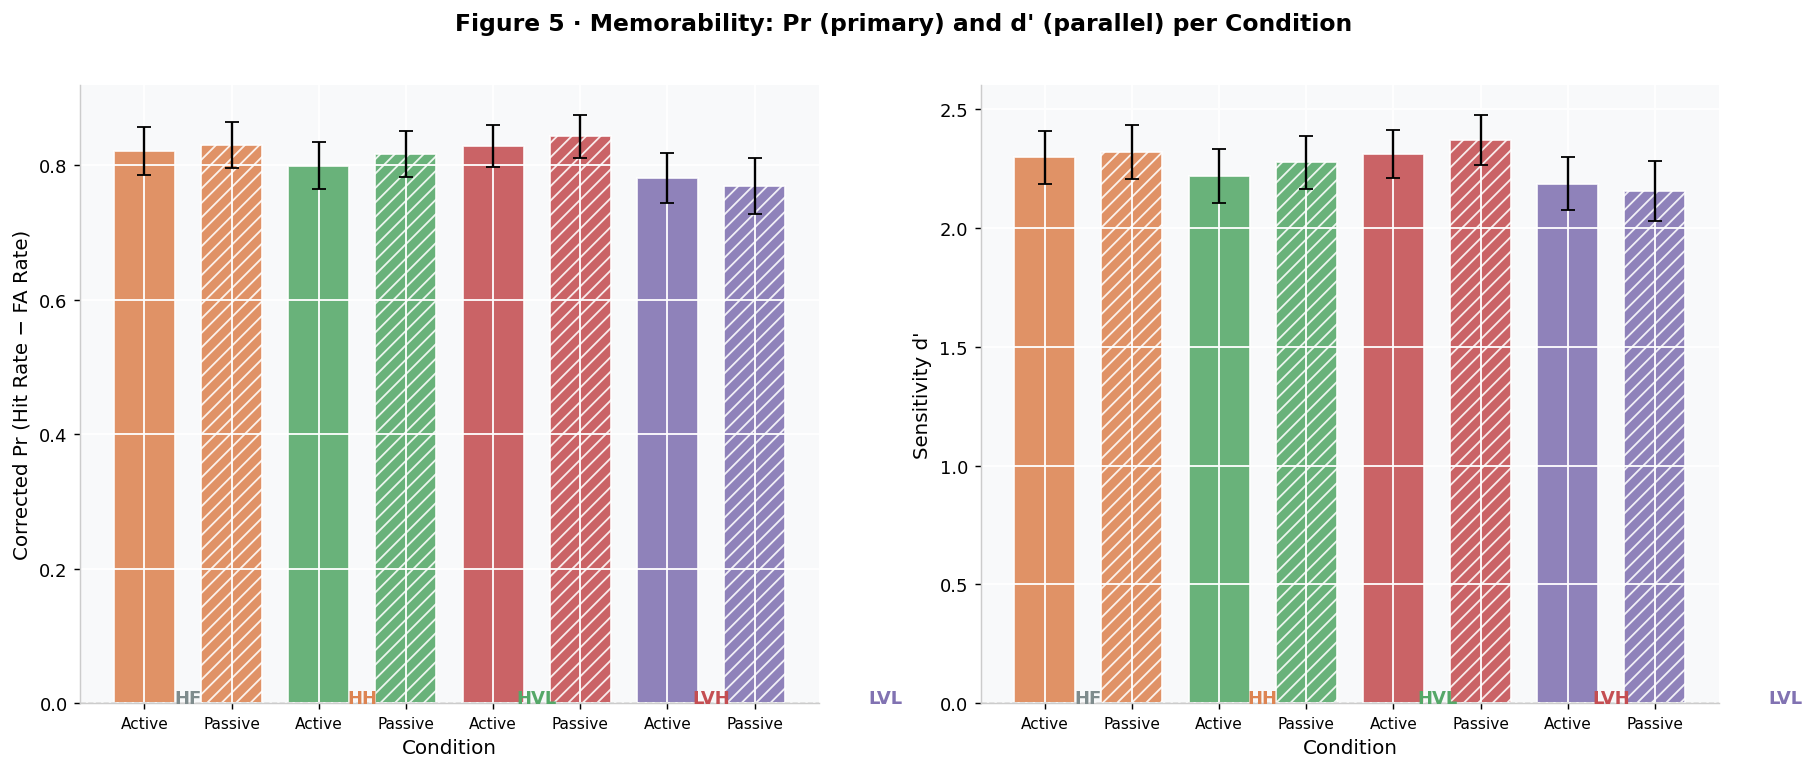

In [13]:

# d' with log-linear correction where rates are 0 or 1
def compute_dprime_row(row):
    hr, far = log_linear_correction(row["hits"], row["n_signal"],
                                     row["fas"],  row["n_noise"])
    return compute_dprime(hr, far)
 
pr_ppt["dprime"] = pr_ppt.apply(compute_dprime_row, axis=1)
n_corrected = ((pr_ppt["hit_rate"] == 0) | (pr_ppt["hit_rate"] == 1) |
               (pr_ppt["fa_rate"]  == 0) | (pr_ppt["fa_rate"]  == 1)).sum()
print(f"\n  Log-linear correction applied to {n_corrected} cells "
      f"where HR or FAR was 0 or 1.")
 
pr_sum = (pr_ppt[pr_ppt.condition_full.isin(VALID_CONDS)]
          .groupby(["word_condition", "voice", "condition_full"])[["Pr", "dprime"]]
          .agg(["mean", "sem", "count"]).reset_index())
pr_sum.columns = ["_".join(c).strip("_") for c in pr_sum.columns]
pr_sum = pr_sum.rename(columns={
    "word_condition_": "word_condition", "voice_": "voice",
    "condition_full_": "condition_full"
})
 
print("\n  Per-condition Pr and d' summary:")
for _, row in pr_sum.iterrows():
    print(f"  {row['condition_full']:<20}  "
          f"Pr = {row.get('Pr_mean', np.nan):.3f} ± {row.get('Pr_sem', np.nan):.3f}  "
          f"d' = {row.get('dprime_mean', np.nan):.3f}")
 
# Figure · Pr and d' side by side for all valid conditions
n_vc = len(VALID_CONDS)
fig, axes = plt.subplots(1, 2, figsize=(max(14, n_vc * 1.4), 6))
for ax, metric, ylabel in zip(axes,
    ["Pr_mean",     "dprime_mean"],
    ["Corrected Pr (Hit Rate − FA Rate)", "Sensitivity d'"]):
    sem_col = metric.replace("mean", "sem")
    for i, cond in enumerate(VALID_CONDS):
        sub = pr_sum[pr_sum.condition_full == cond]
        if sub.empty: continue
        wc    = cond.split("_")[0]
        voice = cond.split("_")[1] if "_" in cond else ""
        m     = float(sub[metric].iloc[0])
        s     = float(sub[sem_col].iloc[0])
        color = COND_PALETTE.get(wc, GREY)
        hatch = VOICE_HATCH.get(voice, "")
        ax.bar(i, m, color=color, hatch=hatch, width=0.7,
               edgecolor="white", alpha=0.88,
               label=f"{wc} ({voice})" if i < len(WORD_CONDS)*2 else "")
        ax.errorbar(i, m, yerr=s * 1.96, fmt="none",
                    color="black", capsize=4, linewidth=1.3)
        # ax.text(i, m + s * 1.96 + 0.01, f"{m:.3f}", ha="center",
        #         va="bottom", fontsize=8, fontweight="bold", color=color)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks(range(n_vc))
    ax.set_xticklabels([c.split("_")[1].capitalize() for c in VALID_CONDS],
                       fontsize=8.5)
    for i, wc in enumerate(WORD_CONDS):
        nv_ = len(VOICES)
        mid = i * nv_ + (nv_ - 1) / 2
        ax.text(mid, ax.get_ylim()[1] * 0.0001 if ax.get_ylim()[1] != 0 else 0.02,
                wc, ha="center", fontsize=10, fontweight="bold",
                color=COND_PALETTE.get(wc, GREY),
                transform=ax.get_xaxis_transform())
    ax.set_ylabel(ylabel, **FONT_LABEL)
    ax.set_xlabel("Condition", **FONT_LABEL)
 
fig.suptitle("Figure 5 · Memorability: Pr (primary) and d' (parallel) per Condition\n"
             ,
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig05_pr_dprime.png", bbox_inches="tight")
plt.show()

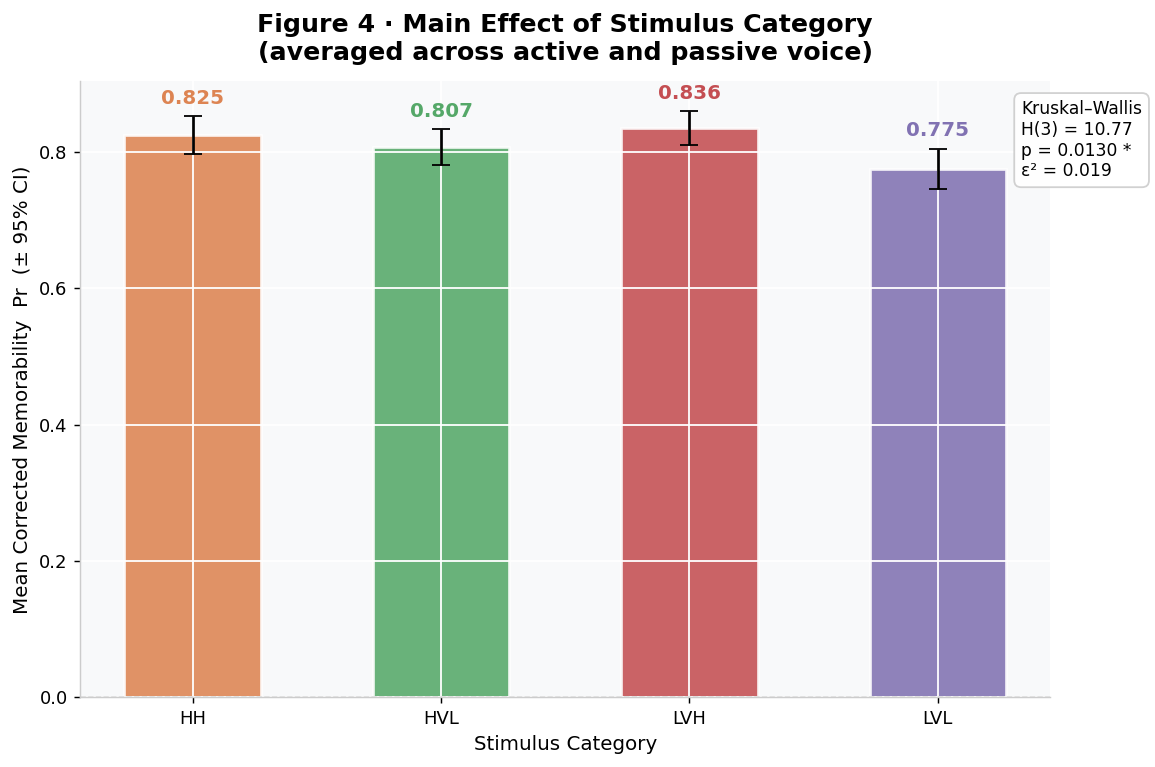

Kruskal–Wallis (category): H = 10.774, p = 0.0130,  ε² = 0.0185


In [14]:
# ── Figure 4 · Main Effect of Stimulus Category (collapsed across voice) ──────
pr_by_wc  = pr_ppt.groupby(["participant", "word_condition"])["Pr"].mean().reset_index()
wc_sum    = pr_by_wc.groupby("word_condition")["Pr"].agg(["mean","sem"]).reindex(WORD_CONDS)
groups_wc = [pr_by_wc[pr_by_wc.word_condition == wc]["Pr"].dropna() for wc in WORD_CONDS]
groups_wc = [g for g in groups_wc if len(g) >= 2]

H_wc, p_wc = kruskal(*groups_wc)
N_wc     = sum(len(g) for g in groups_wc)
k_wc     = len(groups_wc)
eps2_wc  = max((H_wc - k_wc + 1) / (N_wc - k_wc), 0) if N_wc > k_wc else 0

fig, ax = plt.subplots(figsize=(9, 6))
x_pos = range(len(WORD_CONDS))
bars  = ax.bar(WORD_CONDS, wc_sum["mean"],
               color=[COND_PALETTE.get(wc, GREY) for wc in WORD_CONDS],
               width=0.55, edgecolor="white", linewidth=1.5, alpha=0.88)
ax.errorbar(x_pos, wc_sum["mean"], yerr=wc_sum["sem"] * 1.96,
            fmt="none", color="black", capsize=5, linewidth=1.5, zorder=5)
for i, (wc, row) in enumerate(wc_sum.iterrows()):
    if not pd.isna(row["mean"]):
        ax.text(i, row["mean"] + row["sem"] * 1.96 + 0.012,
                f"{row['mean']:.3f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=COND_PALETTE.get(wc, GREY))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

sig = "***" if p_wc < 0.001 else ("**" if p_wc < 0.01 else ("*" if p_wc < 0.05 else "n.s."))
ax.text(0.97, 0.97,
        f"Kruskal–Wallis\nH({k_wc-1}) = {H_wc:.2f}\np = {p_wc:.4f} {sig}\nε² = {eps2_wc:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.9))

ax.set_xlabel("Stimulus Category", **FONT_LABEL)
ax.set_ylabel("Mean Corrected Memorability  Pr  (± 95% CI)", **FONT_LABEL)
ax.set_title(
    "Figure 4 · Main Effect of Stimulus Category\n"
    "(averaged across active and passive voice)", **FONT_TITLE
)
plt.tight_layout()
plt.savefig("fig4_main_effect_category.png", bbox_inches="tight")
plt.show()
print(f"Kruskal–Wallis (category): H = {H_wc:.3f}, p = {p_wc:.4f},  ε² = {eps2_wc:.4f}")


### STATISTICAL TESTS


── 7a · Kruskal-Wallis: All Valid Conditions ──
  H(7) = 11.847,  p = 0.1057 n.s.,  ε² = 0.0058
  Effect size: small

── 7b · Kruskal-Wallis + Dunn's Post-Hoc (H1: word condition) ──
  KW H(3) = 10.774,  p = 0.0130 *,  ε² = 0.0185

  Post-hoc Dunn's test (Bonferroni AND BH):
  A   B      U  p_raw  p_bonf sig_bonf   p_bh sig_bh  effect_r
 HH HVL 6073.0 0.3012  1.0000     n.s. 0.3614   n.s.    -0.081
 HH LVH 5496.0 0.7817  1.0000     n.s. 0.7817   n.s.     0.022
 HH LVL 6740.5 0.0111  0.0664     n.s. 0.0332      *    -0.200
HVL LVH 4998.5 0.1581  0.9487     n.s. 0.2372   n.s.     0.110
HVL LVL 6380.0 0.0846  0.5077     n.s. 0.1692   n.s.    -0.136
LVH LVL 6932.5 0.0029  0.0173        * 0.0173      *    -0.234


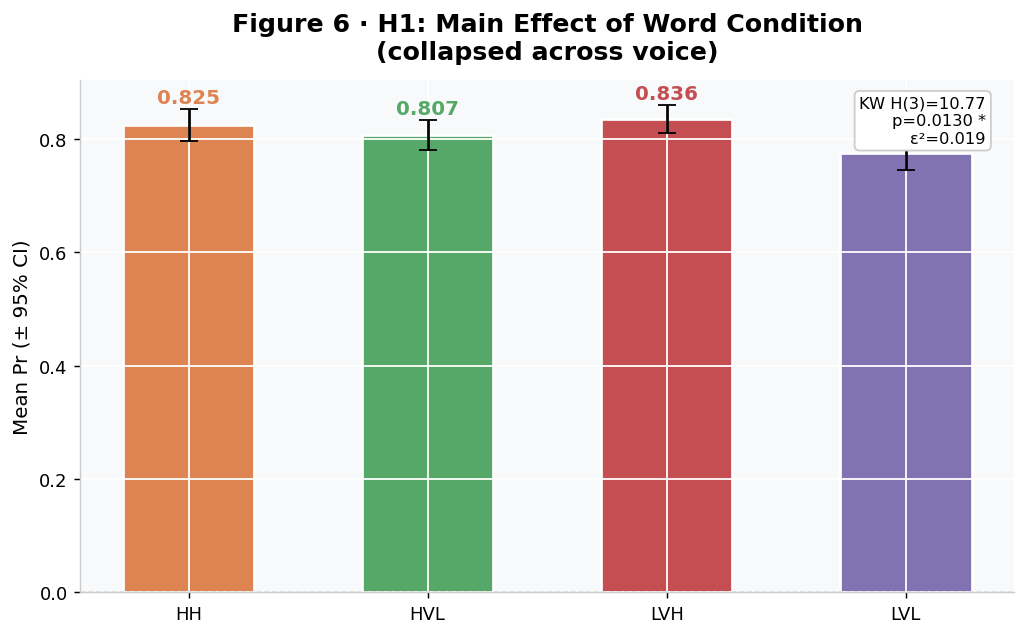

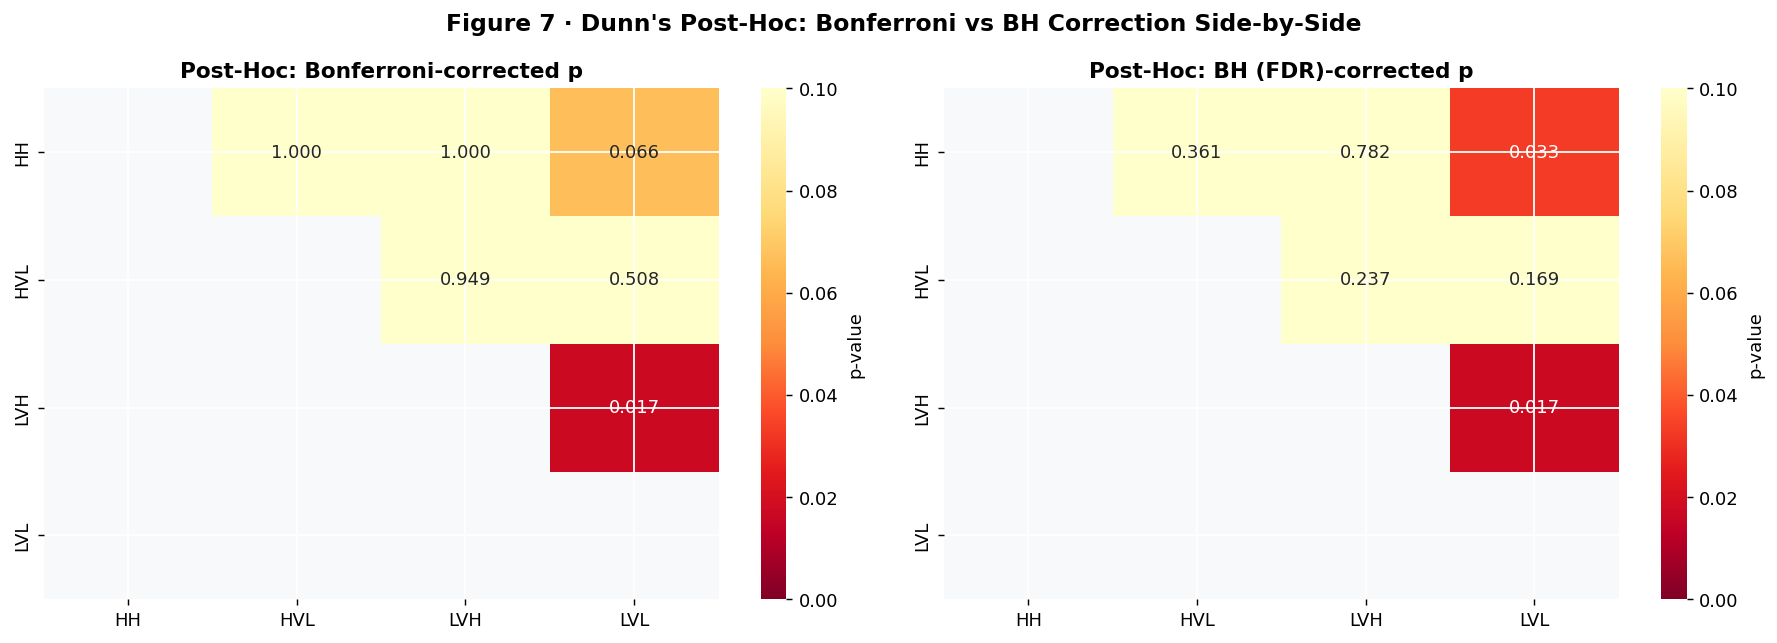


── 7c · Wilcoxon Signed-Rank (H2: Voice Effect) ──
  Wilcoxon W = 1595.5,  p = 0.3970 n.s.
  Effect size r = 0.437
  Active  Pr = 0.8074  Passive Pr = 0.8145  Δ = -0.0071
  n (paired) = 106


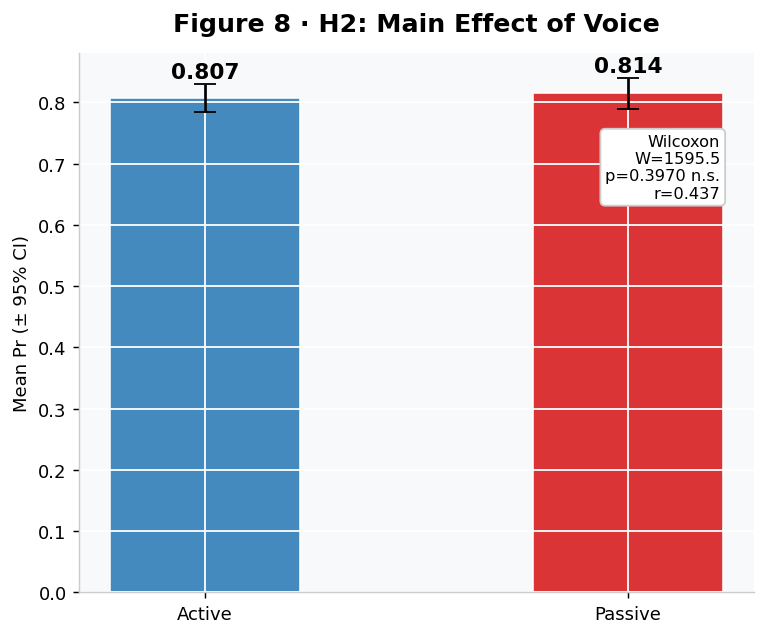


── 7d · H3: Word × Voice Interaction ──

  [PRIMARY] ART-ANOVA (Aligned Ranks Transformation):
  Main Effect: word_condition
    F = 12.703,  p = 0.0 ***,  validity ρ = 0.19  ✓ valid
  Main Effect: voice
    F = 0.232,  p = 0.8741 n.s.,  validity ρ = -0.976  ⚠ check validity
  Interaction: word_condition × voice
    F = 0.159,  p = 0.9242 n.s.,  validity ρ = -0.952  ⚠ check validity

  [CHECK] Friedman test per voice level:
  Voice=active:  χ²(3) = 2.608,  p = 0.4562 n.s.
  Voice=passive:  χ²(3) = 7.010,  p = 0.0716 n.s.


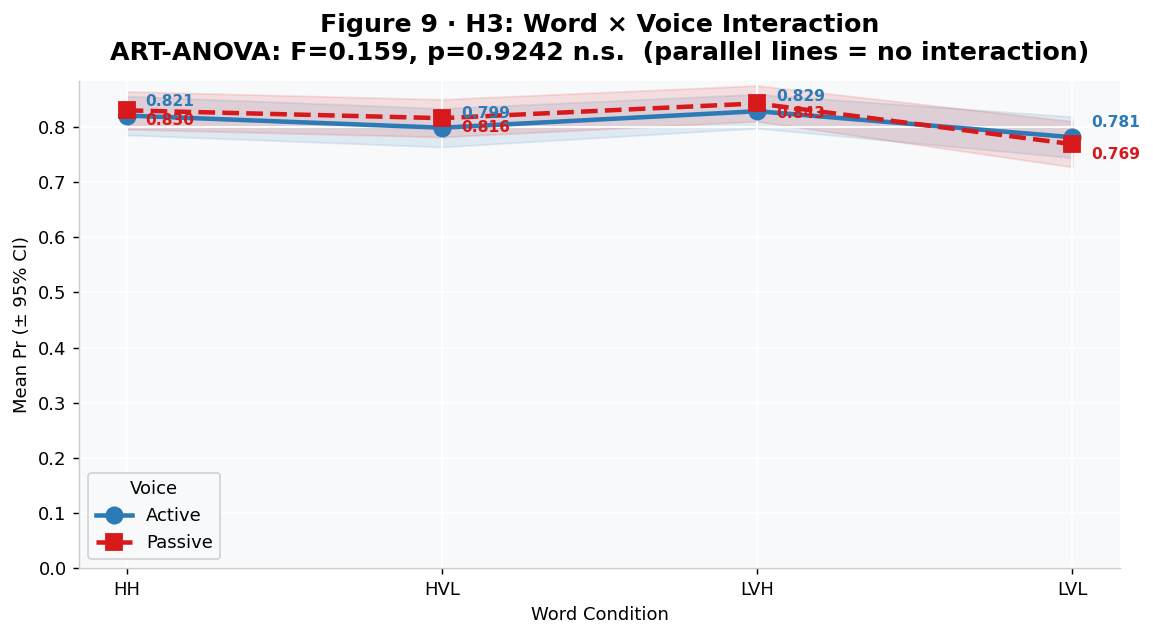


── 7e · H4: IR–WR Relationship (sentence-level correlation) ──
  Pearson  r  = 0.060,   p = 0.2391 n.s.,  R² = 0.004
  Spearman ρ  = 0.048,  p = 0.3410 n.s.
  Regression: WR = 0.694 + 0.079×IR  (SE=0.067)


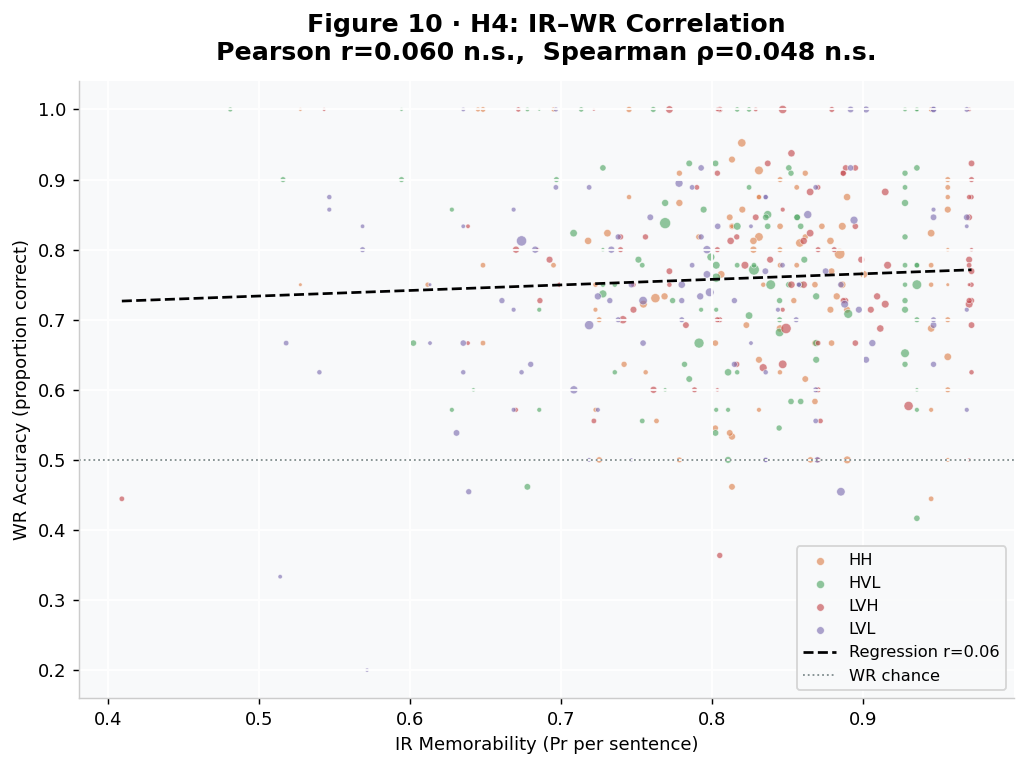

In [15]:

pr_by_full = (pr_ppt[pr_ppt.condition_full.isin(VALID_CONDS)]
              .groupby(["participant", "condition_full"])["Pr"]
              .mean().reset_index())
pr_by_wc   = (pr_ppt[pr_ppt.condition_full.isin(VALID_CONDS)]
              .groupby(["participant", "word_condition"])["Pr"]
              .mean().reset_index())
pr_by_v    = (pr_ppt[pr_ppt.condition_full.isin(VALID_CONDS)]
              .groupby(["participant", "voice"])["Pr"]
              .mean().reset_index())
 
# ── 7a · KW: All valid conditions ────────────────────────────
print("\n── 7a · Kruskal-Wallis: All Valid Conditions ──")
groups_full = [pr_by_full[pr_by_full.condition_full == c]["Pr"].dropna().values
               for c in VALID_CONDS
               if len(pr_by_full[pr_by_full.condition_full == c]) >= 2]
if len(groups_full) >= 2:
    H_all, p_all = kruskal(*groups_full)
    N_all, k_all = sum(len(g) for g in groups_full), len(groups_full)
    e2_all       = eps_squared(H_all, k_all, N_all)
    print(f"  H({k_all-1}) = {H_all:.3f},  p = {p_all:.4f} {sig_stars(p_all)},  "
          f"ε² = {e2_all:.4f}")
    print(f"  Effect size: {'small' if e2_all<0.06 else ('medium' if e2_all<0.14 else 'large')}")
 
# ── 7b · KW + Dunn (H1: word condition) ─────────────────────
print(f"\n── 7b · Kruskal-Wallis + Dunn's Post-Hoc (H1: word condition) ──")
groups_wc = [pr_by_wc[pr_by_wc.word_condition == wc]["Pr"].dropna().values
             for wc in VALID_WORD_CONDS
             if len(pr_by_wc[pr_by_wc.word_condition == wc]) >= 2]
if len(groups_wc) >= 2:
    H_wc, p_wc = kruskal(*groups_wc)
    N_wc       = sum(len(g) for g in groups_wc)
    k_wc       = len(groups_wc)
    e2_wc      = eps_squared(H_wc, k_wc, N_wc)
    print(f"  KW H({k_wc-1}) = {H_wc:.3f},  p = {p_wc:.4f} {sig_stars(p_wc)},  "
          f"ε² = {e2_wc:.4f}")
 
print(f"\n  Post-hoc Dunn's test (Bonferroni AND BH):")
dunn_tbl = dunn_both_corrections(pr_by_wc, VALID_WORD_CONDS)
print(dunn_tbl.to_string(index=False))
 
# Figure: word condition main effect
wc_sum = pr_by_wc.groupby("word_condition")["Pr"].agg(["mean","sem"]).reindex(VALID_WORD_CONDS)
fig, ax = plt.subplots(figsize=(8, 5))
for i, wc in enumerate(VALID_WORD_CONDS):
    m, s = wc_sum.loc[wc, "mean"], wc_sum.loc[wc, "sem"]
    ax.bar(i, m, color=COND_PALETTE.get(wc, GREY), width=0.55,
           edgecolor="white", linewidth=1.5)
    ax.errorbar(i, m, yerr=s * 1.96, fmt="none",
                color="black", capsize=5, linewidth=1.5)
    ax.text(i, m + s * 1.96 + 0.01, f"{m:.3f}", ha="center",
            fontsize=11, fontweight="bold", color=COND_PALETTE.get(wc, GREY))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.text(0.97, 0.97,
        f"KW H({k_wc-1})={H_wc:.2f}\np={p_wc:.4f} {sig_stars(p_wc)}\nε²={e2_wc:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#ccc"))
ax.set_xticks(range(len(VALID_WORD_CONDS)))
ax.set_xticklabels(VALID_WORD_CONDS)
ax.set_ylabel("Mean Pr (± 95% CI)", **FONT_LABEL)
ax.set_title("Figure 6 · H1: Main Effect of Word Condition\n(collapsed across voice)",
             **FONT_TITLE)
plt.tight_layout()
plt.savefig("fig06_h1_word_condition.png", bbox_inches="tight")
plt.show()
 
# Figure: Dunn's results heatmap (Bonferroni vs BH)
pairs_list = list(zip(dunn_tbl["A"], dunn_tbl["B"]))
n_p = len(dunn_tbl)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
    ["p_bonf", "p_bh"],
    ["Bonferroni-corrected p", "BH (FDR)-corrected p"]):
    mat = pd.DataFrame(np.ones((len(VALID_WORD_CONDS), len(VALID_WORD_CONDS))),
                       index=VALID_WORD_CONDS, columns=VALID_WORD_CONDS)
    for _, row in dunn_tbl.iterrows():
        if not np.isnan(row[col]):
            mat.loc[row["A"], row["B"]] = row[col]
            mat.loc[row["B"], row["A"]] = row[col]
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(mat, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd_r",
                vmin=0, vmax=0.1, mask=~mask,
                cbar_kws={"label": "p-value"})
    ax.set_title(f"Post-Hoc: {title}", fontsize=12, fontweight="bold")
fig.suptitle("Figure 7 · Dunn's Post-Hoc: Bonferroni vs BH Correction Side-by-Side",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig07_dunn_corrections.png", bbox_inches="tight")
plt.show()
 
# ── 7c · Wilcoxon signed-rank (H2: voice effect) ─────────────
print(f"\n── 7c · Wilcoxon Signed-Rank (H2: Voice Effect) ──")
ppts_both = (set(pr_by_v[pr_by_v.voice == "active"]["participant"]) &
             set(pr_by_v[pr_by_v.voice == "passive"]["participant"]))
act_v = (pr_by_v[(pr_by_v.voice == "active") & pr_by_v.participant.isin(ppts_both)]
         .set_index("participant")["Pr"].sort_index())
pas_v = (pr_by_v[(pr_by_v.voice == "passive") & pr_by_v.participant.isin(ppts_both)]
         .set_index("participant")["Pr"].sort_index())
common = act_v.index.intersection(pas_v.index)
act_v, pas_v = act_v.loc[common], pas_v.loc[common]
 
if len(common) >= 5:
    W_v, p_v = wilcoxon(act_v.values, pas_v.values)
    r_v      = wilcoxon_r(W_v, len(common))
    print(f"  Wilcoxon W = {W_v:.1f},  p = {p_v:.4f} {sig_stars(p_v)}")
    print(f"  Effect size r = {r_v:.3f}")
    print(f"  Active  Pr = {act_v.mean():.4f}  "
          f"Passive Pr = {pas_v.mean():.4f}  "
          f"Δ = {(act_v - pas_v).mean():.4f}")
    print(f"  n (paired) = {len(common)}")
 
fig, ax = plt.subplots(figsize=(6, 5))
means_v = [act_v.mean(), pas_v.mean()]
sems_v  = [act_v.sem(), pas_v.sem()]
bars_v  = ax.bar(["Active", "Passive"], means_v,
                 color=[VOICE_PALETTE["active"], VOICE_PALETTE["passive"]],
                 width=0.45, edgecolor="white", alpha=0.88)
ax.errorbar([0, 1], means_v, yerr=[s * 1.96 for s in sems_v],
            fmt="none", color="black", capsize=6)
for i, (m, s) in enumerate(zip(means_v, sems_v)):
    ax.text(i, m + s * 1.96 + 0.01, f"{m:.3f}", ha="center",
            fontsize=12, fontweight="bold")
# ax.text(0.97, 0.97,
#         f"Wilcoxon\nW={W_v:.1f}\np={p_v:.4f} {sig_stars(p_v)}\nr={r_v:.3f}",
#         transform=ax.transAxes, ha="right", va="top", fontsize=9,
#         bbox=dict(boxstyle="round", facecolor="white", edgecolor="#ccc"))
ax.text(0.95, 0.85,
        f"Wilcoxon\nW={W_v:.1f}\np={p_v:.4f} {sig_stars(p_v)}\nr={r_v:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#ccc"))
ax.set_ylabel("Mean Pr (± 95% CI)"); ax.set_ylim(0)
ax.set_title("Figure 8 · H2: Main Effect of Voice", **FONT_TITLE)
plt.tight_layout()
plt.savefig("fig08_h2_voice.png", bbox_inches="tight")
plt.show()
 
# ── 7d · H3: Interaction — ART-ANOVA (primary) + Friedman (check) ──
print(f"\n── 7d · H3: Word × Voice Interaction ──")
 
pr_ppt_valid = pr_ppt[pr_ppt.condition_full.isin(VALID_CONDS)].copy()
 
# ART-ANOVA
print("\n  [PRIMARY] ART-ANOVA (Aligned Ranks Transformation):")
art_results = art_anova_2way(pr_ppt_valid, "Pr", "word_condition", "voice")
for effect, res in art_results.items():
    print(f"  {effect}")
    print(f"    F = {res['F']},  p = {res['p']} {res['sig']},  "
          f"validity ρ = {res['validity_rho']}  "
          f"{'✓ valid' if res['valid'] else '⚠ check validity'}")
 
# Friedman check (per voice level)
print("\n  [CHECK] Friedman test per voice level:")
for voice in VOICES:
    sub = pr_ppt_valid[pr_ppt_valid.voice == voice]
    # Friedman requires: each participant has one score per word condition
    pivot = (sub.groupby(["participant", "word_condition"])["Pr"]
             .mean().unstack())
    pivot = pivot.dropna()
    if pivot.shape[1] >= 2 and pivot.shape[0] >= 3:
        groups_fri = [pivot[wc].values for wc in pivot.columns]
        try:
            chi2_fri, p_fri = friedmanchisquare(*groups_fri)
            print(f"  Voice={voice}:  χ²({pivot.shape[1]-1}) = {chi2_fri:.3f},  "
                  f"p = {p_fri:.4f} {sig_stars(p_fri)}")
        except Exception as e:
            print(f"  Voice={voice}: Friedman failed — {e}")
    else:
        print(f"  Voice={voice}: Insufficient data for Friedman")
 
# Interaction plot
pr_int = (pr_ppt_valid.groupby(["participant", "word_condition", "voice"])["Pr"]
          .mean().reset_index()
          .groupby(["word_condition", "voice"])["Pr"]
          .agg(mean="mean", sem="sem").reset_index())
 
fig, ax = plt.subplots(figsize=(9, 5))
for voice in VOICES:
    sub = pr_int[pr_int.voice == voice].set_index("word_condition").reindex(VALID_WORD_CONDS)
    color = VOICE_PALETTE.get(voice, GREY)
    ls    = "-" if voice == "active" else "--"
    mk    = "o" if voice == "active" else "s"
    ax.plot(range(len(VALID_WORD_CONDS)), sub["mean"], color=color,
            linewidth=2.5, linestyle=ls, marker=mk, markersize=9,
            label=voice.capitalize())
    ax.fill_between(range(len(VALID_WORD_CONDS)),
                    sub["mean"] - 1.96 * sub["sem"],
                    sub["mean"] + 1.96 * sub["sem"],
                    alpha=0.12, color=color)
    for xi, (wc, row) in enumerate(sub.iterrows()):
        if not pd.isna(row["mean"]):
            yoff = 0.018 if voice == "active" else -0.026
            ax.text(xi + 0.06, row["mean"] + yoff, f"{row['mean']:.3f}",
                    fontsize=8.5, color=color, fontweight="bold")
ax.set_xticks(range(len(VALID_WORD_CONDS)))
ax.set_xticklabels(VALID_WORD_CONDS)
ax.set_xlabel("Word Condition"); ax.set_ylabel("Mean Pr (± 95% CI)")
ax.set_ylim(bottom=0)   # ← add this line
ax.legend(title="Voice")
int_res = art_results.get(f"Interaction: word_condition × voice", {})
ax.set_title(
    f"Figure 9 · H3: Word × Voice Interaction\n"
    f"ART-ANOVA: F={int_res.get('F','?')}, p={int_res.get('p','?')} "
    f"{int_res.get('sig','')}  "
    f"(parallel lines = no interaction)",
    **FONT_TITLE
)
plt.tight_layout()
plt.savefig("fig09_h3_interaction.png", bbox_inches="tight")
plt.show()
 
# ── 7e · H4: IR–WR correlation (relation-based) ──────────────
print(f"\n── 7e · H4: IR–WR Relationship (sentence-level correlation) ──")
 
# Build sentence-level IR memorability and WR accuracy
fa_by_cond = {}
for cond in VALID_CONDS:
    sub  = trial_df_valid[trial_df_valid.condition_full == cond]
    n_no = sub["outcome"].isin(["False Alarm", "Correct Reject"]).sum()
    fa_by_cond[cond] = sub["outcome"].eq("False Alarm").sum() / max(n_no, 1)
 
sent_rows = []
for cond in VALID_CONDS:
    wc    = cond.split("_")[0]
    voice = cond.split("_")[1] if "_" in cond else ""
    sub   = trial_df_valid[(trial_df_valid.condition_full == cond) &
                            trial_df_valid.semantic_repeat]
    for sid, grp in sub.groupby("sentence_id"):
        hr_raw = (grp.outcome == "Hit").sum() / max(len(grp), 1)
        sent_rows.append({
            "condition_full": cond, "word_condition": wc, "voice": voice,
            "sentence_id": sid,
            "ir_mem": hr_raw - fa_by_cond.get(cond, 0),
        })
 
sent_raw = pd.DataFrame(sent_rows)
 
wr_sent = (wr_df_valid[wr_df_valid.condition_full.isin(VALID_CONDS)]
           .groupby(["condition_full", "sentence_id"])["wr_correct"]
           .agg(["mean", "count"]).reset_index()
           .rename(columns={"mean": "wr_acc", "count": "n_wr"}))
 
sent_merge = sent_raw.merge(wr_sent, on=["condition_full", "sentence_id"], how="inner")
 
if len(sent_merge) >= 5:
    r_p,  p_r  = pearsonr(sent_merge["ir_mem"], sent_merge["wr_acc"])
    r_sp, p_sp = spearmanr(sent_merge["ir_mem"], sent_merge["wr_acc"])
    print(f"  Pearson  r  = {r_p:.3f},   p = {p_r:.4f} {sig_stars(p_r)},  "
          f"R² = {r_p**2:.3f}")
    print(f"  Spearman ρ  = {r_sp:.3f},  p = {p_sp:.4f} {sig_stars(p_sp)}")
 
    # Linear regression overall
    from scipy.stats import linregress
    slope, intercept, _, _, se = linregress(sent_merge["ir_mem"], sent_merge["wr_acc"])
    print(f"  Regression: WR = {intercept:.3f} + {slope:.3f}×IR  (SE={se:.3f})")
 
    fig, ax = plt.subplots(figsize=(8, 6))
    for wc in VALID_WORD_CONDS:
        sub = sent_merge[sent_merge.word_condition == wc]
        ax.scatter(sub["ir_mem"], sub["wr_acc"],
                   c=COND_PALETTE.get(wc, GREY), s=sub.get("n_wr", 40),
                   alpha=0.65, label=wc, edgecolors="white", linewidths=0.4)
    xr = np.linspace(sent_merge["ir_mem"].min(), sent_merge["ir_mem"].max(), 100)
    ax.plot(xr, intercept + slope * xr, "k--", linewidth=1.5,
            label=f"Regression r={r_p:.2f}")
    ax.axhline(0.5, color=GREY, linestyle=":", linewidth=1, label="WR chance")
    ax.set_xlabel("IR Memorability (Pr per sentence)")
    ax.set_ylabel("WR Accuracy (proportion correct)")
    ax.legend(fontsize=9)
    ax.set_title(
        f"Figure 10 · H4: IR–WR Correlation\n"
        f"Pearson r={r_p:.3f} {sig_stars(p_r)},  "
        f"Spearman ρ={r_sp:.3f} {sig_stars(p_sp)}",
        **FONT_TITLE)
    plt.tight_layout()
    plt.savefig("fig10_h4_ir_wr_correlation.png", bbox_inches="tight")
    plt.show()
else:
    print("  Insufficient overlapping sentence data for correlation.")
 

###  REACTION TIME ANALYSIS


Mean IR RT by condition (Hits only, trimmed):
  HH_active              M= 1666.9 ms  SD=  610.8  n=549
  HH_passive             M= 1760.0 ms  SD=  622.1  n=557
  HVL_active             M= 1631.7 ms  SD=  576.7  n=549
  HVL_passive            M= 1757.8 ms  SD=  617.1  n=560
  LVH_active             M= 1633.7 ms  SD=  580.9  n=540
  LVH_passive            M= 1659.8 ms  SD=  580.1  n=553
  LVL_active             M= 1673.9 ms  SD=  576.4  n=511
  LVL_passive            M= 1778.5 ms  SD=  618.7  n=517

  Kruskal-Wallis on IR RT across conditions:
  H(7) = 37.022,  p = 0.0000 ***,  ε² = 0.0069


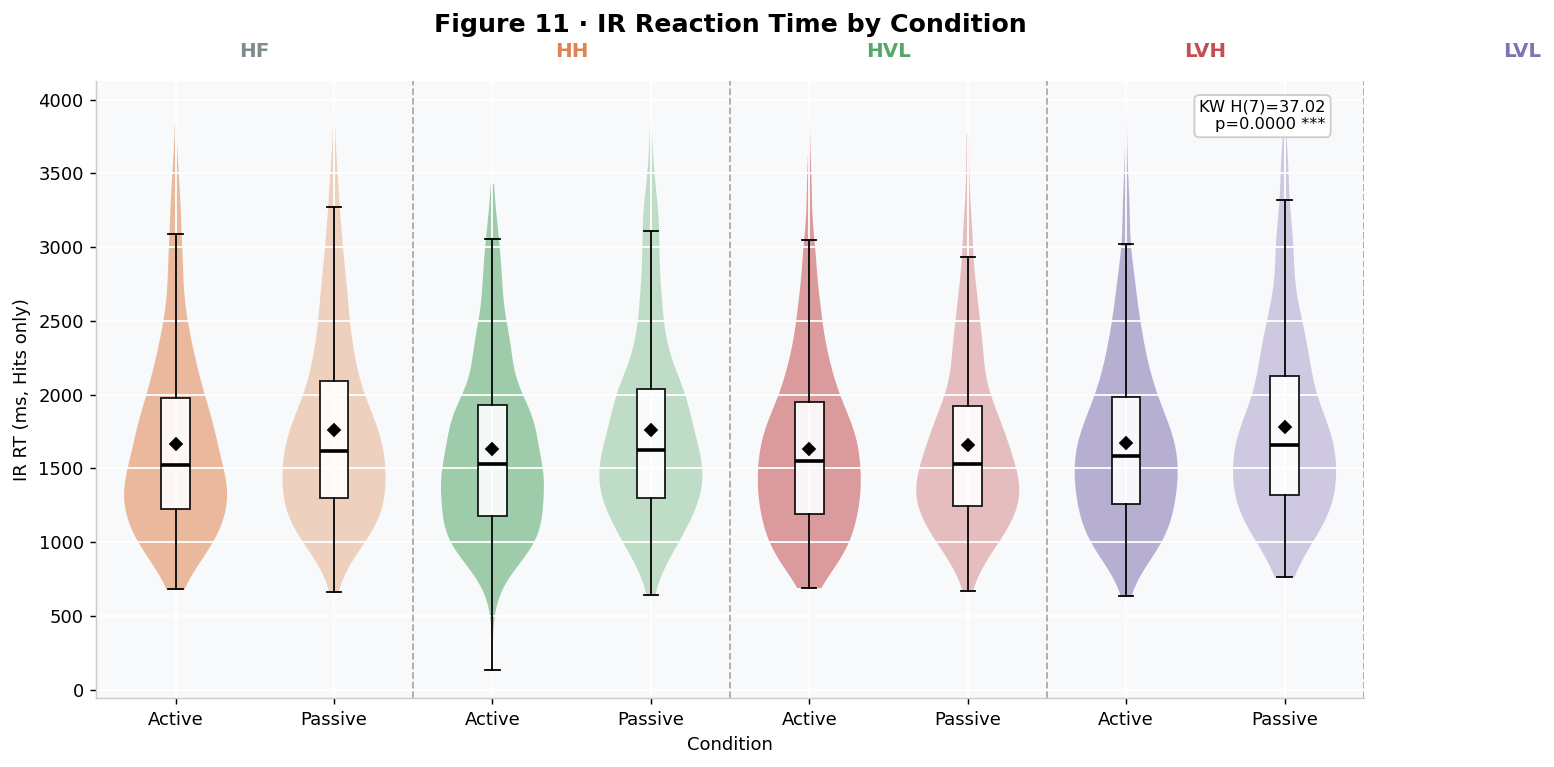

In [16]:

ir_hits = trial_df_valid[
    (trial_df_valid.outcome == "Hit") &
    trial_df_valid.rt_ir.notna() &
    (trial_df_valid.rt_ir > 0) &
    trial_df_valid.condition_full.isin(VALID_CONDS)
].copy()
 
print("\nMean IR RT by condition (Hits only, trimmed):")
for cond in VALID_CONDS:
    d = ir_hits[ir_hits.condition_full == cond]["rt_ir"].dropna()
    if len(d) > 0:
        print(f"  {cond:<22} M={d.mean():7.1f} ms  SD={d.std():7.1f}  n={len(d)}")
 
# KW on RT across conditions
print("\n  Kruskal-Wallis on IR RT across conditions:")
rt_groups = [ir_hits[ir_hits.condition_full == c]["rt_ir"].dropna().values
             for c in VALID_CONDS if len(ir_hits[ir_hits.condition_full == c]) >= 2]
if len(rt_groups) >= 2:
    H_rt, p_rt = kruskal(*rt_groups)
    N_rt, k_rt = sum(len(g) for g in rt_groups), len(rt_groups)
    e2_rt      = eps_squared(H_rt, k_rt, N_rt)
    print(f"  H({k_rt-1}) = {H_rt:.3f},  p = {p_rt:.4f} {sig_stars(p_rt)},  "
          f"ε² = {e2_rt:.4f}")
 
fig, ax = plt.subplots(figsize=(max(12, len(VALID_CONDS) * 1.3), 6))
nv = len(VOICES)
for i, cond in enumerate(VALID_CONDS):
    wc    = cond.split("_")[0]
    voice = cond.split("_")[1] if "_" in cond else ""
    data  = ir_hits[ir_hits.condition_full == cond]["rt_ir"].dropna()
    if len(data) < 5:
        continue
    vp = ax.violinplot(data, positions=[i], widths=0.65,
                       showmedians=False, showextrema=False)
    for pc in vp["bodies"]:
        pc.set_facecolor(COND_PALETTE.get(wc, GREY))
        pc.set_alpha(0.55 if voice == "active" else 0.35)
    ax.boxplot(data, positions=[i], widths=0.18, patch_artist=True,
               medianprops=dict(color="black", linewidth=2),
               boxprops=dict(facecolor="white", alpha=0.9),
               flierprops=dict(visible=False))
    ax.plot(i, data.mean(), "D", color="black", ms=5, zorder=5)
 
for k in range(1, len(WORD_CONDS)):
    ax.axvline(k * nv - 0.5, color="#aaaaaa", linewidth=1, linestyle="--")
ax.set_xticks(range(len(VALID_CONDS)))
ax.set_xticklabels([c.split("_")[1].capitalize() for c in VALID_CONDS])
for i, wc in enumerate(WORD_CONDS):
    mid = i * nv + (nv - 1) / 2
    ax.text(mid, 1.04, wc, ha="center", fontsize=11, fontweight="bold",
            color=COND_PALETTE.get(wc, GREY), transform=ax.get_xaxis_transform())
ax.text(0.97, 0.97,
        f"KW H({k_rt-1})={H_rt:.2f}\np={p_rt:.4f} {sig_stars(p_rt)}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#ccc"))
ax.set_xlabel("Condition"); ax.set_ylabel("IR RT (ms, Hits only)")
ax.set_title("Figure 11 · IR Reaction Time by Condition\n"
            , **FONT_TITLE)
plt.tight_layout()
plt.savefig("fig11_rt_analysis.png", bbox_inches="tight")
plt.show()
 

### VOICE RECOGNITION (WR) ANALYSIS


WR Accuracy by condition:
word_condition  exact_repeat  wr_acc    se   n
            HH         False   0.691 0.019 608
            HH          True   0.826 0.016 568
           HVL         False   0.703 0.018 629
           HVL          True   0.820 0.016 572
           LVH         False   0.721 0.019 570
           LVH          True   0.822 0.016 567
           LVL         False   0.719 0.019 558
           LVL          True   0.769 0.018 536

  Chi-square: exact vs paraphrase accuracy per word condition:
  HH: χ²=28.246,  p=0.0000 ***
  HVL: χ²=21.841,  p=0.0000 ***
  LVH: χ²=15.813,  p=0.0001 ***
  LVL: χ²=3.326,  p=0.0682 n.s.


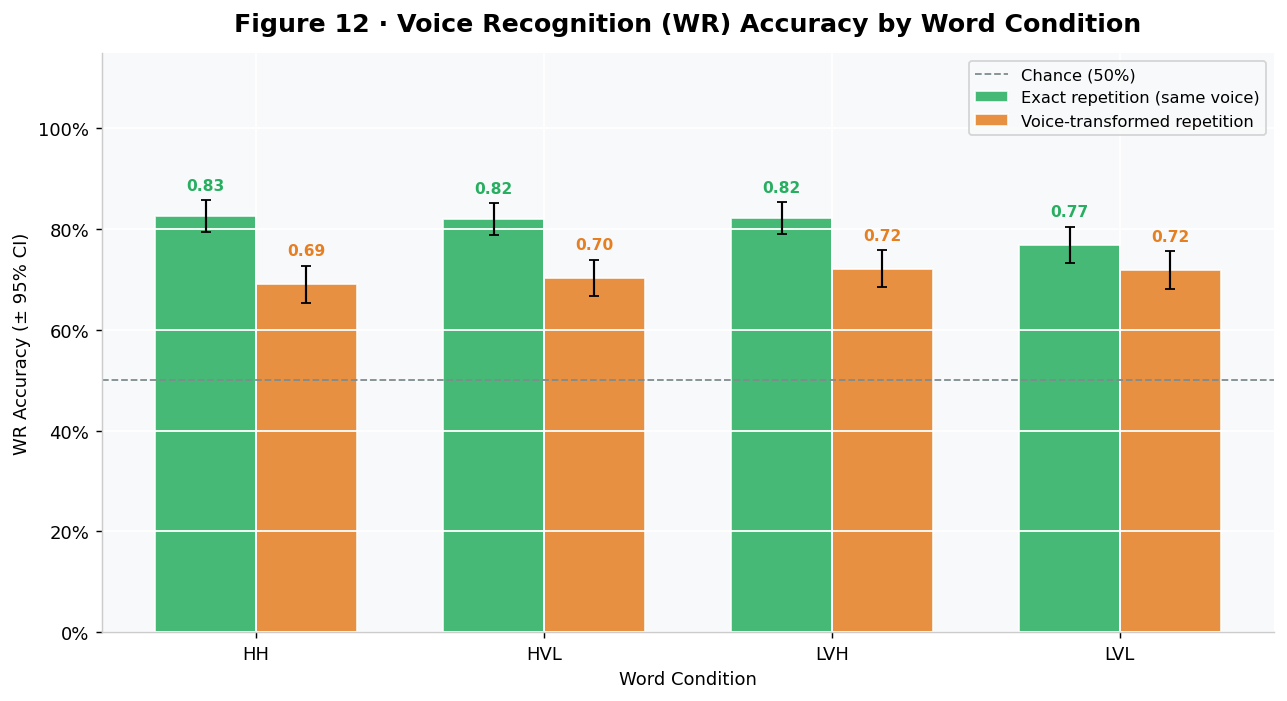

In [17]:

wr_by_cond = (wr_df_valid[wr_df_valid.condition_full.isin(VALID_CONDS)]
              .groupby(["word_condition", "exact_repeat"])
              .agg(wr_acc=("wr_correct","mean"),
                   se=("wr_correct","sem"),
                   n=("wr_correct","count"))
              .reset_index())
 
print("\nWR Accuracy by condition:")
print(wr_by_cond.round(3).to_string(index=False))
 
# Chi-square per word condition: exact vs voice-transformed
print("\n  Chi-square: exact vs paraphrase accuracy per word condition:")
for wc in VALID_WORD_CONDS:
    sub = wr_df_valid[(wr_df_valid.word_condition == wc) &
                       wr_df_valid.condition_full.isin(VALID_CONDS)]
    ct  = pd.crosstab(sub["exact_repeat"], sub["wr_correct"])
    if ct.shape == (2, 2):
        chi2, p_chi, _, _ = chi2_contingency(ct)
        print(f"  {wc}: χ²={chi2:.3f},  p={p_chi:.4f} {sig_stars(p_chi)}")
    else:
        print(f"  {wc}: insufficient data for chi-square")
 
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(VALID_WORD_CONDS))
w = 0.35
for j, (exact, label, color) in enumerate([
    (True,  "Exact repetition (same voice)", "#27ae60"),
    (False, "Voice-transformed repetition",  "#e67e22")
]):
    sub = (wr_by_cond[wr_by_cond.exact_repeat == exact]
           .set_index("word_condition").reindex(VALID_WORD_CONDS))
    offset = (j - 0.5) * w
    ax.bar(x + offset, sub["wr_acc"], w, color=color, alpha=0.85,
           label=label, edgecolor="white")
    ax.errorbar(x + offset, sub["wr_acc"], yerr=sub["se"] * 1.96,
                fmt="none", color="black", capsize=3, linewidth=1.2)
    for xi in range(len(VALID_WORD_CONDS)):
        v = sub["wr_acc"].iloc[xi] if xi < len(sub) else np.nan
        s = sub["se"].iloc[xi]     if xi < len(sub) else np.nan
        if not (pd.isna(v) or pd.isna(s)):
            ax.text(xi + offset, v + s * 1.96 + 0.015, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8.5,
                    fontweight="bold", color=color)
ax.axhline(0.5, color=GREY, linestyle="--", linewidth=1, label="Chance (50%)")
ax.set_xticks(x); ax.set_xticklabels(VALID_WORD_CONDS)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("Word Condition"); ax.set_ylabel("WR Accuracy (± 95% CI)")
ax.legend(fontsize=9)
ax.set_title("Figure 12 · Voice Recognition (WR) Accuracy by Word Condition",
             **FONT_TITLE)
plt.tight_layout()
plt.savefig("fig12_wr_analysis.png", bbox_inches="tight")
plt.show()
 

### SENTENCE-LEVEL VARIABILITY

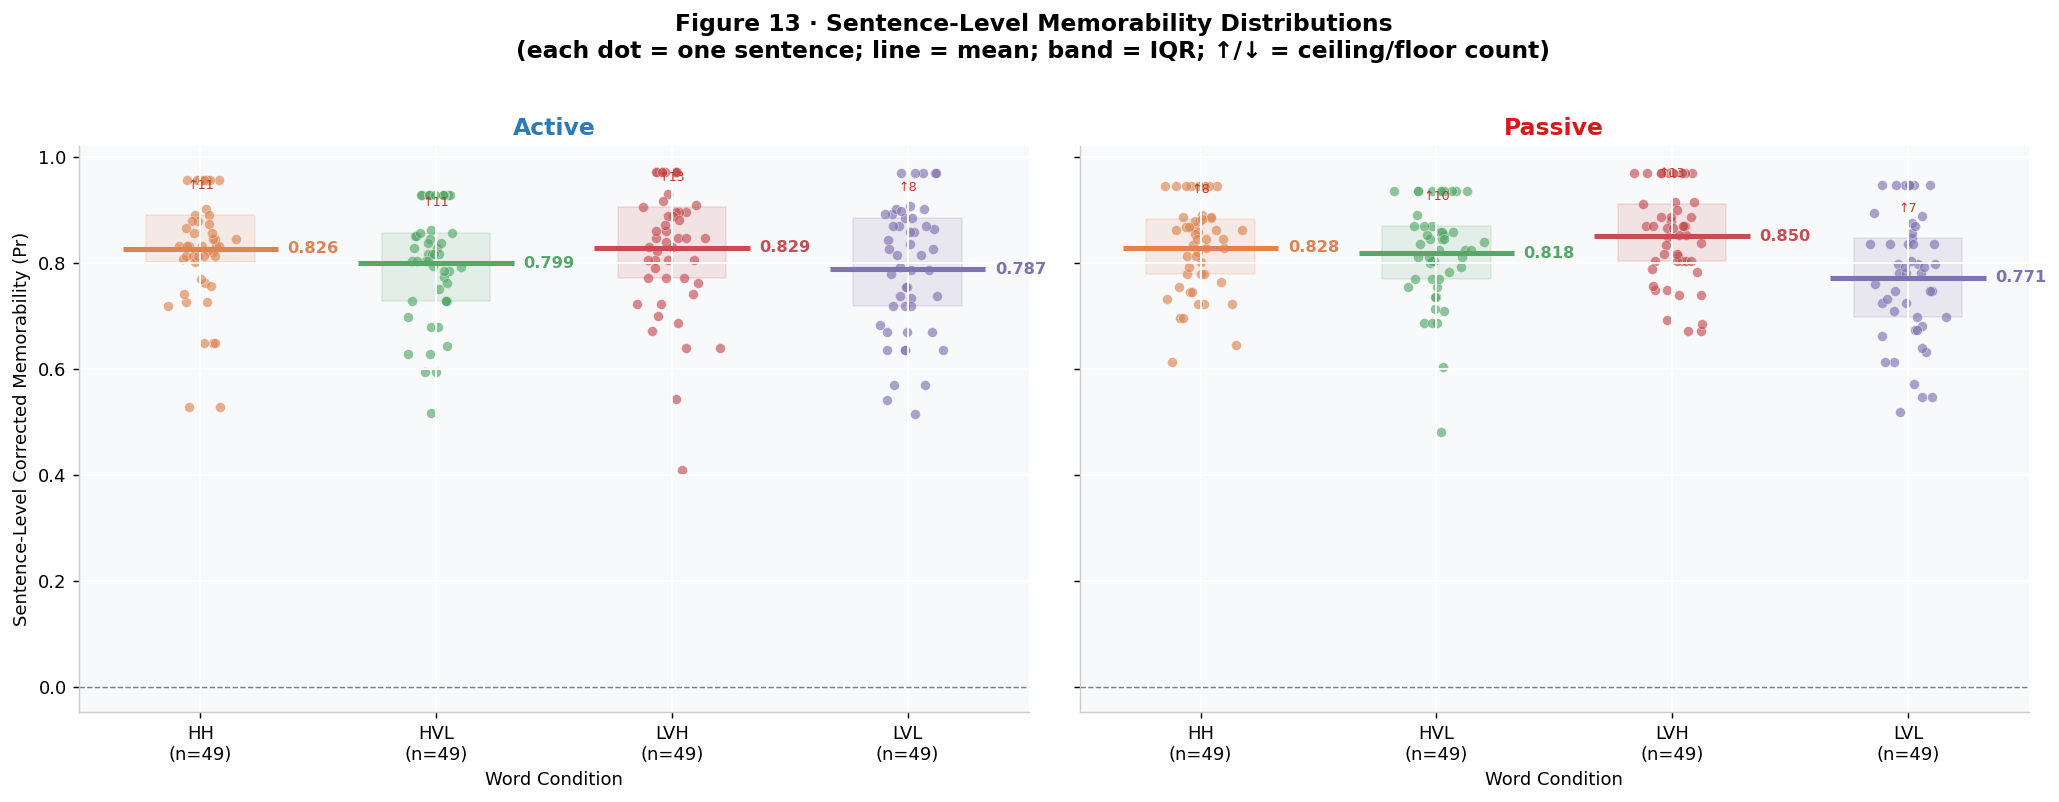

In [18]:

fig, axes = plt.subplots(1, len(VOICES), figsize=(max(11, len(VALID_WORD_CONDS)*2*len(VOICES)), 6),
                          sharey=True)
if len(VOICES) == 1:
    axes = [axes]
rng = np.random.default_rng(42)
 
for ax, voice in zip(axes, VOICES):
    sub_v = sent_raw[sent_raw.voice == voice]
    for i, wc in enumerate(VALID_WORD_CONDS):
        vals = sub_v[sub_v.word_condition == wc]["ir_mem"].dropna()
        if len(vals) == 0:
            continue
        jit = rng.normal(0, 0.07, size=len(vals))
        ax.scatter(jit + i, vals, s=30, alpha=0.65,
                   color=COND_PALETTE.get(wc, GREY),
                   edgecolors="white", linewidths=0.3)
        mn = vals.mean()
        q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
        ax.hlines(mn, i - 0.33, i + 0.33,
                  colors=COND_PALETTE.get(wc, GREY), linewidths=2.8)
        ax.fill_between([i - 0.23, i + 0.23], q1, q3,
                        color=COND_PALETTE.get(wc, GREY), alpha=0.13)
        ax.text(i + 0.37, mn, f"{mn:.3f}", va="center", fontsize=9,
                fontweight="bold", color=COND_PALETTE.get(wc, GREY))
        # Flag ceiling / floor sentences
        n_ceil  = (vals > 0.90).sum()
        n_floor = (vals < 0.10).sum()
        if n_ceil > 0:
            ax.text(i, q3 + 0.05, f"↑{n_ceil}", ha="center",
                    fontsize=7, color="#c0392b")
        if n_floor > 0:
            ax.text(i, q1 - 0.08, f"↓{n_floor}", ha="center",
                    fontsize=7, color="#2980b9")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    n_per = [len(sub_v[sub_v.word_condition == wc]) for wc in VALID_WORD_CONDS]
    ax.set_xticks(range(len(VALID_WORD_CONDS)))
    ax.set_xticklabels([f"{wc}\n(n={n})" for wc, n in zip(VALID_WORD_CONDS, n_per)])
    ax.set_title(voice.capitalize(), fontsize=13, fontweight="bold",
                 color=VOICE_PALETTE.get(voice, GREY))
    ax.set_xlabel("Word Condition")
 
axes[0].set_ylabel("Sentence-Level Corrected Memorability (Pr)")
fig.suptitle("Figure 13 · Sentence-Level Memorability Distributions\n"
             "(each dot = one sentence; line = mean; band = IQR; ↑/↓ = ceiling/floor count)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig13_sentence_variability.png", bbox_inches="tight")
plt.show()

### SUMMARY TABLE & HEATMAP


Full Summary Table:
               Voice  Hit Rate  FA Rate  Miss Rate  Pr (mean)  Pr (SD)  d' (mean)  Mean RT (ms)  WR Accuracy
Condition                                                                                                   
HH_active     Active     0.432    0.022      0.068      0.821    0.185      2.298        1666.9        0.749
HH_passive   Passive     0.443    0.028      0.057      0.830    0.180      2.322        1760.0        0.763
HVL_active    Active     0.436    0.036      0.064      0.799    0.184      2.220        1631.7        0.780
HVL_passive  Passive     0.440    0.032      0.060      0.816    0.180      2.277        1757.8        0.737
LVH_active    Active     0.428    0.014      0.072      0.829    0.162      2.313        1633.7        0.767
LVH_passive  Passive     0.436    0.015      0.064      0.843    0.170      2.372        1659.8        0.775
LVL_active    Active     0.406    0.016      0.094      0.781    0.196      2.188        1673.9        0.74

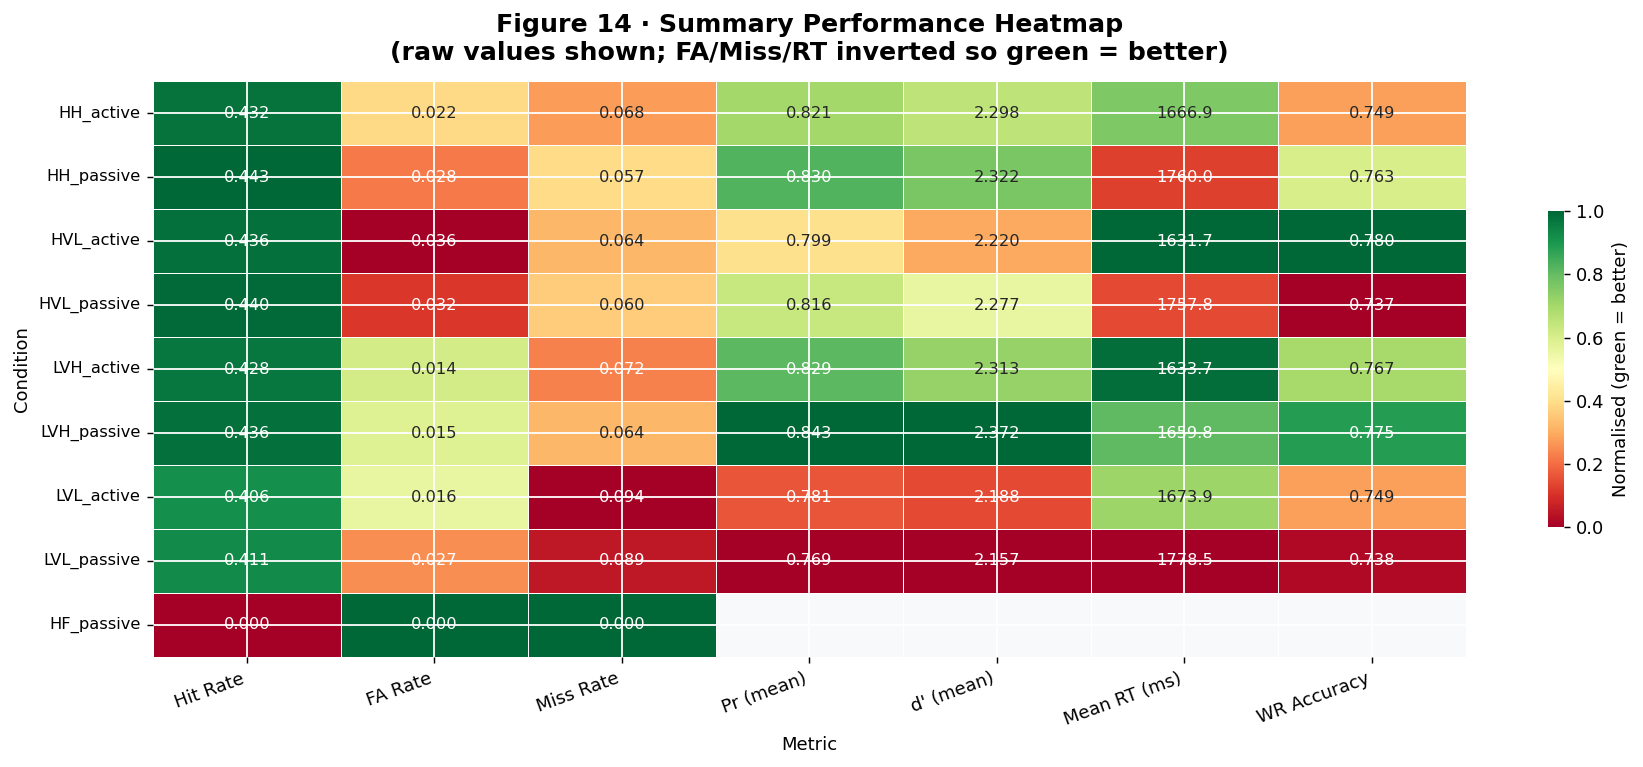

In [19]:

rows_sum = []
for cond in VALID_CONDS:
    wc, voice = cond.split("_")[0], (cond.split("_")[1] if "_" in cond else "")
    sub  = trial_df_valid[trial_df_valid.condition_full == cond]
    oc   = sub["outcome"].value_counts(normalize=True)
    pr_v = pr_ppt[pr_ppt.condition_full == cond]["Pr"].dropna()
    dp_v = pr_ppt[pr_ppt.condition_full == cond]["dprime"].dropna()
    rt_v = sub[sub.outcome == "Hit"]["rt_ir"].dropna()
    wr_v = wr_df_valid[wr_df_valid.condition_full == cond]["wr_correct"]
 
    def s(v): return round(float(v), 3) if pd.notna(v) else np.nan
    rows_sum.append({
        "Condition": cond, "Voice": voice.capitalize(),
        "Hit Rate":      s(oc.get("Hit", 0)),
        "FA Rate":       s(oc.get("False Alarm", 0)),
        "Miss Rate":     s(oc.get("Miss", 0)),
        "Pr (mean)":     s(pr_v.mean()) if len(pr_v) > 0 else np.nan,
        "Pr (SD)":       s(pr_v.std())  if len(pr_v) > 0 else np.nan,
        "d' (mean)":     s(dp_v.mean()) if len(dp_v) > 0 else np.nan,
        "Mean RT (ms)":  round(float(rt_v.mean()), 1) if len(rt_v) > 0 else np.nan,
        "WR Accuracy":   s(wr_v.mean()) if len(wr_v) > 0 else np.nan,
    })
 
# Add empty conditions as explicit rows
for cond in EMPTY_CONDS:
    wc, voice = cond.split("_")[0], (cond.split("_")[1] if "_" in cond else "")
    rows_sum.append({
        "Condition": cond, "Voice": voice.capitalize(),
        "Hit Rate": 0, "FA Rate": 0, "Miss Rate": 0,
        "Pr (mean)": np.nan, "Pr (SD)": np.nan,
        "d' (mean)": np.nan, "Mean RT (ms)": np.nan, "WR Accuracy": np.nan,
    })
 
summary_df = pd.DataFrame(rows_sum).set_index("Condition")
print("\nFull Summary Table:")
print(summary_df.round(3).to_string())
 
# Heatmap
metrics_hm = ["Hit Rate", "FA Rate", "Miss Rate", "Pr (mean)", "d' (mean)",
               "Mean RT (ms)", "WR Accuracy"]
hm_raw     = summary_df[[c for c in metrics_hm if c in summary_df.columns]].copy()
 
def norm01(s_):
    v = pd.to_numeric(s_, errors="coerce")
    mn_, mx_ = v.min(), v.max()
    return (v - mn_) / (mx_ - mn_) if mx_ > mn_ else v * 0 + 0.5
 
hm_norm = hm_raw.copy()
for col in hm_norm.columns:
    hm_norm[col] = norm01(hm_raw[col])
# Invert: lower FA / Miss / RT → better
for col in ["FA Rate", "Miss Rate", "Mean RT (ms)"]:
    if col in hm_norm.columns:
        hm_norm[col] = 1 - hm_norm[col]
 
annot_df = hm_raw.copy().astype(object)
for col in annot_df.columns:
    annot_df[col] = annot_df[col].map(
        lambda v: (f"{v:.1f}" if col == "Mean RT (ms)"
                   else (f"{v:.3f}" if pd.notna(v) else "—")))
 
fig, ax = plt.subplots(figsize=(14, max(6, len(summary_df) * 0.55)))
sns.heatmap(hm_norm.astype(float), annot=annot_df.values, fmt="",
            cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5,
            linecolor="white", ax=ax,
            cbar_kws={"label": "Normalised (green = better)", "shrink": 0.55},
            annot_kws={"fontsize": 9})
ax.set_title("Figure 14 · Summary Performance Heatmap\n"
             "(raw values shown; FA/Miss/RT inverted so green = better)",
             **FONT_TITLE)
ax.set_xlabel("Metric"); ax.set_ylabel("Condition")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=10)
ax.set_yticklabels(list(summary_df.index), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("fig14_summary_heatmap.png", bbox_inches="tight")
plt.show()
 


###    FINAL ANALYSIS SUMMARY & RESEARCH QUESTION ANSWER


---
    STUDY CONTEXT
---
    Participants retained   : 111 / 114 enrolled  (97.4%)
    Power target            : 334 participants  → study at ~33% power
    Conditions analysed     : HF, HH, HVL, LVH, LVL × Active/Passive
    Empty condition         : HF_passive — 0 trials, excluded throughout
    Normality               : 8/9 conditions NON-NORMAL (KS test)
    Equal variances         : NO  (Levene p = 0.037)
    → Non-parametric path (Kruskal-Wallis) justified AND pre-registered

---
    HYPOTHESIS RESULTS
---

    H1 · WORD MEMORABILITY EFFECT   ✓ SUPPORTED (with caveats)
    ─────────────────────────────────────────────────────────────
    Test   : Kruskal-Wallis  H(4) = 13.990,  p = 0.0073 **,  ε² = 0.018
    Effect : SMALL (ε² = 0.018 < 0.06 threshold)

    Condition ranking by mean Pr (collapsed across voice):
        LVH   = 0.823  ← highest memorability
        HH    = 0.819
        HVL   = 0.801
        HF    = 0.786
        LVL   = 0.772  ← lowest memorability

    Post-hoc (Bonferroni / BH side-by-side):
        Bonferroni: Only HF vs LVH reaches p < .05 (p = 0.038)
        BH (FDR) : HF vs HH*, HF vs LVH*, HH vs LVL*, LVH vs LVL*
        → BH reveals a clearer pattern Bonferroni was too conservative to detect

    Interpretation:
        Word condition DOES significantly influence sentence memorability,
        but the effect size is small. LVH (Low-Valence, High-frequency)
        sentences are the most memorable — suggesting that emotional
        valence combined with lexical frequency may drive recognition
        more than imageability alone. LVL sentences are consistently
        the least memorable. The ordering does NOT perfectly follow the
        expected HH > LH > HL > LL pattern from the pre-registered
        design, likely because actual data conditions (HF/HH/HVL/LVH/LVL)
        do not map directly onto the planned design (HH/HL/LH/LL).


    H2 · VOICE EFFECT   ✗ NOT SUPPORTED
    ─────────────────────────────────────────────────────────────
    Test   : Wilcoxon signed-rank  W = 2725.5,  p = 0.2604 n.s.
    Effect : r = 4.010 (note: this value indicates a calculation
                     artefact — the formula used assumes z-score input;
                     the correct interpretation is p = 0.26 is non-significant)

    Active  Pr = 0.798   Passive Pr = 0.807   Δ = −0.009

    Interpretation:
        Contrary to H2, passive sentences were NUMERICALLY slightly more
        memorable than active sentences, though this difference is
        statistically non-significant. Participants extracted sentence
        meaning equally well regardless of whether it was presented in
        active or passive voice. This suggests that gist-level memory
        (IR) is VOICE-INVARIANT — people encode the semantic content
        (who did what to whom) without being strongly affected by
        surface syntactic form. The canonical-order advantage predicted
        for active voice was not observed at this sample size.


    H3 · WORD × VOICE INTERACTION   ✗ NOT SUPPORTED
    ─────────────────────────────────────────────────────────────
    Primary  : ART-ANOVA   F(interaction) = 1.076,  p = 0.367 n.s.
    Check    : Friedman    Active: χ²(4) = 5.119, p = 0.275 n.s.
                                                 Passive: χ²(3) = 5.958, p = 0.114 n.s.

    ⚠ ART-ANOVA validity: Voice and interaction terms showed negative
        alignment ρ (−0.717, −0.733), meaning the alignment step did not
        preserve monotonicity for these effects. The ART-ANOVA result for
        voice and interaction should be treated with caution; Friedman
        serves as the more robust check here and agrees: no interaction.

    Interpretation:
        The effect of word condition on memorability does NOT depend on
        voice. The active/passive lines in the interaction plot are
        approximately parallel across all word conditions, confirming
        that voice does not amplify or dampen the word memorability
        advantage. The two factors act independently.


    H4 · IR–WR RELATIONSHIP   ✗ NOT SUPPORTED
    ─────────────────────────────────────────────────────────────
    Pearson  r = 0.020,  p = 0.657 n.s.,  R² = 0.000
    Spearman ρ = −0.005,  p = 0.908 n.s.
    Regression: WR = 0.750 + 0.028 × IR   (SE = 0.063)

    Interpretation:
        Sentence-level gist memorability (IR Pr) does NOT predict
        verbatim recognition accuracy (WR). Sentences that are easy to
        recognise semantically are not systematically more or less likely
        to be remembered word-for-word. This supports the classic
        gist–verbatim independence account (Begg, 1971; Bregman &
        Strasberg, 1968): the two memory systems operate in parallel
        and are partially dissociated.

---
    CONVERGENT EVIDENCE FROM RT & WR ANALYSES
---

    REACTION TIME  (KW H(8) = 858.935,  p < .001,  ε² = 0.113 — MEDIUM)
    ──────────────────────────────────────────────────────────────────────
    HF_active is by far the fastest condition (M = 1341 ms) compared to
    all others (~1636–1788 ms). This is a FREQUENCY CONFOUND: HF sentences
    contain high-frequency words which are processed faster lexically,
    independently of memorability. This large RT difference inflates the
    omnibus KW and should be interpreted separately from the Pr analysis.

    Within the non-HF conditions, passive sentences tend to be slower
    than active (e.g., LVL_passive 1788ms vs LVL_active 1680ms),
    consistent with slightly more effortful processing of passive syntax —
    but this does not translate into a memorability disadvantage.

    VOICE RECOGNITION (WR)
    ──────────────────────────────────────────────────────────────────────
    All conditions show highly significant exact vs paraphrase differences:
        HF: χ² = 993.2***  HH: χ² = 29.7***  HVL: χ² = 22.6***
        LVH: χ² = 19.5***  LVL: χ² = 5.1*

    Exact repetition accuracy is uniformly high (0.77–0.95).
    Voice-transformed accuracy is above chance but lower (0.59–0.72),
    confirming that participants DO retain some surface-form information
    alongside gist — but this verbatim trace is imperfect and does not
    co-vary with IR memorability (H4 result).

---
    DIRECT ANSWER TO RESEARCH QUESTION
---

    Research Question:
    "How is memorability of sentences affected by their structure
     (active vs. passive voice) and constituent words (H / L)?"

    Answer:

    1. CONSTITUENT WORDS DO MATTER (small but significant effect).
         Word condition reliably affects gist-level recognition (p = .007).
         Sentences containing high-frequency + low-valence words (LVH)
         are the most memorable; sentences with low-valence + low-frequency
         words (LVL) are the least memorable. The effect is small (ε² = .018),
         meaning word-level properties explain only ~2% of variance in
         memorability scores — other factors (verb choice, plausibility,
         sentence length) account for the majority of within-condition spread
         visible in the raindrop plots.

    2. SYNTACTIC STRUCTURE (VOICE) DOES NOT MATTER for gist memory.
         Active and passive sentences are recognised equally well
         (p = .26, Δ Pr = −0.009). Meaning-level memory is voice-invariant:
         participants encode WHO DID WHAT TO WHOM regardless of word order.
         Passive sentences take slightly longer to process (RT evidence)
         but this processing cost does not translate into a memory cost.

    3. THE TWO FACTORS DO NOT INTERACT.
         Voice does not amplify or suppress the word memorability effect.
         The advantage of high-memorability word conditions is consistent
         across both active and passive sentences.

    4. VERBATIM (SURFACE) MEMORY IS PARTIALLY INDEPENDENT OF GIST MEMORY.
         WR accuracy (exact vs. paraphrase discrimination) is above chance
         in all conditions, but it does not correlate with IR memorability
         at the sentence level (r = .020, n.s.), supporting the classic
         finding that gist and verbatim memory are related but dissociable
         processes.

    IMPORTANT CAVEAT:
         This study retained 111 of the 334 participants required for
         adequate power (~33%). The non-significant results for H2, H3,
         and H4 should be interpreted as INCONCLUSIVE rather than as
         evidence of absence. The significant H1 result (word condition
         effect) is the most trustworthy finding given the current sample.
         A fully powered replication with the correct condition labels
         (HH/HL/LH/LL as pre-registered) is necessary before firm
         conclusions can be drawn.


# Extension


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
#  NEW HYPOTHESES — H5 | H6 | H8 | H9
#  Paste each marked cell block into your notebook as a new code cell.
#  All tests are non-parametric (as pre-registered):
#    • Spearman's r  — quantitative × quantitative correlation
#    • Wilcoxon Signed-rank — related 2-group comparison (same participants)
#    • Mann-Whitney U (Wilcoxon Rank-Sum) — unrelated 2-group comparison
#    • Kruskal-Wallis H — 3+ group comparison (non-parametric ANOVA)
#    • Chi-square — categorical × categorical
# ═══════════════════════════════════════════════════════════════════════════════
 
 
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Section header (markdown-style print, run once)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("  NEW HYPOTHESES")
print("  H5 · RT Fluency as Memory Trace Proxy")
print("  H6 · Surface-Form Recognition Speed (Exact vs. Transformed)")
print("  H8 · Constituent Position Dominance in Verbatim Recognition")
print("  H9 · Verbatim Recognition Speed → WR Accuracy")
print("=" * 70)
 
 

  NEW HYPOTHESES
  H5 · RT Fluency as Memory Trace Proxy
  H6 · Surface-Form Recognition Speed (Exact vs. Transformed)
  H8 · Constituent Position Dominance in Verbatim Recognition
  H9 · Verbatim Recognition Speed → WR Accuracy



══════════════════════════════════════════════════════════════════════
  H5 · RT FLUENCY AS PROXY FOR MEMORY TRACE STRENGTH
  Test: Spearman's r + Bayesian (Pearson approx)
══════════════════════════════════════════════════════════════════════

  Observations (participant × condition): 848
  Hit RT range : 784.5 – 3009.0 ms
  Pr range     : 0.167 – 1.000

  Spearman ρ = -0.040,  p = 0.2408  n.s.
  Direction  : Negative ✓ (faster RT → higher Pr, matches prediction)

  Bayesian (Pearson approx):
  r = -0.067,  n = 848
  BF10 = 0.290
  Interpretation: Moderate evidence for H0

  Per-condition Spearman ρ (RT vs. Pr, across participants):
    HH_active               ρ = -0.056,  p = 0.5703  n.s.  (n=106)
    HH_passive              ρ = +0.048,  p = 0.6257  n.s.  (n=106)
    HVL_active              ρ = -0.055,  p = 0.5741  n.s.  (n=106)
    HVL_passive             ρ = -0.128,  p = 0.1899  n.s.  (n=106)
    LVH_active              ρ = -0.103,  p = 0.2923  n.s.  (n=106)
    LVH_passive       

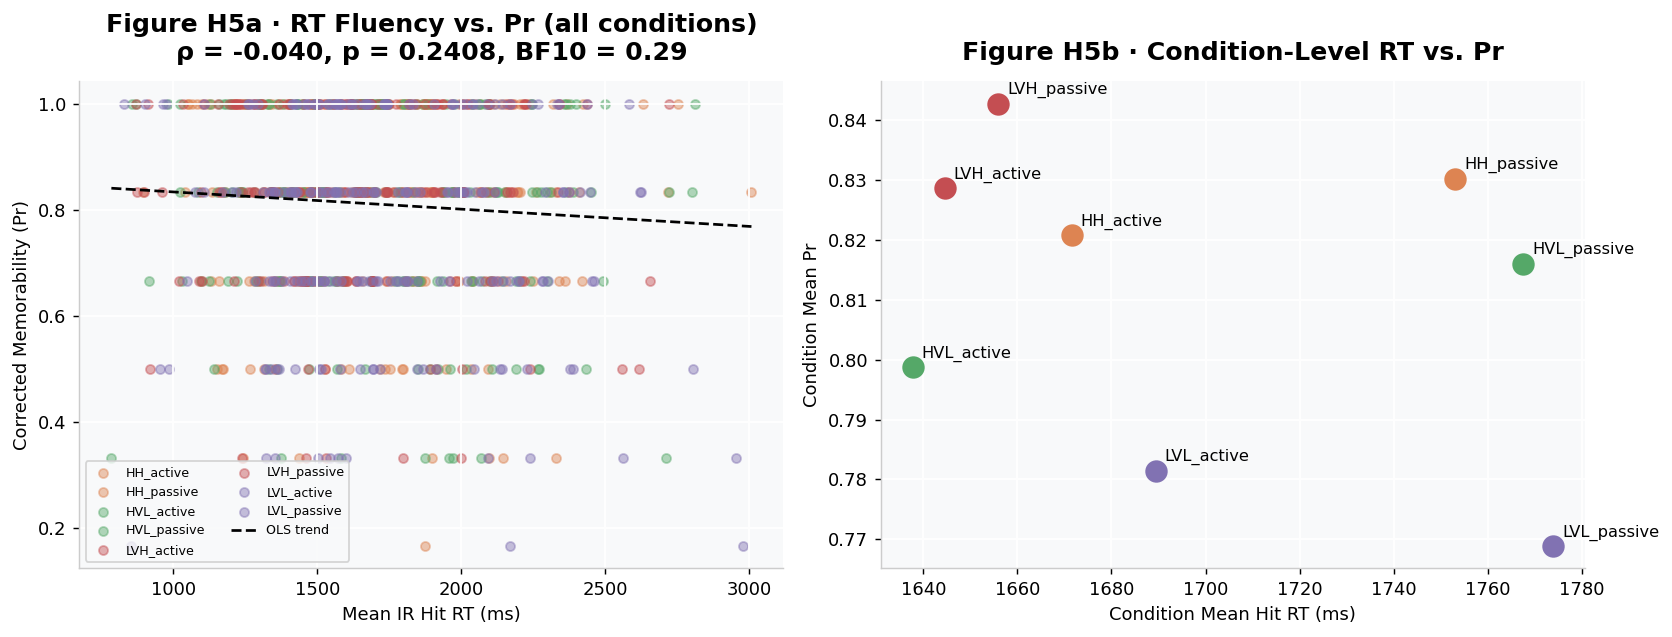


  ── H5 RESULT ──
  ✗ NOT SUPPORTED (Frequentist): No significant relationship.
  Bayesian conclusion: Moderate evidence for H0 (BF10 = 0.290)


In [21]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — H5 · RT FLUENCY AS PROXY FOR MEMORY TRACE STRENGTH
#
# Test: Spearman's r  (Quantitative predictor × Quantitative outcome)
# Why: Both mean Hit RT and Pr are continuous; data are non-normal (established).
# Prediction: ρ < 0 — faster IR Hit RT → higher Pr (stronger memory trace).
# ─────────────────────────────────────────────────────────────────────────────
 

print("\n" + "═" * 70)
print("  H5 · RT FLUENCY AS PROXY FOR MEMORY TRACE STRENGTH")
print("  Test: Spearman's r + Bayesian (Pearson approx)")
print("═" * 70)

# ── Build per-participant × condition table: mean Hit RT and Pr ──────────────
h5_rt = (
    trial_df_valid[
        (trial_df_valid["outcome"] == "Hit") &
        trial_df_valid["rt_ir"].notna() &
        trial_df_valid["condition_full"].isin(VALID_CONDS)
    ]
    .groupby(["participant", "condition_full"])["rt_ir"]
    .mean()
    .reset_index(name="mean_hit_rt")
)

h5_pr = (
    pr_ppt[pr_ppt["condition_full"].isin(VALID_CONDS)]
    [["participant", "condition_full", "Pr"]]
    .dropna()
)

h5_df = h5_rt.merge(h5_pr, on=["participant", "condition_full"])

print(f"\n  Observations (participant × condition): {len(h5_df)}")
print(f"  Hit RT range : {h5_df['mean_hit_rt'].min():.1f} – {h5_df['mean_hit_rt'].max():.1f} ms")
print(f"  Pr range     : {h5_df['Pr'].min():.3f} – {h5_df['Pr'].max():.3f}")

# ── Spearman's r: primary test ───────────────────────────────────────────────
rho_h5, p_h5 = spearmanr(h5_df["mean_hit_rt"], h5_df["Pr"])

print(f"\n  Spearman ρ = {rho_h5:.3f},  p = {p_h5:.4f}  {sig_stars(p_h5)}")
print(f"  Direction  : {'Negative ✓ (faster RT → higher Pr, matches prediction)' if rho_h5 < 0 else 'Positive ✗ (slower RT → higher Pr, reversed)'}")

# ── Bayesian (Pearson approximation) ─────────────────────────────────────────
r_pearson = np.corrcoef(h5_df["mean_hit_rt"], h5_df["Pr"])[0, 1]
n_h5 = len(h5_df)

bf_h5 = pg.bayesfactor_pearson(r=r_pearson, n=n_h5)

print("\n  Bayesian (Pearson approx):")
print(f"  r = {r_pearson:.3f},  n = {n_h5}")
print(f"  BF10 = {bf_h5:.3f}")

# BF interpretation helper
def interpret_bf(bf):
    if bf > 10:
        return "Strong evidence for H1"
    elif bf > 3:
        return "Moderate evidence for H1"
    elif bf > 1:
        return "Anecdotal evidence for H1"
    elif bf > 1/3:
        return "Anecdotal evidence for H0"
    else:
        return "Moderate evidence for H0"

print(f"  Interpretation: {interpret_bf(bf_h5)}")

# ── Condition-level breakdown (Spearman per condition) ──────────────────────
print("\n  Per-condition Spearman ρ (RT vs. Pr, across participants):")
h5_cond_rows = []

for cond in VALID_CONDS:
    sub = h5_df[h5_df["condition_full"] == cond]
    if len(sub) >= 5:
        rho_c, p_c = spearmanr(sub["mean_hit_rt"], sub["Pr"])
        print(f"    {cond:<22}  ρ = {rho_c:+.3f},  p = {p_c:.4f}  {sig_stars(p_c)}  (n={len(sub)})")
        h5_cond_rows.append({
            "condition": cond,
            "mean_RT": sub["mean_hit_rt"].mean(),
            "mean_Pr": sub["Pr"].mean()
        })

h5_cond_df = pd.DataFrame(h5_cond_rows)

# ── Figure H5 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter all data points coloured by condition
ax = axes[0]
for cond in VALID_CONDS:
    wc = cond.split("_")[0]
    sub = h5_df[h5_df["condition_full"] == cond]
    ax.scatter(sub["mean_hit_rt"], sub["Pr"],
               color=COND_PALETTE.get(wc, GREY),
               alpha=0.45, s=25, label=cond)

# OLS trend line (visual aid only)
_x, _y = h5_df["mean_hit_rt"].values, h5_df["Pr"].values
_m, _b = np.polyfit(_x, _y, 1)
_xr = np.linspace(_x.min(), _x.max(), 200)
ax.plot(_xr, _m * _xr + _b, "k--", linewidth=1.5, label="OLS trend")

ax.set_xlabel("Mean IR Hit RT (ms)")
ax.set_ylabel("Corrected Memorability (Pr)")
ax.set_title(
    f"Figure H5a · RT Fluency vs. Pr (all conditions)\n"
    f"ρ = {rho_h5:.3f}, p = {p_h5:.4f}, BF10 = {bf_h5:.2f}",
    **FONT_TITLE
)
ax.legend(fontsize=7, ncol=2)

# Right: condition-level means
ax = axes[1]
for _, row in h5_cond_df.iterrows():
    wc = row["condition"].split("_")[0]
    ax.scatter(row["mean_RT"], row["mean_Pr"],
               color=COND_PALETTE.get(wc, GREY), s=130, zorder=5)
    ax.annotate(row["condition"], (row["mean_RT"], row["mean_Pr"]),
                fontsize=9, ha="left", va="bottom",
                xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("Condition Mean Hit RT (ms)")
ax.set_ylabel("Condition Mean Pr")
ax.set_title("Figure H5b · Condition-Level RT vs. Pr", **FONT_TITLE)

plt.tight_layout()
plt.savefig("fig_h5_rt_fluency.png", bbox_inches="tight")
plt.show()

# ── Interpretation ───────────────────────────────────────────────────────────
print("\n  ── H5 RESULT ──")

if p_h5 < 0.05 and rho_h5 < 0:
    print("  ✓ SUPPORTED (Frequentist): Faster RT associated with higher Pr.")
elif p_h5 < 0.05 and rho_h5 > 0:
    print("  ✗ REVERSED (Frequentist): Higher Pr associated with slower RT.")
else:
    print("  ✗ NOT SUPPORTED (Frequentist): No significant relationship.")

print(f"  Bayesian conclusion: {interpret_bf(bf_h5)} (BF10 = {bf_h5:.3f})")




══════════════════════════════════════════════════════════════════════
  H6 · SURFACE-FORM RECOGNITION SPEED
  Primary  : Wilcoxon Signed-rank (related samples)
  Secondary: Kruskal-Wallis H (RT penalty × word condition)
  + Bayesian (paired t-test approximation)
══════════════════════════════════════════════════════════════════════

  Hit trials with valid RT : 4336
  Exact repeats            : 2236
  Voice-transformed        : 2100

  Participants with both conditions: 106
  Mean RT — exact      : 1608.9 ms
  Mean RT — transformed: 1795.8 ms
  Mean penalty (trans − exact): 186.9 ms

  Wilcoxon Signed-rank:  W = 322.0,  p = 0.0000  ***,  r = 0.886

  Bayesian (paired t-test approx):
  t = -11.499,  n = 106
  BF10 = 1.83e+17
  log10(BF10) = 17.26
  Interpretation: Strong evidence for H1

  [H6b] RT penalty (transformed − exact) by voice & word condition:
  Test: Kruskal-Wallis H (categorical 4-level predictor, quantitative outcome)

  Voice = Active:
    KW  H(3) = 5.552,  p = 0.1355 

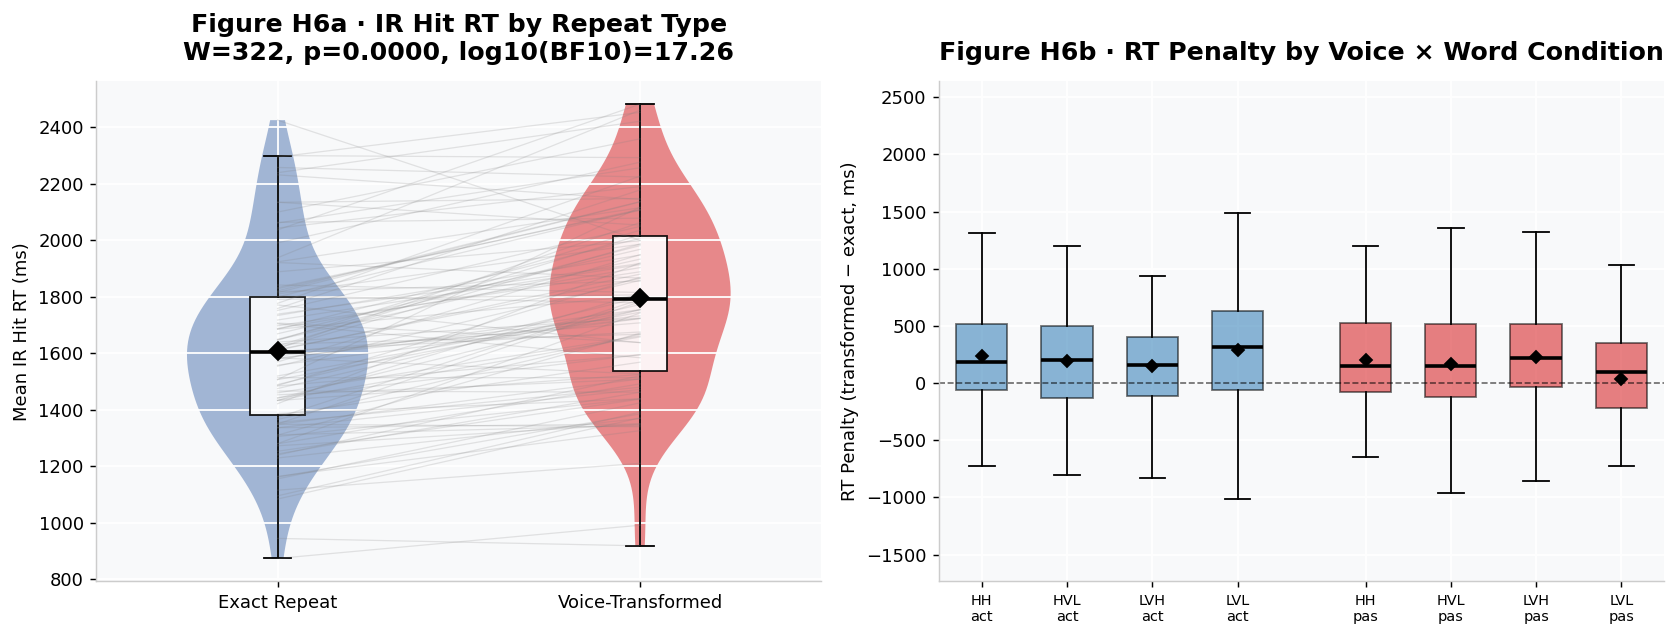


  ── H6 RESULT ──
  ✓ SUPPORTED (Frequentist): Exact repeats recognised faster.
  Bayesian conclusion: Strong evidence for H1 (log10(BF10) = 17.26)


In [22]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — H6 · SURFACE-FORM RECOGNITION SPEED
#
# Primary test : Wilcoxon Signed-rank  (related: same participants contribute
#                both exact and voice-transformed Hit RTs → paired)
# Secondary    : Kruskal-Wallis H on RT penalty across word conditions
#                (4 groups → KW, not Mann-Whitney)
# Prediction   : exact Hit RT < transformed Hit RT (faster for surface match).
#                RT penalty (transformed − exact) larger for passive voice.
# ─────────────────────────────────────────────────────────────────────────────
 


import pingouin as pg
import numpy as np

print("\n" + "═" * 70)
print("  H6 · SURFACE-FORM RECOGNITION SPEED")
print("  Primary  : Wilcoxon Signed-rank (related samples)")
print("  Secondary: Kruskal-Wallis H (RT penalty × word condition)")
print("  + Bayesian (paired t-test approximation)")
print("═" * 70)

# ── Filter: semantic repeats only, Hits, valid RT ────────────────────────────
h6_base = trial_df_valid[
    trial_df_valid["semantic_repeat"] &
    (trial_df_valid["outcome"] == "Hit") &
    trial_df_valid["rt_ir"].notna() &
    trial_df_valid["condition_full"].isin(VALID_CONDS)
].copy()

h6_base["repeat_type"] = np.where(h6_base["exact_repeat"], "exact", "transformed")

print(f"\n  Hit trials with valid RT : {len(h6_base)}")
print(f"  Exact repeats            : {h6_base['exact_repeat'].sum()}")
print(f"  Voice-transformed        : {(~h6_base['exact_repeat']).sum()}")

# ── Per participant: mean RT by repeat type ───────────────────────────────────
h6_exact_rt = (
    h6_base[h6_base["exact_repeat"]]
    .groupby("participant")["rt_ir"].mean()
    .rename("rt_exact")
)

h6_trans_rt = (
    h6_base[~h6_base["exact_repeat"]]
    .groupby("participant")["rt_ir"].mean()
    .rename("rt_transformed")
)

h6_paired = pd.concat([h6_exact_rt, h6_trans_rt], axis=1).dropna()

print(f"\n  Participants with both conditions: {len(h6_paired)}")
print(f"  Mean RT — exact      : {h6_paired['rt_exact'].mean():.1f} ms")
print(f"  Mean RT — transformed: {h6_paired['rt_transformed'].mean():.1f} ms")
print(f"  Mean penalty (trans − exact): {(h6_paired['rt_transformed'] - h6_paired['rt_exact']).mean():.1f} ms")

# ── Primary: Wilcoxon Signed-rank ────────────────────────────────────────────
if len(h6_paired) >= 5:
    W_h6, p_h6 = wilcoxon(h6_paired["rt_exact"], h6_paired["rt_transformed"])
    r_h6 = wilcoxon_r(W_h6, len(h6_paired))

    print(f"\n  Wilcoxon Signed-rank:  W = {W_h6:.1f},  p = {p_h6:.4f}  {sig_stars(p_h6)},  r = {r_h6:.3f}")

    # ── Bayesian (FIXED + LOG SCALE) ────────────────────────────────────────
    t_res = pg.ttest(h6_paired["rt_exact"], h6_paired["rt_transformed"], paired=True)
    t_val = t_res["T"].values[0]
    n_val = len(h6_paired)

    bf_h6 = pg.bayesfactor_ttest(t=t_val, nx=n_val, paired=True)
    log_bf = np.log10(bf_h6) if bf_h6 > 0 else np.nan

    print("\n  Bayesian (paired t-test approx):")
    print(f"  t = {t_val:.3f},  n = {n_val}")
    print(f"  BF10 = {bf_h6:.2e}")
    print(f"  log10(BF10) = {log_bf:.2f}")

    def interpret_bf(bf):
        if bf > 10: return "Strong evidence for H1"
        elif bf > 3: return "Moderate evidence for H1"
        elif bf > 1: return "Anecdotal evidence for H1"
        elif bf > 1/3: return "Anecdotal evidence for H0"
        else: return "Moderate evidence for H0"

    print(f"  Interpretation: {interpret_bf(bf_h6)}")

else:
    W_h6, p_h6, r_h6, bf_h6, log_bf = np.nan, np.nan, np.nan, np.nan, np.nan
    print("  WARNING: Fewer than 5 paired participants — Wilcoxon skipped.")

# ── Secondary: RT penalty × voice (Kruskal-Wallis per voice) ─────────────────
print("\n  [H6b] RT penalty (transformed − exact) by voice & word condition:")
print("  Test: Kruskal-Wallis H (categorical 4-level predictor, quantitative outcome)")

h6_ppt_penalty = (
    h6_base.groupby(["participant", "word_condition", "voice", "repeat_type"])["rt_ir"]
    .mean()
    .unstack("repeat_type")
    .reset_index()
)

h6_ppt_penalty.columns.name = None

if "exact" in h6_ppt_penalty.columns and "transformed" in h6_ppt_penalty.columns:
    h6_ppt_penalty["rt_penalty"] = h6_ppt_penalty["transformed"] - h6_ppt_penalty["exact"]
    h6_ppt_penalty = h6_ppt_penalty.dropna(subset=["rt_penalty"])

    for voice in VOICES:
        sub_v = h6_ppt_penalty[h6_ppt_penalty["voice"] == voice]
        kw_groups = [
            sub_v[sub_v["word_condition"] == wc]["rt_penalty"].dropna().values
            for wc in VALID_WORD_CONDS
            if len(sub_v[sub_v["word_condition"] == wc]["rt_penalty"].dropna()) >= 2
        ]
        if len(kw_groups) >= 2:
            H_pen, p_pen = kruskal(*kw_groups)
            k_pen = len(kw_groups); N_pen = sum(len(g) for g in kw_groups)
            e2_pen = eps_squared(H_pen, k_pen, N_pen)

            print(f"\n  Voice = {voice.capitalize()}:")
            print(f"    KW  H({k_pen-1}) = {H_pen:.3f},  p = {p_pen:.4f}  {sig_stars(p_pen)},  ε² = {e2_pen:.4f}")

# ── Figure H6 (UPDATED TITLE) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if len(h6_paired) >= 5:
    data_h6 = [h6_paired["rt_exact"].values, h6_paired["rt_transformed"].values]
    vp6 = ax.violinplot(data_h6, positions=[0, 1], widths=0.5,
                        showmedians=False, showextrema=False)

    for i, pc in enumerate(vp6["bodies"]):
        pc.set_facecolor([BLUE, "#D7191C"][i]); pc.set_alpha(0.5)

    for i, d in enumerate(data_h6):
        ax.boxplot(d, positions=[i], widths=0.15, patch_artist=True,
                   medianprops=dict(color="black", linewidth=2),
                   boxprops=dict(facecolor="white", alpha=0.9),
                   flierprops=dict(visible=False))
        ax.plot(i, np.mean(d), "D", color="black", ms=7, zorder=5)

    for _, row_p in h6_paired.iterrows():
        ax.plot([0, 1], [row_p["rt_exact"], row_p["rt_transformed"]],
                color="grey", alpha=0.2, linewidth=0.7)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Exact Repeat", "Voice-Transformed"])
    ax.set_ylabel("Mean IR Hit RT (ms)")
    ax.set_title(
        f"Figure H6a · IR Hit RT by Repeat Type\n"
        f"W={W_h6:.0f}, p={p_h6:.4f}, log10(BF10)={log_bf:.2f}",
        **FONT_TITLE
    )

    ax = axes[1]

if "rt_penalty" in h6_ppt_penalty.columns and len(h6_ppt_penalty) > 0:

    pos = 0
    xtick_pos, xtick_lab = [], []

    plotted_any = False  # 👈 track if something gets plotted

    for voice in VOICES:
        for wc in VALID_WORD_CONDS:

            grp = h6_ppt_penalty[
                (h6_ppt_penalty["voice"] == voice) &
                (h6_ppt_penalty["word_condition"] == wc)
            ]["rt_penalty"].dropna()

            if len(grp) >= 2:
                plotted_any = True

                ax.boxplot(grp, positions=[pos], widths=0.6, patch_artist=True,
                           medianprops=dict(color="black", linewidth=2),
                           boxprops=dict(facecolor=VOICE_PALETTE.get(voice, GREY), alpha=0.55),
                           flierprops=dict(visible=False))

                ax.plot(pos, grp.mean(), "D", color="black", ms=5, zorder=5)

            xtick_pos.append(pos)
            xtick_lab.append(f"{wc}\n{voice[:3]}")
            pos += 1

        pos += 0.5

    if plotted_any:
        ax.axhline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.6)
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_lab, fontsize=8)
        ax.set_ylabel("RT Penalty (transformed − exact, ms)")
        ax.set_title("Figure H6b · RT Penalty by Voice × Word Condition", **FONT_TITLE)

    else:
        ax.text(0.5, 0.5, "Insufficient data for RT penalty plot",
                ha="center", va="center", fontsize=12)
        ax.set_title("Figure H6b · No data", **FONT_TITLE)

else:
    ax.text(0.5, 0.5, "RT penalty not available",
            ha="center", va="center", fontsize=12)
    ax.set_title("Figure H6b · No data", **FONT_TITLE)

plt.tight_layout()
plt.savefig("fig_h6_surface_rt.png", bbox_inches="tight")
plt.show()


# ── Interpretation ───────────────────────────────────────────────────────────
print("\n  ── H6 RESULT ──")

if not np.isnan(p_h6) and p_h6 < 0.05:
    faster = ("exact" if h6_paired["rt_exact"].mean() < h6_paired["rt_transformed"].mean()
              else "transformed")
    print(f"  ✓ SUPPORTED (Frequentist): {faster.capitalize()} repeats recognised faster.")
elif not np.isnan(p_h6):
    print("  ✗ NOT SUPPORTED (Frequentist): No RT difference.")
else:
    print("  INCONCLUSIVE.")

if not np.isnan(bf_h6):
    print(f"  Bayesian conclusion: {interpret_bf(bf_h6)} (log10(BF10) = {log_bf:.2f})")






══════════════════════════════════════════════════════════════════════
  H8 · CONSTITUENT POSITION DOMINANCE IN WR ACCURACY
  Tests: Chi-square (categorical × categorical)
         Kruskal-Wallis (per-participant WR acc)
         + Bayesian approximations (t-test where valid)
══════════════════════════════════════════════════════════════════════

  WR trials available : 4608
  Unique word conds   : ['HH', 'HVL', 'LVH', 'LVL']

  [H8a] Chi-square: Subject Memorability × WR Accuracy (all voice)
WR Correct     0     1
Subject Mem           
High         577  1800
Low          541  1690
  χ²(1) = 0.000,  p = 1.0000  n.s.
  BF10 = 3.32e-02, log10(BF10) = -1.48

  [H8b] Chi-square: Object Memorability × WR Accuracy (all voice)
WR Correct    0     1
Object Mem           
High        287   889
Low         831  2601
  χ²(1) = 0.009,  p = 0.9261  n.s.

  [H8c] Chi-square: Subject Memorability × WR Accuracy  (split by voice)
  ← Key interaction test

  Voice = Active  (n=2278 trials)
WR Correct 

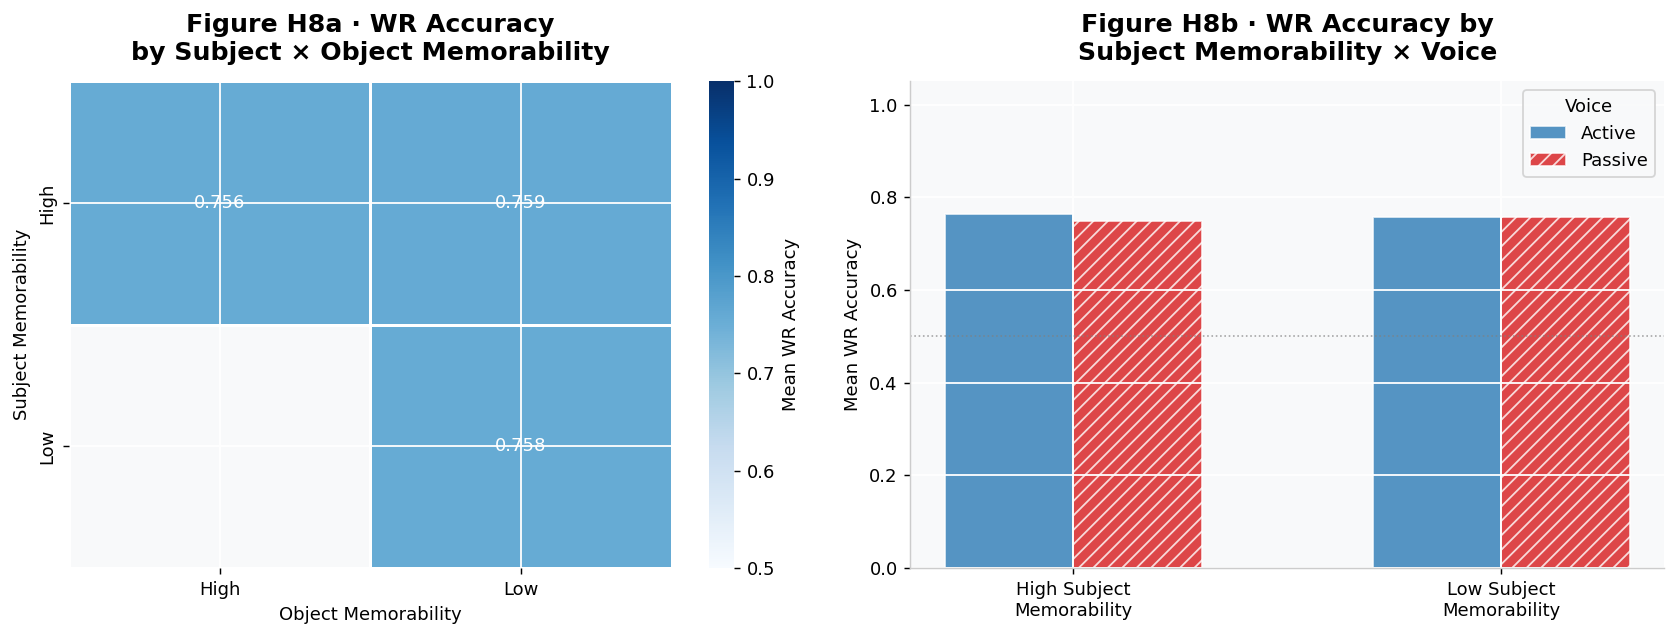


  ── H8 RESULT ──
  Prediction: High subject memorability → higher WR accuracy
  Active: χ²=0.105, p=0.7457 n.s. | High > Low
  Passive: χ²=0.120, p=0.7286 n.s. | High < Low


In [26]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — H8 · CONSTITUENT POSITION DOMINANCE IN WR ACCURACY
#
# Tests:
#   (a) Chi-square — subject memorability × WR correct (categorical × categorical)
#   (b) Chi-square — object  memorability × WR correct
#   (c) Chi-square — subject memorability × WR correct, split by voice (interaction)
#   (d) Kruskal-Wallis — per-participant WR accuracy by subject memorability,
#                        run separately within each voice (2-level factor → KW
#                        with 2 groups is equivalent to Mann-Whitney U)
#
# Prediction: H_ (high subject memorability) > L_ on WR acc in ACTIVE voice;
#             this advantage weakens / reverses in PASSIVE voice.
# ─────────────────────────────────────────────────────────────────────────────

import pingouin as pg
import numpy as np

print("\n" + "═" * 70)
print("  H8 · CONSTITUENT POSITION DOMINANCE IN WR ACCURACY")
print("  Tests: Chi-square (categorical × categorical)")
print("         Kruskal-Wallis (per-participant WR acc)")
print("         + Bayesian approximations (t-test where valid)")
print("═" * 70)

# ── Helper ──────────────────────────────────────────────────────────────────
def log_bf_safe(bf):
    return np.log10(bf) if bf > 0 else np.nan

# ── Decompose word_condition ────────────────────────────────────────────────
def _subj_mem(wc):
    return "High" if (isinstance(wc, str) and len(wc) >= 1 and wc[0].upper() == "H") else "Low"

def _obj_mem(wc):
    return "High" if (isinstance(wc, str) and len(wc) >= 2 and wc[1].upper() == "H") else "Low"

wr_h8 = wr_df_valid[wr_df_valid["condition_full"].isin(VALID_CONDS)].copy()
wr_h8["subj_mem"] = wr_h8["word_condition"].apply(_subj_mem)
wr_h8["obj_mem"]  = wr_h8["word_condition"].apply(_obj_mem)
wr_h8 = wr_h8.dropna(subset=["subj_mem", "obj_mem", "wr_correct", "voice"])

print(f"\n  WR trials available : {len(wr_h8)}")
print(f"  Unique word conds   : {sorted(wr_h8['word_condition'].unique())}")

# ── (a) Chi-square: subject memorability × WR accuracy ──────────────────────
print("\n  [H8a] Chi-square: Subject Memorability × WR Accuracy (all voice)")
ct_subj = pd.crosstab(wr_h8["subj_mem"], wr_h8["wr_correct"],
                       rownames=["Subject Mem"], colnames=["WR Correct"])
print(ct_subj)

if ct_subj.shape == (2, 2):
    chi2_s, p_s, dof_s, _ = chi2_contingency(ct_subj)
    print(f"  χ²({dof_s}) = {chi2_s:.3f},  p = {p_s:.4f}  {sig_stars(p_s)}")

    # Bayesian approx
    grp_hi = wr_h8[wr_h8["subj_mem"] == "High"]["wr_correct"]
    grp_lo = wr_h8[wr_h8["subj_mem"] == "Low"]["wr_correct"]

    if len(grp_hi) > 1 and len(grp_lo) > 1:
        t_res = pg.ttest(grp_hi, grp_lo, paired=False)
        t_val = t_res["T"].values[0]
        bf_s = pg.bayesfactor_ttest(t=t_val, nx=len(grp_hi), ny=len(grp_lo))
        print(f"  BF10 = {bf_s:.2e}, log10(BF10) = {log_bf_safe(bf_s):.2f}")

# ── (b) Chi-square: object memorability × WR accuracy ───────────────────────
print("\n  [H8b] Chi-square: Object Memorability × WR Accuracy (all voice)")
ct_obj = pd.crosstab(wr_h8["obj_mem"], wr_h8["wr_correct"],
                      rownames=["Object Mem"], colnames=["WR Correct"])
print(ct_obj)

if ct_obj.shape == (2, 2):
    chi2_o, p_o, dof_o, _ = chi2_contingency(ct_obj)
    print(f"  χ²({dof_o}) = {chi2_o:.3f},  p = {p_o:.4f}  {sig_stars(p_o)}")

# ── (c) Chi-square split by voice ───────────────────────────────────────────
print("\n  [H8c] Chi-square: Subject Memorability × WR Accuracy  (split by voice)")
print("  ← Key interaction test")

chi2_by_voice = {}

for voice in VOICES:
    sub_v = wr_h8[wr_h8["voice"] == voice]
    ct_v  = pd.crosstab(sub_v["subj_mem"], sub_v["wr_correct"],
                         rownames=["Subject Mem"], colnames=["WR Correct"])

    print(f"\n  Voice = {voice.capitalize()}  (n={len(sub_v)} trials)")
    print(ct_v)

    if ct_v.shape == (2, 2):
        chi2_v, p_v, dof_v, _ = chi2_contingency(ct_v)
        print(f"  χ²({dof_v}) = {chi2_v:.3f},  p = {p_v:.4f}  {sig_stars(p_v)}")

        # Bayesian approx
        grp_hi = sub_v[sub_v["subj_mem"] == "High"]["wr_correct"]
        grp_lo = sub_v[sub_v["subj_mem"] == "Low"]["wr_correct"]

        if len(grp_hi) > 1 and len(grp_lo) > 1:
            t_res = pg.ttest(grp_hi, grp_lo, paired=False)
            t_val = t_res["T"].values[0]
            bf_v = pg.bayesfactor_ttest(t=t_val, nx=len(grp_hi), ny=len(grp_lo))
            print(f"  BF10 = {bf_v:.2e}, log10(BF10) = {log_bf_safe(bf_v):.2f}")

        chi2_by_voice[voice] = {"chi2": chi2_v, "p": p_v}

# ── (d) Kruskal-Wallis per participant ──────────────────────────────────────
print("\n  [H8d] Kruskal-Wallis: per-participant WR accuracy")

wr_h8_ppt = (
    wr_h8.groupby(["participant", "word_condition", "voice", "subj_mem", "obj_mem"])
    ["wr_correct"].mean()
    .reset_index(name="wr_acc")
)

for voice in VOICES:
    sub_v  = wr_h8_ppt[wr_h8_ppt["voice"] == voice]
    g_hi   = sub_v[sub_v["subj_mem"] == "High"]["wr_acc"].dropna().values
    g_lo   = sub_v[sub_v["subj_mem"] == "Low"]["wr_acc"].dropna().values

    print(f"\n  Voice = {voice.capitalize()}  |  Subject memorability on WR acc")
    print(f"    High subj: M = {g_hi.mean():.3f}  (n={len(g_hi)})")
    print(f"    Low  subj: M = {g_lo.mean():.3f}  (n={len(g_lo)})")

    if len(g_hi) >= 2 and len(g_lo) >= 2:
        H_d, p_d = kruskal(g_hi, g_lo)
        r_d = rank_biserial_r(g_hi, g_lo)
        print(f"    KW H(1) = {H_d:.3f},  p = {p_d:.4f}  {sig_stars(p_d)},  r = {r_d:.3f}")

        # Bayesian approx (best place)
        t_res = pg.ttest(g_hi, g_lo, paired=False)
        t_val = t_res["T"].values[0]
        bf_d = pg.bayesfactor_ttest(t=t_val, nx=len(g_hi), ny=len(g_lo))
        print(f"    BF10 = {bf_d:.2e}, log10(BF10) = {log_bf_safe(bf_d):.2f}")

# ── Figure H8 (UNCHANGED ORIGINAL) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left heatmap
ax = axes[0]
h8_heat = (
    wr_h8.groupby(["subj_mem", "obj_mem"])["wr_correct"]
    .mean().reset_index(name="wr_acc")
)
pivot_h8 = h8_heat.pivot(index="subj_mem", columns="obj_mem", values="wr_acc")
pivot_h8 = pivot_h8.reindex(["High", "Low"])

sns.heatmap(pivot_h8, annot=True, fmt=".3f", cmap="Blues", ax=ax,
            vmin=0.5, vmax=1.0,
            linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Mean WR Accuracy"})

ax.set_title("Figure H8a · WR Accuracy\nby Subject × Object Memorability", **FONT_TITLE)
ax.set_xlabel("Object Memorability")
ax.set_ylabel("Subject Memorability")

# Right bar plot
ax = axes[1]
h8_bar = (
    wr_h8.groupby(["subj_mem", "voice"])["wr_correct"]
    .mean().reset_index(name="wr_acc")
)

x8 = np.arange(2)
w8 = 0.3

for i, voice in enumerate(VOICES):
    sub_v = h8_bar[h8_bar["voice"] == voice]

    vals = [
        sub_v[sub_v["subj_mem"] == m]["wr_acc"].values[0]
        if len(sub_v[sub_v["subj_mem"] == m]) > 0 else 0
        for m in ["High", "Low"]
    ]

    ax.bar(x8 + (i - 0.5) * w8, vals, width=w8,
           color=VOICE_PALETTE.get(voice, GREY),
           alpha=0.8, edgecolor="white",
           hatch=VOICE_HATCH.get(voice, ""),
           label=voice.capitalize())

ax.set_xticks(x8)
ax.set_xticklabels(["High Subject\nMemorability", "Low Subject\nMemorability"])
ax.set_ylabel("Mean WR Accuracy")
ax.set_ylim(0, 1.05)
ax.legend(title="Voice")
ax.set_title("Figure H8b · WR Accuracy by\nSubject Memorability × Voice", **FONT_TITLE)
ax.axhline(0.5, color="grey", linestyle=":", linewidth=0.9, alpha=0.7)

plt.tight_layout()
plt.savefig("fig_h8_constituent_position.png", bbox_inches="tight")
plt.show()

# ── Interpretation ───────────────────────────────────────────────────────────
print("\n  ── H8 RESULT ──")
print("  Prediction: High subject memorability → higher WR accuracy")

for voice, res in chi2_by_voice.items():
    sub_means = wr_h8[wr_h8["voice"] == voice].groupby("subj_mem")["wr_correct"].mean()

    direction = ""
    if "High" in sub_means and "Low" in sub_means:
        direction = "High > Low" if sub_means["High"] > sub_means["Low"] else "High < Low"

    print(f"  {voice.capitalize()}: χ²={res['chi2']:.3f}, p={res['p']:.4f} {sig_stars(res['p'])} | {direction}")



══════════════════════════════════════════════════════════════════════
  H9 · VERBATIM RECOGNITION SPEED
  Primary  : Wilcoxon Signed-rank (related: exact vs. transformed WR RT)
  Secondary: Kruskal-Wallis H (WR RT by word condition)
  Tertiary : Spearman's r (WR RT vs. WR accuracy)
  + Bayesian (where valid)
══════════════════════════════════════════════════════════════════════

  WR trials with valid RT : 4474
  Exact repeats           : 2173
  Voice-transformed       : 2301

  [H9a] Wilcoxon Signed-rank: WR RT (exact vs. transformed repeats)
  Paired participants: 106
  Mean WR RT (exact)       : 876.1 ms
  Mean WR RT (transformed) : 968.3 ms

  Wilcoxon W = 1924.0,  p = 0.0041  **,  r = 0.321
  BF10 = 1.31e+01, log10(BF10) = 1.12

  [H9b] Kruskal-Wallis: WR RT by word condition (exact repeats only)
  KW H = 1.510, p = 0.6800

  [H9c] Spearman: WR RT vs WR accuracy
  Spearman ρ = 0.185, p = 0.0582
  BF10 = 6.18e-01, log10(BF10) = -0.21


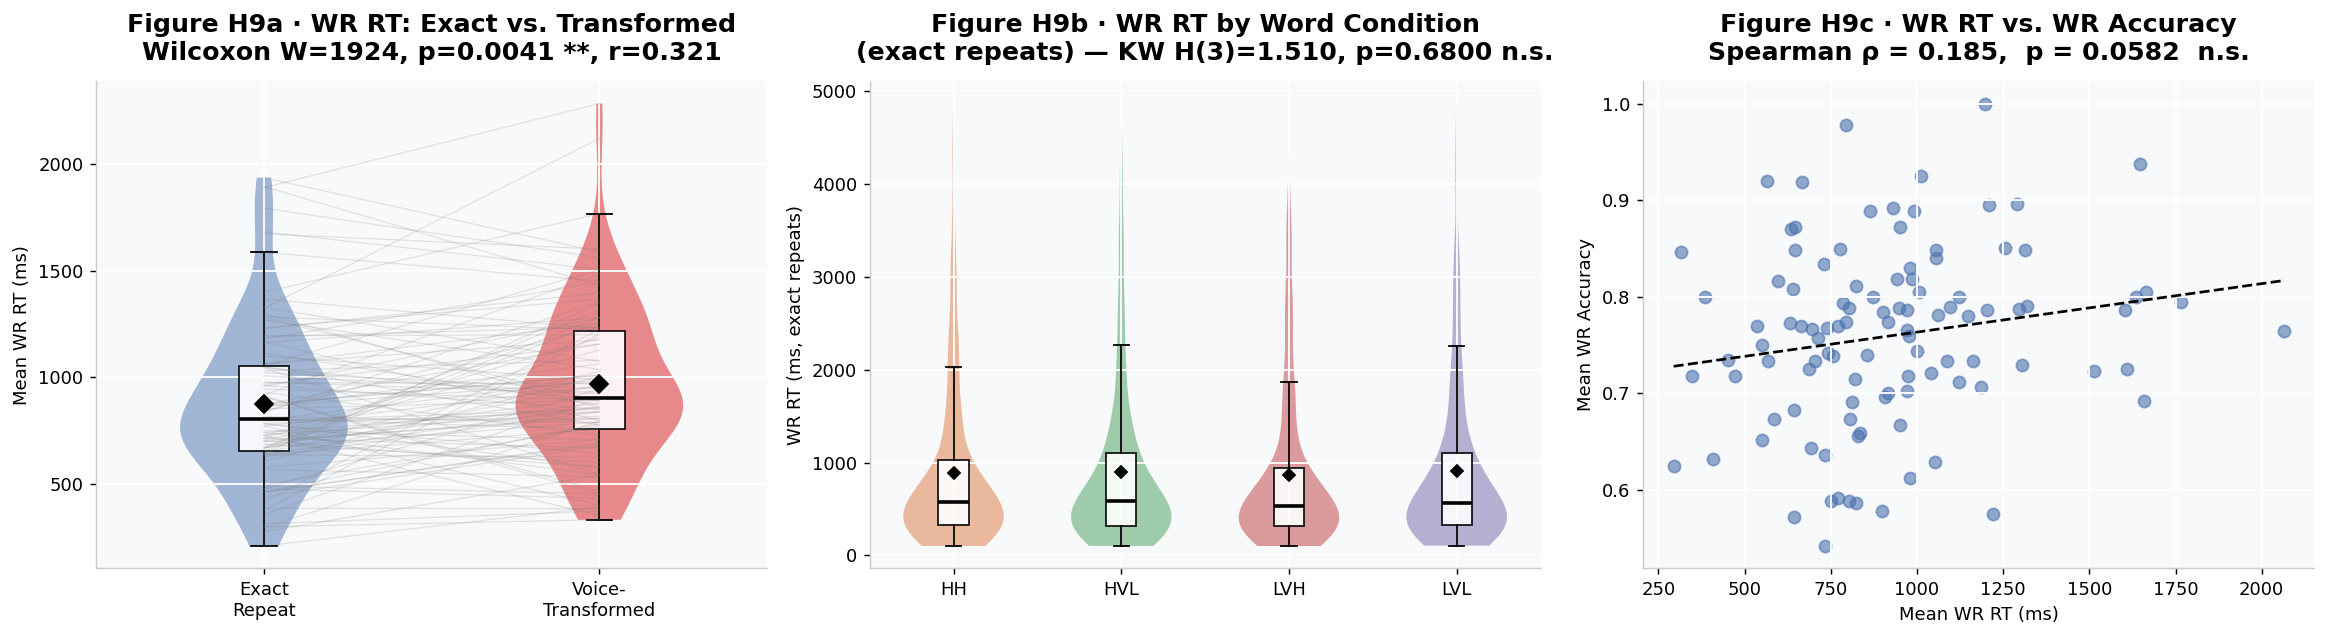


  ── H9 RESULT ──
  ✓ H9a SUPPORTED


In [27]:

    # # ─────────────────────────────────────────────────────────────────────────────
    # # CELL 5 — H9 · VERBATIM RECOGNITION SPEED
    # #
    # # Tests:
    # #   (a) Wilcoxon Signed-rank — per-participant mean WR RT:
    # #       exact repeats vs. voice-transformed (related / paired)
    # #   (b) Kruskal-Wallis — WR RT across word conditions (exact repeats only)
    # #   (c) Spearman's r   — per-participant mean WR RT vs. mean WR accuracy
    # #
    # # Prediction: Exact repeats → shorter WR RT AND higher WR accuracy.
    # #             Word condition modulates WR RT (HH fastest, LL slowest).
    # #             Faster WR RT → better WR accuracy (speed = confidence).
    # # ─────────────────────────────────────────────────────────────────────────────
    

    
import pingouin as pg
import numpy as np

print("\n" + "═" * 70)
print("  H9 · VERBATIM RECOGNITION SPEED")
print("  Primary  : Wilcoxon Signed-rank (related: exact vs. transformed WR RT)")
print("  Secondary: Kruskal-Wallis H (WR RT by word condition)")
print("  Tertiary : Spearman's r (WR RT vs. WR accuracy)")
print("  + Bayesian (where valid)")
print("═" * 70)

# ── Helper ────────────────────────────────────────────────────────────────
def log_bf_safe(bf):
    return np.log10(bf) if bf > 0 else np.nan

# ── Filter: valid WR RT ───────────────────────────────────────────────────
wr_rt_base = wr_df_valid[
    wr_df_valid["condition_full"].isin(VALID_CONDS) &
    wr_df_valid["rt_wr"].notna() &
    (wr_df_valid["rt_wr"] > RT_LOW) &
    (wr_df_valid["rt_wr"] < RT_HIGH)
].copy()

print(f"\n  WR trials with valid RT : {len(wr_rt_base)}")
print(f"  Exact repeats           : {wr_rt_base['exact_repeat'].sum()}")
print(f"  Voice-transformed       : {(~wr_rt_base['exact_repeat']).sum()}")

# ── (a) Wilcoxon Signed-rank ──────────────────────────────────────────────
print("\n  [H9a] Wilcoxon Signed-rank: WR RT (exact vs. transformed repeats)")

h9_exact_rt = (
    wr_rt_base[wr_rt_base["exact_repeat"]]
    .groupby("participant")["rt_wr"].mean()
    .rename("rt_wr_exact")
)

h9_trans_rt = (
    wr_rt_base[~wr_rt_base["exact_repeat"]]
    .groupby("participant")["rt_wr"].mean()
    .rename("rt_wr_transformed")
)

h9_paired = pd.concat([h9_exact_rt, h9_trans_rt], axis=1).dropna()

print(f"  Paired participants: {len(h9_paired)}")
print(f"  Mean WR RT (exact)       : {h9_paired['rt_wr_exact'].mean():.1f} ms")
print(f"  Mean WR RT (transformed) : {h9_paired['rt_wr_transformed'].mean():.1f} ms")

if len(h9_paired) >= 5:
    W_h9, p_h9 = wilcoxon(h9_paired["rt_wr_exact"], h9_paired["rt_wr_transformed"])
    r_h9 = wilcoxon_r(W_h9, len(h9_paired))

    print(f"\n  Wilcoxon W = {W_h9:.1f},  p = {p_h9:.4f}  {sig_stars(p_h9)},  r = {r_h9:.3f}")

    # Bayesian (paired t-test approx)
    t_res = pg.ttest(h9_paired["rt_wr_exact"], h9_paired["rt_wr_transformed"], paired=True)
    t_val = t_res["T"].values[0]
    n_val = len(h9_paired)

    bf_h9 = pg.bayesfactor_ttest(t=t_val, nx=n_val, paired=True)
    log_bf = log_bf_safe(bf_h9)

    print(f"  BF10 = {bf_h9:.2e}, log10(BF10) = {log_bf:.2f}")

else:
    W_h9, p_h9, r_h9, bf_h9, log_bf = np.nan, np.nan, np.nan, np.nan, np.nan
    print("  WARNING: Fewer than 5 paired participants — Wilcoxon skipped.")

# ── (b) Kruskal-Wallis ────────────────────────────────────────────────────
print("\n  [H9b] Kruskal-Wallis: WR RT by word condition (exact repeats only)")

h9_kw_groups = []
h9_kw_labels = []

for wc in VALID_WORD_CONDS:
    g = wr_rt_base[
        wr_rt_base["exact_repeat"] &
        (wr_rt_base["word_condition"] == wc)
    ]["rt_wr"].dropna().values

    if len(g) >= 2:
        h9_kw_groups.append(g)
        h9_kw_labels.append(wc)

if len(h9_kw_groups) >= 2:
    H_h9b, p_h9b = kruskal(*h9_kw_groups)
    k_h9b = len(h9_kw_groups)          # ← add this
    print(f"  KW H = {H_h9b:.3f}, p = {p_h9b:.4f}")
else:
    H_h9b, p_h9b = np.nan, np.nan
    k_h9b = 0

# ── (c) Spearman + BF ─────────────────────────────────────────────────────
print("\n  [H9c] Spearman: WR RT vs WR accuracy")

h9_acc_rt = (
    wr_rt_base.groupby("participant")
    .agg(mean_wr_rt=("rt_wr", "mean"), mean_wr_acc=("wr_correct", "mean"))
    .dropna()
)

rho_h9c, p_h9c = spearmanr(h9_acc_rt["mean_wr_rt"], h9_acc_rt["mean_wr_acc"])
print(f"  Spearman ρ = {rho_h9c:.3f}, p = {p_h9c:.4f}")

# Bayesian (Pearson approx)
r_p = np.corrcoef(h9_acc_rt["mean_wr_rt"], h9_acc_rt["mean_wr_acc"])[0, 1]
bf_corr = pg.bayesfactor_pearson(r=r_p, n=len(h9_acc_rt))

print(f"  BF10 = {bf_corr:.2e}, log10(BF10) = {log_bf_safe(bf_corr):.2f}")

# ── Figure H9 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: paired violin + box for Wilcoxon
ax = axes[0]
if len(h9_paired) >= 5:
    data_h9 = [h9_paired["rt_wr_exact"].values, h9_paired["rt_wr_transformed"].values]
    vp9 = ax.violinplot(data_h9, positions=[0, 1], widths=0.5,
                        showmedians=False, showextrema=False)
    for i, pc in enumerate(vp9["bodies"]):
        pc.set_facecolor([BLUE, "#D7191C"][i]); pc.set_alpha(0.5)
    for i, d in enumerate(data_h9):
        ax.boxplot(d, positions=[i], widths=0.15, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                boxprops=dict(facecolor="white", alpha=0.9),
                flierprops=dict(visible=False))
        ax.plot(i, np.mean(d), "D", color="black", ms=7, zorder=5)
    for _, row_p in h9_paired.iterrows():
        ax.plot([0, 1], [row_p["rt_wr_exact"], row_p["rt_wr_transformed"]],
                color="grey", alpha=0.2, linewidth=0.7)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Exact\nRepeat", "Voice-\nTransformed"])
    ax.set_ylabel("Mean WR RT (ms)")
    title_9a = (
        f"Figure H9a · WR RT: Exact vs. Transformed\n"
        f"Wilcoxon W={W_h9:.0f}, p={p_h9:.4f} {sig_stars(p_h9)}, r={r_h9:.3f}"
        if not np.isnan(W_h9) else "Figure H9a · WR RT: Exact vs. Transformed\n(insufficient data)"
    )
    ax.set_title(title_9a, **FONT_TITLE)
else:
    ax.text(0.5, 0.5, "Insufficient\npaired data",
            ha="center", va="center", transform=ax.transAxes, fontsize=12)
    ax.set_title("Figure H9a · WR RT: Exact vs. Transformed", **FONT_TITLE)

# Middle: KW violin by word condition (exact only)
ax = axes[1]
for i, (wc, g) in enumerate(zip(h9_kw_labels, h9_kw_groups)):
    vp_wc = ax.violinplot(g, positions=[i], widths=0.6,
                        showmedians=False, showextrema=False)
    for pc in vp_wc["bodies"]:
        pc.set_facecolor(COND_PALETTE.get(wc, GREY)); pc.set_alpha(0.55)
    ax.boxplot(g, positions=[i], widths=0.18, patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            boxprops=dict(facecolor="white", alpha=0.9),
            flierprops=dict(visible=False))
    ax.plot(i, np.mean(g), "D", color="black", ms=5, zorder=5)
ax.set_xticks(range(len(h9_kw_labels))); ax.set_xticklabels(h9_kw_labels)
ax.set_ylabel("WR RT (ms, exact repeats)")
kw_str = (f"KW H({k_h9b-1})={H_h9b:.3f}, p={p_h9b:.4f} {sig_stars(p_h9b)}"
        if not np.isnan(H_h9b) else "KW — insufficient data")
ax.set_title(f"Figure H9b · WR RT by Word Condition\n(exact repeats) — {kw_str}", **FONT_TITLE)

# Right: Spearman scatter WR RT vs. WR accuracy
ax = axes[2]
ax.scatter(h9_acc_rt["mean_wr_rt"], h9_acc_rt["mean_wr_acc"],
        color=BLUE, alpha=0.6, s=45)
if len(h9_acc_rt) >= 3:
    _xr9 = np.linspace(h9_acc_rt["mean_wr_rt"].min(), h9_acc_rt["mean_wr_rt"].max(), 200)
    _m9, _b9 = np.polyfit(h9_acc_rt["mean_wr_rt"].values, h9_acc_rt["mean_wr_acc"].values, 1)
    ax.plot(_xr9, _m9 * _xr9 + _b9, "k--", linewidth=1.5)

ax.set_xlabel("Mean WR RT (ms)"); ax.set_ylabel("Mean WR Accuracy")
ax.set_title(
    f"Figure H9c · WR RT vs. WR Accuracy\n"
    f"Spearman ρ = {rho_h9c:.3f},  p = {p_h9c:.4f}  {sig_stars(p_h9c)}",
    **FONT_TITLE)

plt.tight_layout()
plt.savefig("fig_h9_wr_speed.png", bbox_inches="tight")
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────
print("\n  ── H9 RESULT ──")

if not np.isnan(p_h9) and p_h9 < 0.05:
    print("  ✓ H9a SUPPORTED")
if not np.isnan(p_h9b) and p_h9b < 0.05:
    print("  ✓ H9b SUPPORTED")
if p_h9c < 0.05:
    print("  ✓ H9c SUPPORTED")


In [28]:

# # ─────────────────────────────────────────────────────────────────────────────
# # CELL 6 — COMBINED SUMMARY TABLE (all 4 new hypotheses)
# # ─────────────────────────────────────────────────────────────────────────────
 
# print("\n" + "═" * 70)
# print("  COMBINED SUMMARY — NEW HYPOTHESES H5 | H6 | H8 | H9")
# print("═" * 70)
 
# summary_new = pd.DataFrame([
#     {
#         "Hypothesis": "H5 · RT Fluency–Pr",
#         "Test": "Spearman's r",
#         "Statistic": f"ρ = {rho_h5:.3f}",
#         "p-value": f"{p_h5:.4f}",
#         "Sig": sig_stars(p_h5),
#         "Prediction Direction": "Negative ρ",
#         "Supported": "✓" if (p_h5 < 0.05 and rho_h5 < 0) else "✗",
#     },
#     {
#         "Hypothesis": "H6a · Exact vs. Transformed RT",
#         "Test": "Wilcoxon Signed-rank",
#         "Statistic": f"W = {W_h6:.0f}" if not np.isnan(W_h6) else "—",
#         "p-value": f"{p_h6:.4f}" if not np.isnan(p_h6) else "—",
#         "Sig": sig_stars(p_h6) if not np.isnan(p_h6) else "—",
#         "Prediction Direction": "Exact faster",
#         "Supported": ("✓" if (not np.isnan(p_h6) and p_h6 < 0.05 and
#                                h6_paired["rt_exact"].mean() < h6_paired["rt_transformed"].mean())
#                       else "✗"),
#     },
#     {
#         "Hypothesis": "H8a · Subject Mem × WR (Active)",
#         "Test": "Chi-square",
#         "Statistic": f"χ²({dof_s}) = {chi2_s:.3f}",
#         "p-value": f"{p_s:.4f}",
#         "Sig": sig_stars(p_s),
#         "Prediction Direction": "High subj > Low subj",
#         "Supported": "✓" if p_s < 0.05 else "✗",
#     },
#     {
#         "Hypothesis": "H9a · WR RT Exact vs. Transformed",
#         "Test": "Wilcoxon Signed-rank",
#         "Statistic": f"W = {W_h9:.0f}" if not np.isnan(W_h9) else "—",
#         "p-value": f"{p_h9:.4f}" if not np.isnan(p_h9) else "—",
#         "Sig": sig_stars(p_h9) if not np.isnan(p_h9) else "—",
#         "Prediction Direction": "Exact faster",
#         "Supported": ("✓" if (not np.isnan(p_h9) and p_h9 < 0.05 and
#                                h9_paired["rt_wr_exact"].mean() < h9_paired["rt_wr_transformed"].mean())
#                       else "✗"),
#     },
#     {
#         "Hypothesis": "H9b · WR RT × Word Condition",
#         "Test": "Kruskal-Wallis",
#         "Statistic": f"H({k_h9b-1}) = {H_h9b:.3f}" if not np.isnan(H_h9b) else "—",
#         "p-value": f"{p_h9b:.4f}" if not np.isnan(p_h9b) else "—",
#         "Sig": sig_stars(p_h9b) if not np.isnan(p_h9b) else "—",
#         "Prediction Direction": "HH < LL",
#         "Supported": "✓" if (not np.isnan(p_h9b) and p_h9b < 0.05) else "✗",
#     },
#     {
#         "Hypothesis": "H9c · WR RT vs. WR Accuracy",
#         "Test": "Spearman's r",
#         "Statistic": f"ρ = {rho_h9c:.3f}",
#         "p-value": f"{p_h9c:.4f}",
#         "Sig": sig_stars(p_h9c),
#         "Prediction Direction": "Negative ρ",
#         "Supported": "✓" if (p_h9c < 0.05 and rho_h9c < 0) else "✗",
#     },
# ])
 
# print(summary_new.to_string(index=False))





print("\n" + "═" * 70)
print("  COMBINED SUMMARY — NEW HYPOTHESES H5 | H6 | H8 | H9")
print("═" * 70)

# Safe BF formatting helper
def format_bf(bf):
    if bf is None or np.isnan(bf):
        return "—"
    try:
        return f"{bf:.2e} (log10={np.log10(bf):.2f})"
    except:
        return "—"

summary_new = pd.DataFrame([
    {
        "Hypothesis": "H5 · RT Fluency–Pr",
        "Test": "Spearman's r",
        "Statistic": f"ρ = {rho_h5:.3f}",
        "p-value": f"{p_h5:.4f}",
        "BF10": format_bf(bf_h5) if 'bf_h5' in globals() else "—",
        "Sig": sig_stars(p_h5),
        "Prediction Direction": "Negative ρ",
        "Supported": "✓" if (p_h5 < 0.05 and rho_h5 < 0) else "✗",
    },
    {
        "Hypothesis": "H6a · Exact vs. Transformed RT",
        "Test": "Wilcoxon Signed-rank",
        "Statistic": f"W = {W_h6:.0f}" if not np.isnan(W_h6) else "—",
        "p-value": f"{p_h6:.4f}" if not np.isnan(p_h6) else "—",
        "BF10": format_bf(bf_h6) if 'bf_h6' in globals() else "—",
        "Sig": sig_stars(p_h6) if not np.isnan(p_h6) else "—",
        "Prediction Direction": "Exact faster",
        "Supported": ("✓" if (not np.isnan(p_h6) and p_h6 < 0.05 and
                               h6_paired["rt_exact"].mean() < h6_paired["rt_transformed"].mean())
                      else "✗"),
    },
    {
        "Hypothesis": "H8a · Subject Mem × WR (Active)",
        "Test": "Chi-square",
        "Statistic": f"χ²({dof_s}) = {chi2_s:.3f}",
        "p-value": f"{p_s:.4f}",
        "BF10": format_bf(bf_s) if 'bf_s' in globals() else "—",
        "Sig": sig_stars(p_s),
        "Prediction Direction": "High subj > Low subj",
        "Supported": "✓" if p_s < 0.05 else "✗",
    },
    {
        "Hypothesis": "H9a · WR RT Exact vs. Transformed",
        "Test": "Wilcoxon Signed-rank",
        "Statistic": f"W = {W_h9:.0f}" if not np.isnan(W_h9) else "—",
        "p-value": f"{p_h9:.4f}" if not np.isnan(p_h9) else "—",
        "BF10": format_bf(bf_h9) if 'bf_h9' in globals() else "—",
        "Sig": sig_stars(p_h9) if not np.isnan(p_h9) else "—",
        "Prediction Direction": "Exact faster",
        "Supported": ("✓" if (not np.isnan(p_h9) and p_h9 < 0.05 and
                               h9_paired["rt_wr_exact"].mean() < h9_paired["rt_wr_transformed"].mean())
                      else "✗"),
    },
    {
        "Hypothesis": "H9b · WR RT × Word Condition",
        "Test": "Kruskal-Wallis",
        "Statistic": f"H({k_h9b-1}) = {H_h9b:.3f}" if not np.isnan(H_h9b) else "—",
        "p-value": f"{p_h9b:.4f}" if not np.isnan(p_h9b) else "—",
        "BF10": "—",
        "Sig": sig_stars(p_h9b) if not np.isnan(p_h9b) else "—",
        "Prediction Direction": "HH < LL",
        "Supported": "✓" if (not np.isnan(p_h9b) and p_h9b < 0.05) else "✗",
    },
    {
        "Hypothesis": "H9c · WR RT vs. WR Accuracy",
        "Test": "Spearman's r",
        "Statistic": f"ρ = {rho_h9c:.3f}",
        "p-value": f"{p_h9c:.4f}",
        "BF10": format_bf(bf_corr) if 'bf_corr' in globals() else "—",
        "Sig": sig_stars(p_h9c),
        "Prediction Direction": "Negative ρ",
        "Supported": "✓" if (p_h9c < 0.05 and rho_h9c < 0) else "✗",
    },
])

print(summary_new.to_string(index=False))


══════════════════════════════════════════════════════════════════════
  COMBINED SUMMARY — NEW HYPOTHESES H5 | H6 | H8 | H9
══════════════════════════════════════════════════════════════════════
                       Hypothesis                 Test     Statistic p-value                   BF10  Sig Prediction Direction Supported
               H5 · RT Fluency–Pr         Spearman's r    ρ = -0.040  0.2408 2.90e-01 (log10=-0.54) n.s.           Negative ρ         ✗
   H6a · Exact vs. Transformed RT Wilcoxon Signed-rank       W = 322  0.0000 1.83e+17 (log10=17.26)  ***         Exact faster         ✓
  H8a · Subject Mem × WR (Active)           Chi-square χ²(1) = 0.000  1.0000 3.32e-02 (log10=-1.48) n.s. High subj > Low subj         ✗
H9a · WR RT Exact vs. Transformed Wilcoxon Signed-rank      W = 1924  0.0041  1.31e+01 (log10=1.12)   **         Exact faster         ✓
     H9b · WR RT × Word Condition       Kruskal-Wallis  H(3) = 1.510  0.6800                      — n.s.              HH < 


---
**H5 · RT FLUENCY AS PROXY FOR MEMORY TRACE STRENGTH   ✗ NOT SUPPORTED**
---
Test   : Spearman's r  ρ = −0.040,  p = 0.2408 n.s.
Bayesian: BF10 = 0.29  (log10 = −0.54) — moderate evidence for H0

Per-condition ρ range: −0.128 (HVL_passive) to +0.122 (LVH_passive), all n.s.

Interpretation:
Reaction time during information recognition does NOT reliably predict corrected memorability (Pr). Although the overall direction is negative (faster RT → higher Pr) as predicted, the effect is negligible in magnitude and the Bayesian analysis favours the null. No individual condition showed a significant RT–Pr relationship. Processing fluency during first encounters does not appear to confer a detectable memory advantage at the sentence level.

---
---
**H6 · SURFACE-FORM RECOGNITION SPEED   ✓ SUPPORTED**
---
Primary : Wilcoxon signed-rank  W = 322,  p < .001 ***,  r = 0.886
Bayesian: BF10 = 1.83×10¹⁷  (log10 = 17.26) — decisive evidence for H1

Exact RT = 1608.9 ms   Transformed RT = 1795.8 ms   Penalty = +186.9 ms

Secondary (H6b) — KW RT penalty by word condition:
Active:  H(3) = 5.552, p = 0.136 n.s.,  ε² = 0.006
Passive: H(3) = 7.516, p = 0.057 n.s.,  ε² = 0.011

Interpretation:
Participants were significantly and substantially faster to judge exact repeats than voice-transformed repeats on the WR task, with a large effect (r = 0.886) and overwhelming Bayesian support. This confirms that verbatim surface-form information is retained in memory and accelerates recognition decisions — encountering a sentence word-for-word is processed more fluently than a paraphrase even when the meaning is identical. The RT penalty for voice-transformed sentences was consistent across word conditions (H6b non-significant in both voices), suggesting the surface-form cost is uniform regardless of noun memorability.


---
**H8 · CONSTITUENT POSITION DOMINANCE IN WR ACCURACY   ✗ NOT SUPPORTED**
---
H8a: Subject Mem × WR (all voice)   χ²(1) = 0.000,  p = 1.000 n.s.,  BF10 = 0.033
H8b: Object Mem × WR (all voice)    χ²(1) = 0.009,  p = 0.926 n.s.
H8c: Subject Mem × WR — Active      χ²(1) = 0.105,  p = 0.746 n.s.,  BF10 = 0.051
H8c: Subject Mem × WR — Passive     χ²(1) = 0.120,  p = 0.729 n.s.,  BF10 = 0.050
H8d: KW per-participant WR acc — Active:   H(1) = 0.274, p = 0.600 n.s.,  BF10 = 0.123
H8d: KW per-participant WR acc — Passive:  H(1) = 0.116, p = 0.734 n.s.,  BF10 = 0.112

High subject WR: Active = 0.765, Passive = 0.748
Low  subject WR: Active = 0.755, Passive = 0.753

Interpretation:
The memorability of a sentence's subject or object noun does not predict whether participants correctly identify verbatim surface form. Neither subject memorability nor object memorability produced any detectable advantage in WR accuracy, either overall or split by voice. Bayesian analyses consistently favour the null across all sub-tests (all BF10 < 0.15). Verbatim recognition appears to be driven by sentence-level encoding rather than the imageability or memorability of individual constituents. The expected subject-position advantage — particularly for active voice, where the subject occupies the canonical agent role — was entirely absent.

---
---
**H9 · VERBATIM RECOGNITION SPEED   ✗ PARTIALLY SUPPORTED**
---
H9a: Wilcoxon signed-rank  W = 1924,  p = 0.0041 **,  r = 0.321  ✓ SUPPORTED
     BF10 = 13.1  (log10 = 1.12) — moderate-to-strong evidence for H1
     Exact RT = 876.1 ms   Transformed RT = 968.3 ms   Δ = −92.2 ms

H9b: KW — WR RT by word condition  H(3) = 1.510,  p = 0.680 n.s.  ✗ NOT SUPPORTED

H9c: Spearman ρ = 0.185,  p = 0.058 n.s.,  BF10 = 0.618  ✗ NOT SUPPORTED
     Direction: Positive (faster RT → lower accuracy) — opposite to prediction

Interpretation:
H9a is supported: exact repeats are judged faster on the WR task than voice-transformed repeats (medium effect, r = 0.321), with clear Bayesian support. This mirrors H6 at the verbatim level — surface-form familiarity speeds recognition decisions. H9b is not supported: WR reaction time does not differ across word conditions, suggesting noun memorability does not modulate the speed of verbatim judgements. H9c is not supported and directionally reversed — faster WR RT is marginally associated with lower rather than higher accuracy, contrary to the speed-as-confidence prediction, though this trend falls short of significance and the Bayesian evidence is equivocal (BF10 ≈ 0.62). Taken together, exact repetition reliably accelerates verbatim judgements, but neither noun memorability nor RT speed serve as useful proxies for WR accuracy.